# Risco de não alfabetização — análise e modelagem em um único fluxo

**Tech Challenge · Fase 3 · Pós Tech FIAP — AI Scientist**

Este notebook percorre o ciclo **CRISP-DM** inteiro sobre os microdados do *Indicador
Criança Alfabetizada* (INEP/MEC): entendimento do negócio, preparação e exploração dos
dados, modelagem com três algoritmos, avaliação e implantação do campeão.

| Fase | O que acontece aqui |
|---|---|
| **01 · Entendimento do negócio** | a pergunta, o alvo, a métrica e o custo do erro |
| **02 · Preparação dos dados** | coleta, limpeza, EDA por hipóteses, engenharia de atributos, correlações |
| **03 · Modelagem** | pré-processamento, três algoritmos, comparação, ajuste fino, limiar, interpretabilidade |
| **04 · Avaliação** | leitura de negócio das métricas |
| **05 · Implantação** | o campeão vira `models/pipeline_aluno.joblib` |

> **Como executar.** Do diretório raiz do projeto, dentro do WSL:
> `bash run.sh setup` uma vez, depois abrir este notebook com o kernel `Fase 3`.
> A base analítica é reconstruída por `bash run.sh base` quando ausente.

# **FASE 01: ENTENDIMENTO DO NEGÓCIO**

### O problema

O **Compromisso Nacional Criança Alfabetizada** estabelece que toda criança deve estar
alfabetizada ao fim do 2º ano do ensino fundamental. O INEP mede isso com uma prova de
leitura e escrita: quem alcança **743 pontos** na escala Saeb é considerado alfabetizado.

Em 2024, **40,2% das crianças avaliadas não atingiram esse corte**. A política pública
chega tarde quando age sobre o resultado: no momento em que a prova acontece, o ano letivo
já passou. A pergunta que interessa ao gestor é anterior.

> **Pergunta de negócio.** Dado o que se sabe sobre uma criança *antes* da avaliação — o
> município onde estuda, a escola, a rede, o histórico daquele território — qual é a
> probabilidade de ela não ser alfabetizada?

### O alvo

`nao_alfabetizado` = 1 quando a criança **não** atinge 743 pontos.

A classe positiva é deliberadamente a classe ruim. Em política pública o custo de **não
identificar** uma criança em risco (falso negativo: ela não entra no programa de reforço)
é muito maior que o de acompanhar uma criança que iria bem de qualquer forma (falso
positivo: gasta-se uma vaga de reforço à toa). Métricas assimétricas exigem que a classe
de interesse seja a positiva.

### A métrica

**PR-AUC** (área sob a curva precisão-revocação), complementada por **recall** da classe
positiva. Acurácia seria enganosa aqui por dois motivos: a base é desbalanceada (40/60) e,
pior, ela trata falso positivo e falso negativo como se custassem o mesmo — exatamente a
premissa que este problema viola.

O piso de comparação é a **prevalência**: um classificador aleatório tem PR-AUC igual à
proporção da classe positiva, cerca de 0,40. Qualquer modelo precisa superar isso com folga
para justificar existir.

### O critério anti-vazamento

Uma restrição desenha todo o resto: **nenhuma variável medida no mesmo ano do alvo pode
entrar no modelo**. A proficiência define o alvo por construção; a taxa de alfabetização do
município em 2024 é um agregado do próprio alvo. O contexto territorial vem todo de
**2023** (`ANO_CONTEXTO`), enquanto o alvo vem de **2024** (`ANO_ALVO`). É essa defasagem
que torna a previsão utilizável: em fevereiro de 2025, todo o insumo do modelo já existe.

# **FASE 02: PREPARAÇÃO DOS DADOS**

## 1 - **COLETA DOS DADOS**

A base analítica nasce da **camada Gold embarcada** em `data/gold/`, dentro do próprio
repositório — o projeto não depende do data lake da Fase 2 estar por perto. Quatro visões
alimentam a base: microdado de aluno, indicadores municipais, indicadores estaduais e a
trajetória de metas do INEP, enriquecidos com dados socioeconômicos da API do IBGE.

O grão é **um aluno avaliado em 2024**: 1.851.852 linhas, 5.517 municípios, 42.328 escolas.

In [1]:
# Bibliotecas
import sys, gc, json, time, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Contrato de colunas, caminhos e semente — fonte única da verdade do projeto
from src.config import (
    ALVO, ANO_ALVO, ANO_CONTEXTO, CAT_ALTA, CAT_BAIXA, COLUNAS_LEAKAGE,
    COLUNAS_VETADAS_DIAGNOSTICO, FEATURES, IMAGES_DIR, MODELS_DIR, NUM_FEATURES,
    N_JOBS, REPORTS_DIR, SEED,
)
from src.viz.plots import (
    AGUA, AZUL, DIVERGENTE, LARANJA, NEUTRO, SEQUENCIAL, TINTA_SEC,
    anota, aplica_estilo, barras_horizontais, limpa_eixos, salva,
)

aplica_estilo()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
np.random.seed(SEED)

print(f"alvo .............. {ALVO}")
print(f"ano do alvo ....... {ANO_ALVO}   |   ano do contexto: {ANO_CONTEXTO}")
print(f"features .......... {len(FEATURES)}  ({len(NUM_FEATURES)} numéricas, "
      f"{len(CAT_BAIXA)} categóricas curtas, {len(CAT_ALTA)} de alta cardinalidade)")
print(f"semente ........... {SEED}")

alvo .............. nao_alfabetizado
ano do alvo ....... 2024   |   ano do contexto: 2023
features .......... 22  (15 numéricas, 5 categóricas curtas, 2 de alta cardinalidade)
semente ........... 42


### Bibliotecas de modelagem

O LightGBM precisa do runtime OpenMP (`libgomp.so.1`), que não está instalado no sistema
deste WSL. O wheel do scikit-learn distribui exatamente essa biblioteca, então a célula
abaixo a **pré-carrega no processo** antes do import — o mesmo truque que `run.sh` faz por
`LD_LIBRARY_PATH`, só que aqui funciona mesmo com o kernel já em execução.

In [2]:
# Bibliotecas utilizadas na Avaliação das Máquinas
import ctypes, pathlib
import sklearn

# Carrega o libgomp que vem no wheel do scikit-learn, para o LightGBM enxergá-lo
def _precarrega_libgomp():
    libs = pathlib.Path(sklearn.__file__).resolve().parent.parent / "scikit_learn.libs"
    for so in sorted(libs.glob("libgomp*.so*")):
        ctypes.CDLL(str(so), mode=ctypes.RTLD_GLOBAL)
        return so.name
    return None

try:
    _nome = _precarrega_libgomp()
    print(f"libgomp pré-carregado: {_nome}")
except Exception as e:
    print(f"não foi possível pré-carregar o libgomp: {e}")

import joblib
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedGroupKFold, StratifiedKFold, cross_val_score,
    train_test_split,
)

# Funções do projeto — o notebook não reimplementa o que já existe em src/
from src.features.build_features import carrega_base, constroi_preprocessador, matriz_xy
from src.models.train_aluno import N_CARGA, avalia, limiar_otimo_f1

import lightgbm
print(f"scikit-learn {sklearn.__version__} | lightgbm {lightgbm.__version__}")
print(f"n_jobs disponível para os modelos: {N_JOBS}")

libgomp pré-carregado: libgomp-a34b3233.so.1.0.0


scikit-learn 1.5.2 | lightgbm 4.5.0
n_jobs disponível para os modelos: 2


### Carregando os dados

A EDA trabalha com **300 mil alunos** — amostra determinística por `hash(id_aluno || SEED)`,
não por `USING SAMPLE`. O motivo está documentado em `src/config.py`: o *reservoir sampling*
do DuckDB não é determinístico sob leitura paralela, e duas chamadas com a mesma semente
devolveram amostras com apenas 22% de sobreposição. Ordenar por um hash do identificador dá
a mesma amostra sempre, que é o que torna este notebook reproduzível.

As contagens exatas continuam saindo da base inteira quando importam; as distribuições são
idênticas nas duas escalas.

In [3]:
# Carregando dados — 300 mil linhas, com a proficiência para o diagnóstico de vazamento
t0 = time.time()
df = carrega_base(n_linhas=300_000, com_proficiencia=True)
print(f"\ncarregado em {time.time() - t0:.0f}s")
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

18:42:23 | INFO    | base carregada: 300,000 linhas | 40.25% da classe positiva (nao alfabetizado)



carregado em 14s


,caderno,escola_n_alunos_avaliados,ibge_densidade_demografica,ibge_log_populacao,ibge_pib_per_capita,ibge_populacao,id_escola,id_municipio,mun_ctx_media_portugues,mun_ctx_nivel_alfabetizacao,mun_ctx_percentual_participacao,mun_ctx_taxa_alfabetizacao,mun_esforco_anual_requerido,mun_gap_projetado,mun_meta_2024,mun_meta_2030,mun_n_alunos_avaliados,mun_n_escolas,nao_alfabetizado,peso_aluno,proficiencia,rede,regiao,serie,sigla_uf,uf_ctx_media_portugues,uf_ctx_ranking_nacional,uf_ctx_taxa_alfabetizacao,uf_meta_2030
0,7,61,87.61,12.0494,14275.48,170999.0,60002295,1500107,725.5913,0.0,84.665,39.73,5.753,6.30,46.03,80.0,1270,39,1,1.000000,737.190000,municipal,Norte,2,PA,733.29,17.0,48.38,80.0
1,9,87,3859.35,14.7590,29856.34,2568928.0,60017070,2927408,726.7501,0.0,85.995,39.16,5.834,6.36,45.52,80.0,12158,264,1,1.000000,687.110000,municipal,Nordeste,2,BA,724.86,23.0,36.78,80.0
2,6,41,19.11,9.8413,9922.52,18793.0,60006218,2110401,726.0404,0.5,81.150,46.81,4.741,5.40,52.21,80.0,183,7,1,1.300000,714.280000,municipal,Nordeste,2,MA,749.92,10.0,56.43,80.0
3,2,45,184.30,11.8155,74061.91,135331.0,60028498,3503307,749.0684,2.0,92.130,58.10,3.129,3.63,61.73,80.0,1043,22,1,1.368421,742.652566,municipal,Sudeste,2,SP,740.39,15.0,51.91,80.0
4,7,48,123.74,10.2936,55793.25,29543.0,60011167,2504603,752.7814,3.0,92.875,62.38,2.517,2.90,65.28,80.0,406,9,0,1.130000,819.880000,municipal,Nordeste,2,PB,741.60,16.0,51.12,80.0


**Nota:**

- **300 mil linhas para explorar, não a base inteira.** A amostra sai de uma função do
  identificador do aluno, não de um sorteio, e por isso é a mesma em toda execução.
- A prevalência de **40,25%** já aparece aqui e é o número mais importante desta fase: é o
  piso que qualquer modelo precisa bater.
- `proficiencia` vem junto **de propósito**, só para o teste anti-vazamento da FASE 03. Ela não
  entra em nenhum modelo legítimo.

### 🛡️ Remoção de variáveis com vazamento (*data leakage*)

Dois grupos de colunas nunca chegam ao modelo, e por razões diferentes.

**Vazamento por definição.** `proficiencia` *é* o alvo — `alfabetizado := proficiencia >= 743`.
Junto dela saem os agregados municipais do mesmo ano (`taxa_alfabetizacao`,
`media_portugues` de 2024), que são médias do próprio alvo.

**Vazamento descoberto na EDA.** Algumas colunas da camada Silver são **estáticas por
município** — a Fase 2 as agregou sem o ano. Filtrar `ano = 2023` não as torna defasadas:
elas carregam informação do ano-alvo. O critério aplicado foi comparar correlações: uma
feature estática só é aceitável se `corr(X, taxa_2024) <= corr(X, taxa_2023)`. A seção 7
refaz esse diagnóstico com os dados na mão.

As vetadas continuam **carregadas de propósito**, para que o diagnóstico seja auditável
aqui. `matriz_xy` as descarta antes do modelo.

In [4]:
# Removendo variáveis com data leakage (medidas no mesmo ano do alvo)
presentes_leakage = [c for c in COLUNAS_LEAKAGE if c in df.columns]
print("VETADAS POR DEFINIÇÃO (agregados ou determinantes do alvo)")
for c in COLUNAS_LEAKAGE:
    marca = "presente na base" if c in df.columns else "nem chega a ser carregada"
    print(f"  · {c:<28} {marca}")

print("\nVETADAS PELO DIAGNÓSTICO DA EDA")
for c, motivo in COLUNAS_VETADAS_DIAGNOSTICO.items():
    print(f"  · {c}")
    print(f"      {motivo}")

print(f"\nsobram {len(FEATURES)} features contratadas em src/config.py")

VETADAS POR DEFINIÇÃO (agregados ou determinantes do alvo)
  · proficiencia                 presente na base
  · alfabetizado                 nem chega a ser carregada
  · alfabetizado_flag            nem chega a ser carregada
  · media_portugues              nem chega a ser carregada
  · nivel_alfabetizacao          nem chega a ser carregada
  · taxa_alfabetizacao           nem chega a ser carregada
  · gap_meta                     nem chega a ser carregada
  · atingiu_meta                 nem chega a ser carregada
  · pct_alfabetizados            nem chega a ser carregada
  · proficiencia_media           nem chega a ser carregada

VETADAS PELO DIAGNÓSTICO DA EDA
  · mun_ctx_nivel_alfabetizacao
      corr com taxa_2024 (0,856) > corr com taxa_2023 (0,834): o nivel do INEP foi recalibrado com o resultado de 2024, entao antecipa o alvo
  · mun_ctx_percentual_participacao
      corr com taxa_2024 (0,363) > corr com taxa_2023 (0,248): a taxa de participacao registrada e a da coleta de 202

**Nota:**

- **Vazamento é quando o modelo enxerga a resposta.** A lista de cima sai por definição: o alvo
  é `proficiencia >= 743`, então a proficiência e tudo que a resume no mesmo ano estão fora.
- A lista de baixo é mais sutil e foi descoberta na exploração, não no esquema. São colunas que
  a fase anterior agregou **sem o ano**, e por isso carregam informação de 2024 mesmo depois de
  filtrar 2023.
- Duas delas são constantes em toda a base — variância zero, nada a aprender.

## 2 - **LIMPEZA DOS DADOS**

### Dimensões dos dados

In [5]:
# Visualizando quantidade de linhas e colunas
print(f"linhas x colunas: {df.shape[0]:,} x {df.shape[1]}")
print(f"memória: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Visualizando o esquema do dataframe
esquema = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nao_nulos": df.notna().sum(),
    "unicos": df.nunique(),
    "papel": ["alvo" if c == ALVO
              else "feature" if c in FEATURES
              else "vetada" if c in COLUNAS_LEAKAGE or c in COLUNAS_VETADAS_DIAGNOSTICO
              else "identificador" for c in df.columns],
})
esquema.sort_values("papel")

linhas x colunas: 300,000 x 29
memória: 56.0 MB


,tipo,nao_nulos,unicos,papel
nao_alfabetizado,int32,300000,2,alvo
caderno,category,300000,22,feature
uf_ctx_ranking_nacional,float64,294721,24,feature
uf_ctx_media_portugues,float64,294721,24,feature
sigla_uf,category,300000,26,feature
serie,category,300000,1,feature
regiao,category,300000,5,feature
rede,category,300000,3,feature
peso_aluno,float64,300000,486,feature
mun_n_escolas,int64,300000,109,feature


**Nota:**

- **29 colunas, mas nem todas viram feature.** A coluna `papel` separa: uma é o alvo, algumas
  são identificadores, outras estão vetadas e o resto entra no modelo.
- `serie` tem **um único valor** — só o 2º ano é avaliado. Uma coluna constante não distingue
  ninguém e será ignorada pelo modelo.
- Algumas colunas de contexto municipal e estadual têm menos de 300 mil não nulos. A ausência é
  tratada mais adiante, e ela própria é informativa.

### Verificando dados nulos

A ausência aqui **é informativa**, não ruído: as linhas sem contexto de 2023 são de
municípios que só entraram no programa em 2024 — São Paulo é o caso mais volumoso, não
participou do ciclo de 2023. Por isso a imputação preserva a marca da ausência
(`add_indicator=True`) em vez de apenas preencher e esquecer.

                                 nulos   pct
mun_gap_projetado                14011  4.67
mun_meta_2024                    14011  4.67
mun_esforco_anual_requerido      11570  3.86
mun_ctx_percentual_participacao  11570  3.86
mun_ctx_nivel_alfabetizacao      11570  3.86
mun_meta_2030                    11570  3.86
mun_ctx_media_portugues           5602  1.87
mun_ctx_taxa_alfabetizacao        5602  1.87
uf_ctx_media_portugues            5279  1.76
uf_ctx_taxa_alfabetizacao         5279  1.76
uf_ctx_ranking_nacional           5279  1.76
uf_meta_2030                      5279  1.76
ibge_densidade_demografica         107  0.04


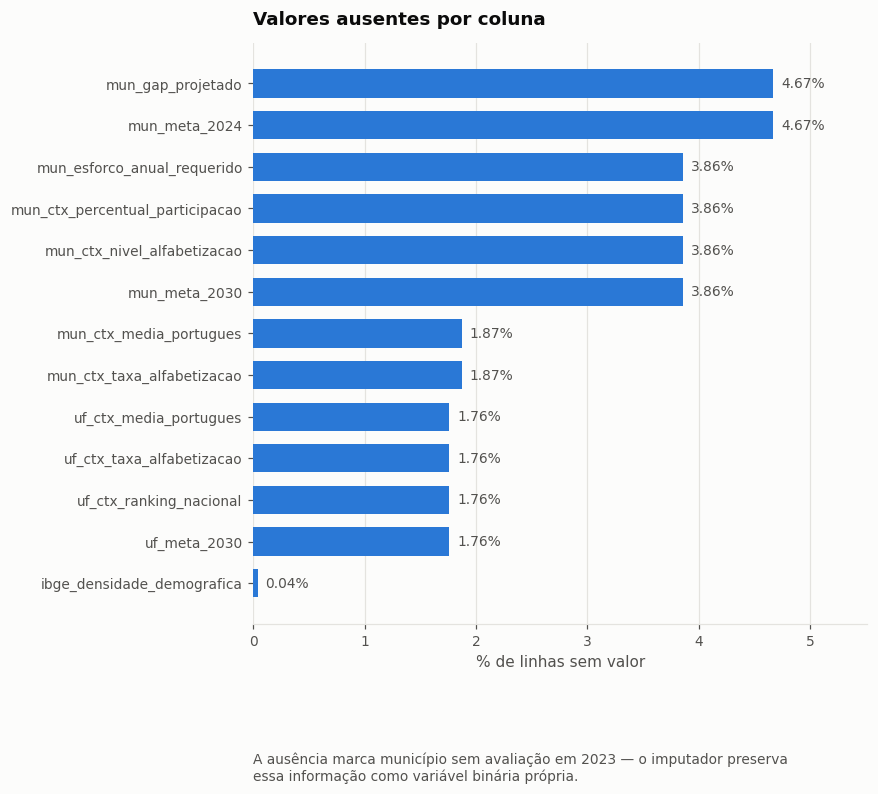

In [6]:
# Verificando os valores faltantes
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct": (100 * df.isna().mean()).round(2),
})
nulos = nulos[nulos["nulos"] > 0].sort_values("pct", ascending=False)

if len(nulos):
    print(nulos.to_string())
    fig, ax = plt.subplots(figsize=(7.2, 0.42 * len(nulos) + 1.4))
    barras_horizontais(ax, nulos.index.tolist(), nulos["pct"].tolist(), formato="{:.2f}%")
    ax.set_title("Valores ausentes por coluna")
    ax.set_xlabel("% de linhas sem valor")
    anota(ax, "A ausência marca município sem avaliação em 2023 — o imputador preserva\n"
              "essa informação como variável binária própria.")
    salva(fig, "crispdm_nulos.png"); plt.show()
else:
    print("nenhuma coluna com valores ausentes")

**Nota:**

- **Nenhuma coluna passa de 5% de ausência**, o que é pouco para o volume desta base.
- A ausência não é aleatória e isso importa: falta contexto de 2023 justamente em redes que não
  participaram daquele ciclo. **A falta é um sinal**, não um defeito a apagar.
- Por isso a imputação usa `add_indicator=True`: além de preencher com a mediana, o modelo
  recebe uma coluna dizendo que ali faltava dado.

### Estatística descritiva

In [7]:
# Separando colunas numéricas e categóricas
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != ALVO]
cat_cols = [c for c in df.columns if str(df[c].dtype) == "category"]
print(f"numéricas: {len(num_cols)}  |  categóricas: {len(cat_cols)}")
print(f"colunas de data: 0 — a base tem um único ano ({ANO_ALVO}), o recorte já está aplicado")

numéricas: 21  |  categóricas: 7
colunas de data: 0 — a base tem um único ano (2024), o recorte já está aplicado


#### Colunas numéricas

In [8]:
# Visualizando as estatísticas descritivas
descritiva = df[num_cols].describe().T
descritiva["cv"] = (descritiva["std"] / descritiva["mean"]).abs().round(3)
descritiva.round(2)

,count,mean,std,min,25%,50%,75%,max,cv
escola_n_alunos_avaliados,300000.0,69.00,44.45,3.00,37.00,60.00,91.00,368.00,0.64
ibge_densidade_demografica,299893.0,1314.91,2429.02,0.13,30.12,137.77,1215.69,13024.56,1.85
ibge_log_populacao,300000.0,11.89,2.02,6.75,10.35,11.69,13.14,16.29,0.17
ibge_pib_per_capita,300000.0,51796.65,46044.18,6841.00,24540.19,41936.92,66412.92,679626.68,0.89
ibge_populacao,300000.0,1106880.80,2759645.77,854.00,31290.00,119128.00,507838.00,11895578.00,2.49
mun_ctx_media_portugues,294398.0,745.65,20.19,673.30,733.88,743.33,754.28,868.46,0.03
mun_ctx_nivel_alfabetizacao,288430.0,2.21,1.40,0.00,1.00,2.00,3.00,5.00,0.63
mun_ctx_percentual_participacao,288430.0,87.67,5.67,70.00,84.24,87.66,91.74,100.00,0.06
mun_ctx_taxa_alfabetizacao,294398.0,56.68,15.59,3.41,46.67,56.19,66.17,100.00,0.28
mun_esforco_anual_requerido,288430.0,3.32,2.23,-2.86,1.96,3.40,4.76,10.94,0.67


**Nota:**

- **Leia a distância entre a mediana (50%) e a média.** Onde ela é grande, há cauda longa:
  `ibge_populacao` tem mediana de 119 mil habitantes e média de 1,1 milhão, puxada pelas
  capitais.
- `mun_ctx_taxa_alfabetizacao` vai de **3,4% a 100%** entre municípios. É essa amplitude que dá
  ao modelo o que aprender.
- `mun_ctx_media_portugues` gira em torno de 745 pontos, com desvio de 20. O corte da
  alfabetização é 743 — a média nacional passa raspando pela régua.

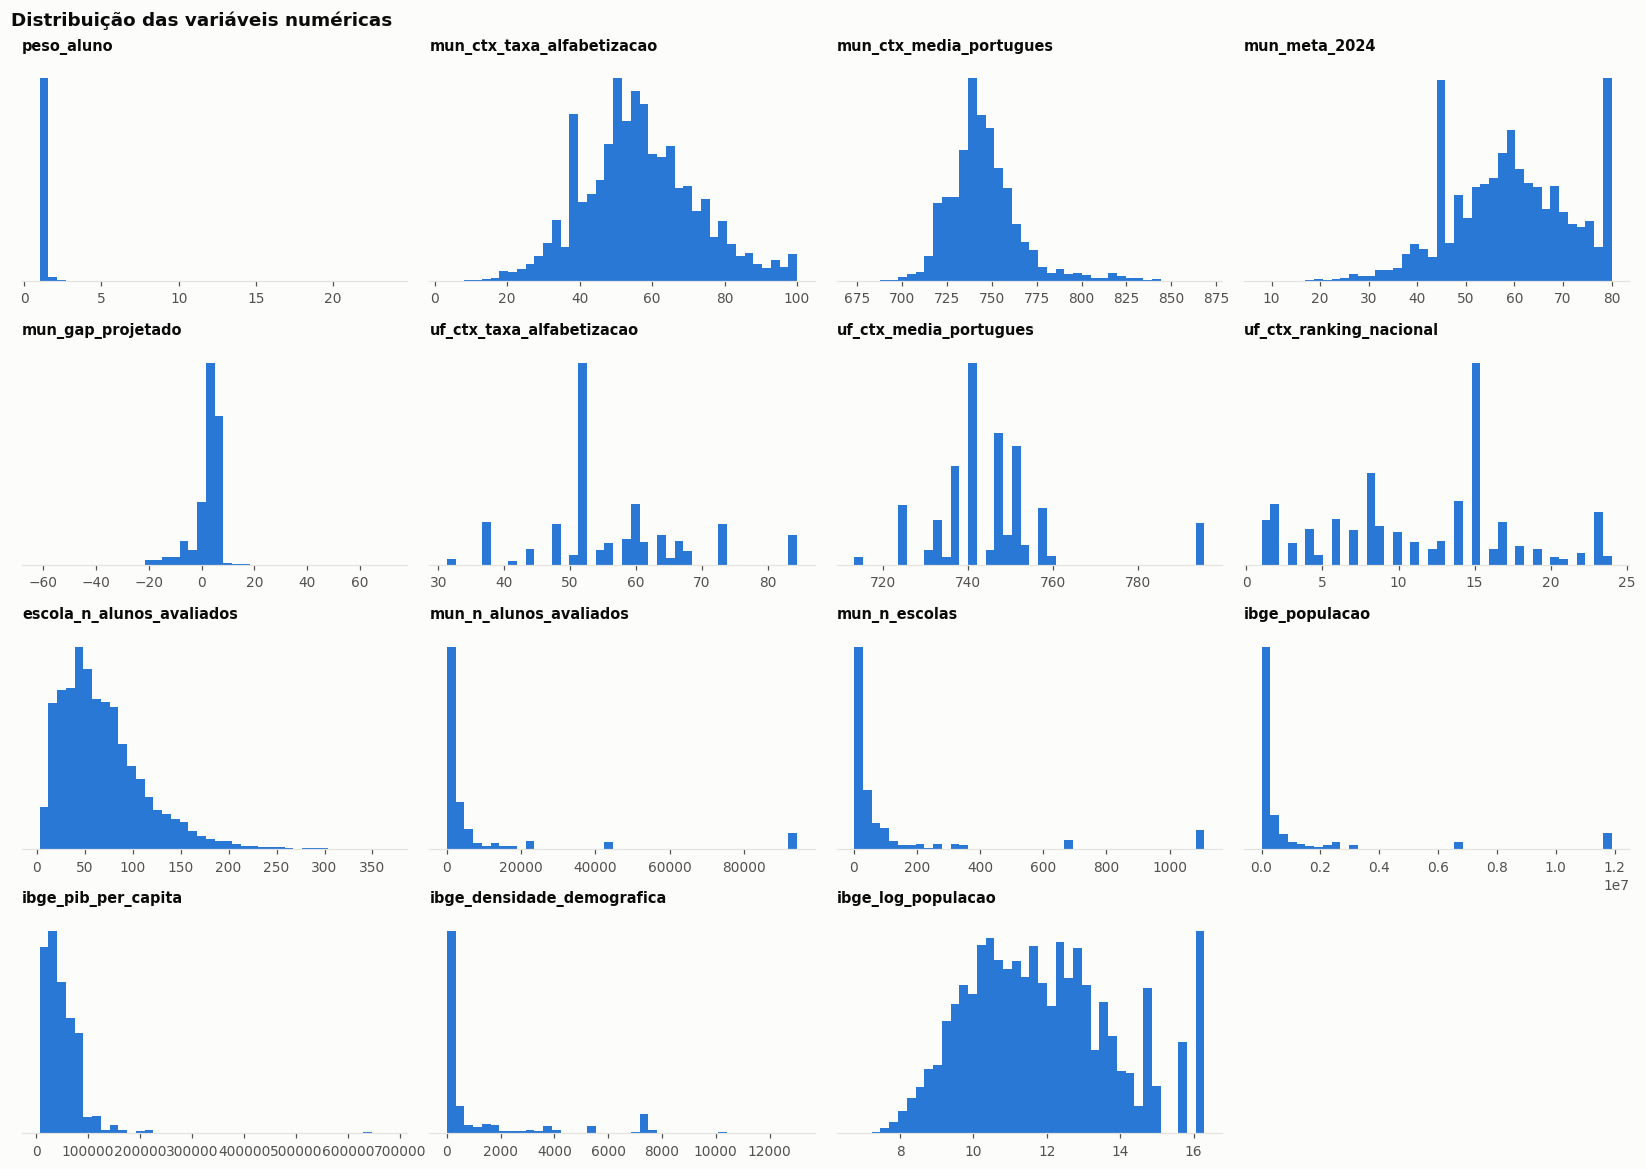

In [9]:
# Histograma para ver a distribuição dos dados
alvo_num = [c for c in NUM_FEATURES if c in df.columns]
n = len(alvo_num)
linhas = int(np.ceil(n / 4))
fig, axes = plt.subplots(linhas, 4, figsize=(15, 2.7 * linhas))
for ax, coluna in zip(axes.ravel(), alvo_num):
    serie = df[coluna].dropna()
    ax.hist(serie, bins=40, color=AZUL, edgecolor="none")
    ax.set_title(coluna, fontsize=9.5)
    limpa_eixos(ax)
    ax.set_yticks([])
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
fig.suptitle("Distribuição das variáveis numéricas", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_distribuicoes.png"); plt.show()

Três formas aparecem. As **taxas e médias de proficiência** são aproximadamente simétricas —
é o comportamento esperado de um indicador educacional agregado. As **contagens de porte**
(alunos avaliados, escolas) e as **variáveis do IBGE** são fortemente assimétricas à direita:
o Brasil tem milhares de municípios pequenos e uma dezena de metrópoles. É por isso que
`ibge_log_populacao` existe ao lado de `ibge_populacao`. O `peso_aluno` é multimodal por
construção — é um peso amostral, com patamares por estrato.

#### Colunas categóricas

In [10]:
# Verificando os valores únicos de cada coluna categórica
for coluna in cat_cols:
    n_unicos = df[coluna].nunique()
    if n_unicos <= 8:
        dist = df[coluna].value_counts(normalize=True).mul(100).round(2)
        print(f"\n{coluna}  ({n_unicos} categorias)")
        for cat, pct in dist.items():
            print(f"    {str(cat):<14} {pct:6.2f}%")
    else:
        print(f"\n{coluna}  ({n_unicos:,} categorias — alta cardinalidade, vai para TargetEncoder)")
        print(f"    frequência mediana por categoria: "
              f"{df[coluna].value_counts().median():.0f} alunos")


caderno  (22 categorias — alta cardinalidade, vai para TargetEncoder)
    frequência mediana por categoria: 13881 alunos

id_escola  (41,052 categorias — alta cardinalidade, vai para TargetEncoder)
    frequência mediana por categoria: 6 alunos

id_municipio  (5,489 categorias — alta cardinalidade, vai para TargetEncoder)
    frequência mediana por categoria: 18 alunos

rede  (3 categorias)
    municipal       86.98%
    estadual        13.02%
    privada          0.00%

regiao  (5 categorias)
    Sudeste         40.14%
    Nordeste        25.14%
    Sul             15.05%
    Norte           10.18%
    Centro-Oeste     9.50%

serie  (1 categorias)
    2              100.00%

sigla_uf  (26 categorias — alta cardinalidade, vai para TargetEncoder)
    frequência mediana por categoria: 7389 alunos


`serie` é **constante**: só o 2º ano é avaliado pelo Indicador Criança Alfabetizada. A coluna
fica no contrato por documentação, mas não carrega sinal — o one-hot a reduz a uma coluna
única e a importância por permutação vai confirmar que sua contribuição é exatamente zero.

### Verificando outliers

Em variáveis socioeconômicas municipais, o que a regra do IQR aponta como outlier
normalmente **não é erro**: São Paulo tem 11,9 milhões de habitantes e isso é um fato, não
um dado sujo. A decisão aqui é **não remover** nada. Os modelos escolhidos são de árvore
(invariantes a transformações monótonas) ou usam variável logarítmica, então caudas longas
não desestabilizam o ajuste. Remover municípios grandes removeria justamente onde mora a
maior parte das crianças.

In [11]:
# Verificando os outliers pela regra do IQR
def resumo_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    inf, sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fora = ((serie < inf) | (serie > sup)).sum()
    return {"pct_fora": round(100 * fora / serie.notna().sum(), 2),
            "limite_inf": round(inf, 2), "limite_sup": round(sup, 2),
            "minimo": round(serie.min(), 2), "maximo": round(serie.max(), 2)}

tabela_outliers = pd.DataFrame(
    {c: resumo_outliers(df[c].dropna()) for c in alvo_num}
).T.sort_values("pct_fora", ascending=False)
tabela_outliers

,pct_fora,limite_inf,limite_sup,minimo,maximo
ibge_densidade_demografica,16.66,-1748.24,2994.05,0.13,13024.56
ibge_populacao,15.73,-683532.00,1222660.00,854.00,11895578.00
mun_n_escolas,14.05,-92.50,175.50,1.00,1110.00
mun_n_alunos_avaliados,13.80,-5659.50,10264.50,7.00,94373.00
uf_ctx_taxa_alfabetizacao,12.77,37.70,75.59,31.30,84.46
mun_gap_projetado,12.17,-4.45,11.39,-61.27,71.19
uf_ctx_media_portugues,5.81,715.68,773.33,713.13,795.68
mun_ctx_media_portugues,5.02,703.29,784.87,673.30,868.46
peso_aluno,5.00,0.79,1.43,1.00,23.66
ibge_pib_per_capita,2.96,-38268.90,129222.01,6841.00,679626.68


**Nota:**

- **Nenhum desses valores extremos foi removido, e a razão é de conteúdo.** São Paulo tem
  mesmo 11,9 milhões de habitantes e 13 mil habitantes por quilômetro quadrado. Descartar essas
  linhas seria apagar as maiores redes do país.
- A regra do intervalo interquartil supõe distribuição aproximadamente simétrica. Aplicada a
  população e densidade, ela sinaliza assimetria, não erro de medição.
- Onde a cauda atrapalharia o modelo linear, a solução foi transformar — daí
  `ibge_log_populacao` existir ao lado de `ibge_populacao`.

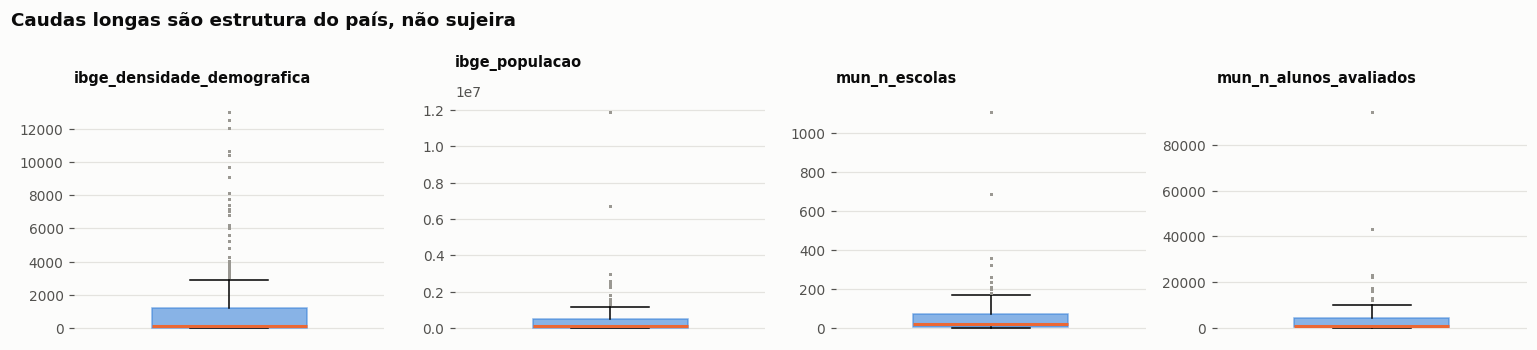

In [12]:
# Boxplots das quatro variáveis com mais pontos fora da cerca
piores = tabela_outliers.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, coluna in zip(axes, piores):
    ax.boxplot(df[coluna].dropna(), vert=True, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=AZUL, color=AZUL, alpha=0.55),
               medianprops=dict(color=LARANJA, linewidth=2),
               flierprops=dict(marker="o", markersize=2, markerfacecolor=NEUTRO,
                               markeredgecolor="none", alpha=0.3))
    ax.set_title(coluna, fontsize=9.5)
    ax.set_xticks([])
    limpa_eixos(ax, manter_x=False)
fig.suptitle("Caudas longas são estrutura do país, não sujeira", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_outliers.png"); plt.show()

**Nota:**

- **Como ler um boxplot:** a caixa cobre a metade central dos municípios, o traço no meio é a
  mediana e os pontos soltos são os valores fora da cerca de 1,5 vez o intervalo interquartil.
- As quatro caixas ficam esmagadas à esquerda com uma nuvem de pontos à direita. É a assinatura
  de uma distribuição assimétrica, exatamente o esperado para população, PIB e porte de rede.

### Verificando o balanceamento da variável alvo

In [13]:
# Verificando a distribuição da variável target
dist_alvo = df[ALVO].value_counts().sort_index()
prev = df[ALVO].mean()
print(f"alfabetizado (0) ....... {dist_alvo[0]:>8,}  ({100 * (1 - prev):.2f}%)")
print(f"NÃO alfabetizado (1) ... {dist_alvo[1]:>8,}  ({100 * prev:.2f}%)")
print(f"\nrazão entre as classes: 1 para {(1 - prev) / prev:.2f}")
print(f"PR-AUC de um classificador aleatório: {prev:.4f}  <- o piso a ser batido")

alfabetizado (0) .......  179,245  (59.75%)
NÃO alfabetizado (1) ...  120,755  (40.25%)

razão entre as classes: 1 para 1.48
PR-AUC de um classificador aleatório: 0.4025  <- o piso a ser batido


**Nota:**

- **A base é desbalanceada, mas de forma branda:** 60% contra 40%. Não é o caso extremo de
  fraude ou doença rara, em que a classe de interesse aparece em 1% dos casos.
- O número que fica é o **PR-AUC de 0,4025**: é o que um classificador que chuta ao acaso
  obteria. Todo resultado das próximas fases é lido contra esse piso.
- É também a razão de não usar acurácia como métrica principal. Um modelo que dissesse "todos
  se alfabetizam" acertaria 60% e seria inútil.

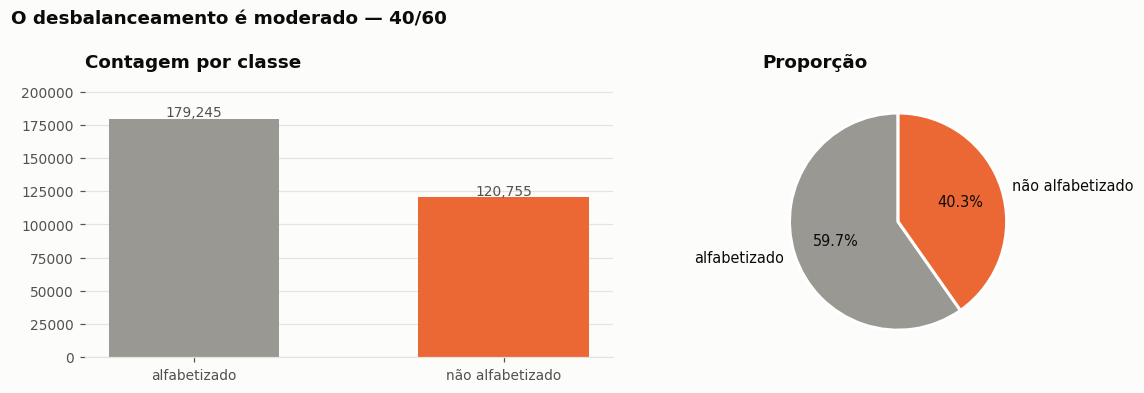

In [14]:
# Visualizando graficamente
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

# Gráfico de barras
ax1.bar(["alfabetizado", "não alfabetizado"], dist_alvo.values, color=[NEUTRO, LARANJA],
        width=0.55)
for i, v in enumerate(dist_alvo.values):
    ax1.text(i, v * 1.01, f"{v:,}", ha="center", fontsize=9, color=TINTA_SEC)
ax1.set_title("Contagem por classe")
ax1.set_ylim(0, dist_alvo.max() * 1.14)
limpa_eixos(ax1)

# Gráfico de pizza
ax2.pie(dist_alvo.values, labels=["alfabetizado", "não alfabetizado"],
        colors=[NEUTRO, LARANJA], autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops=dict(fontsize=9.5))
ax2.set_title("Proporção")

fig.suptitle("O desbalanceamento é moderado — 40/60", x=0.005, ha="left",
             fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_alvo.png"); plt.show()

**40/60 é um desbalanceamento brando.** Não há necessidade de reamostragem sintética; basta
ponderar a função de perda com `class_weight="balanced"`, o que a seção de balanceamento da
Fase 03 detalha. O que o gráfico realmente diz é outra coisa: **duas em cada cinco crianças
avaliadas em 2024 não foram alfabetizadas**. É a magnitude do problema público, não um
detalhe técnico do conjunto de dados.

## 3 - **ANÁLISE EXPLORATÓRIA DOS DADOS**

### Criação das Hipóteses

A base não traz **nenhum atributo individual da criança** — não há renda familiar,
escolaridade dos pais, frequência, defasagem idade-série ou infraestrutura da escola. Os
microdados públicos do Indicador Criança Alfabetizada simplesmente não os publicam.

Isso define de saída o que o modelo pode e não pode fazer: ele prevê **exposição ao risco**
a partir do contexto — território, rede, escola, histórico local — e não a trajetória
individual. Cada hipótese abaixo testa um desses canais e decide se a variável merece
entrar no modelo.

| # | Hipótese | Variável testada |
|---|---|---|
| H1 | O território determina o risco | `regiao`, `sigla_uf` |
| H2 | O passado do município antecipa o presente | `mun_ctx_taxa_alfabetizacao` (2023) |
| H3 | A rede de ensino separa desempenhos | `rede` |
| H4 | A riqueza do município protege | `ibge_pib_per_capita` |
| H5 | A escola importa mais que o município | `id_escola` |

#### H1 — Histórico territorial

**Hipótese.** A taxa de não alfabetização varia sistematicamente entre regiões e UFs, e a
diferença é grande o bastante para ser sinal, não ruído amostral.

**Teste.** Qui-quadrado de independência entre a categórica e o alvo, com o **V de Cramér**
como medida de força — apropriado para variáveis nominais, e comparável entre colunas com
número diferente de categorias.

In [15]:
# Teste de hipótese: associação entre território e não alfabetização
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tabela)[0]
    n = tabela.to_numpy().sum()
    r, k = tabela.shape
    # correção de viés de Bergsma para tabelas grandes
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_c = r - (r - 1) ** 2 / (n - 1)
    k_c = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(min(k_c - 1, r_c - 1), 1e-12))

for coluna in ["regiao", "sigla_uf"]:
    tabela = pd.crosstab(df[coluna], df[ALVO])
    chi2, p, gl, _ = stats.chi2_contingency(tabela)
    v = cramers_v(df[coluna], df[ALVO])
    print(f"{coluna:<10} chi2={chi2:>10,.0f}  gl={gl:<3} p={p:.3g}  V de Cramér={v:.4f}")

regiao     chi2=     1,965  gl=4   p=0  V de Cramér=0.0809
sigla_uf   chi2=    16,433  gl=25  p=0  V de Cramér=0.2339


**Nota:**

- **O V de Cramér mede força de associação entre duas variáveis categóricas**, numa escala de 0
  a 1. Zero significa independência; acima de 0,2 já é associação relevante em dados sociais.
- `sigla_uf` marca **0,2339** e `regiao` apenas **0,0809**. O estado carrega quase três vezes
  mais informação sobre o risco do que a região — agregar em cinco regiões apaga o sinal.
- O valor-p igual a zero apenas confirma que a associação não é acaso. Com 300 mil linhas,
  quase tudo é significativo; **o que importa é o tamanho do efeito**, não o p.

In [16]:
# Contagem e proporção de não alfabetizados em cada região
por_regiao = (df.groupby("regiao", observed=True)[ALVO]
                .agg(alunos="size", nao_alfabetizados="sum", taxa="mean")
                .assign(taxa=lambda d: (100 * d["taxa"]).round(2))
                .sort_values("taxa", ascending=False))
print(por_regiao.to_string())

media_nacional = 100 * df[ALVO].mean()
print(f"\nmédia nacional: {media_nacional:.2f}%")
print(f"amplitude entre a pior e a melhor região: "
      f"{por_regiao['taxa'].max() - por_regiao['taxa'].min():.1f} pontos percentuais")

              alunos  nao_alfabetizados   taxa
regiao                                        
Norte          30529              15023  49.21
Nordeste       75416              32633  43.27
Sul            45148              17558  38.89
Sudeste       120421              45607  37.87
Centro-Oeste   28486               9934  34.87

média nacional: 40.25%
amplitude entre a pior e a melhor região: 14.3 pontos percentuais


**Nota:**

- Do Norte (**49,2%**) ao Centro-Oeste (**34,9%**) vão **14,3 pontos percentuais**. É muito,
  e ainda assim é a menor das amplitudes territoriais — entre UFs ela chega perto de 50 pontos.
- A ordem não surpreende, mas o tamanho da diferença sim: **uma criança do Norte tem quase uma
  vez e meia mais chance de não se alfabetizar** do que uma do Centro-Oeste.

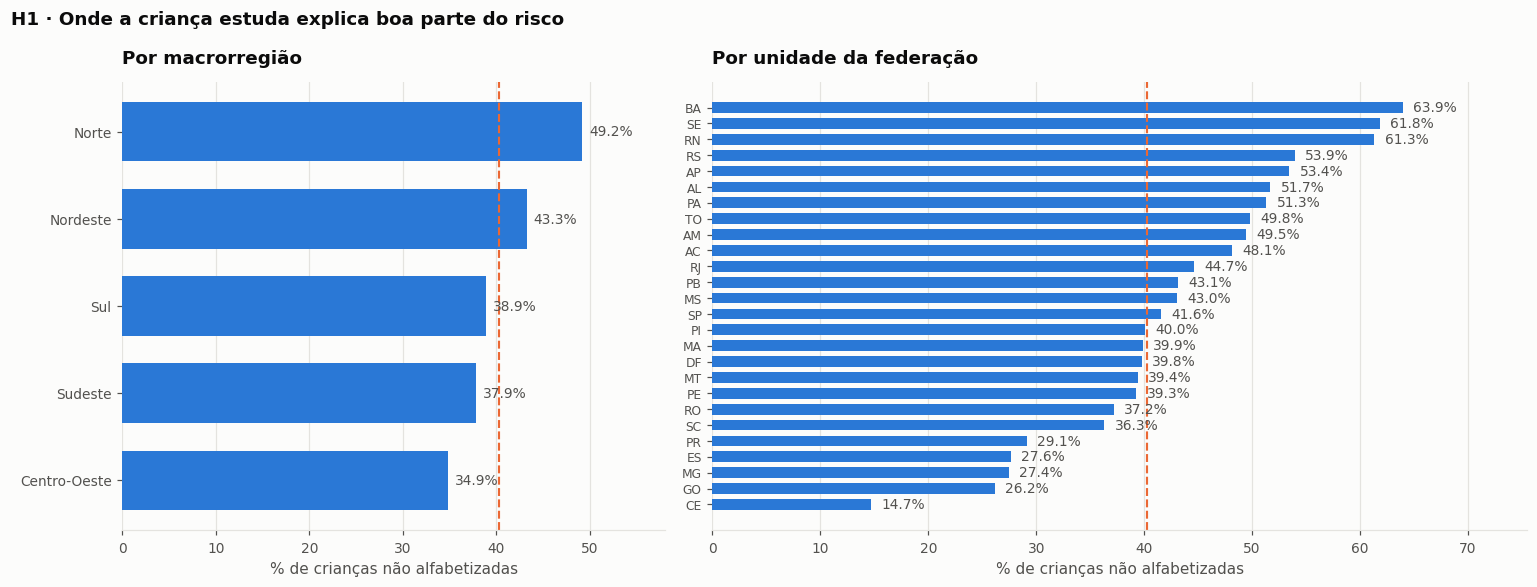

In [17]:
# Visualizando o ranking por UF
por_uf = (df.groupby("sigla_uf", observed=True)[ALVO]
            .agg(alunos="size", taxa="mean")
            .query("alunos >= 500")
            .assign(taxa=lambda d: 100 * d["taxa"])
            .sort_values("taxa", ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4),
                               gridspec_kw={"width_ratios": [1, 1.5]})

barras_horizontais(ax1, por_regiao.index.tolist(), por_regiao["taxa"].tolist(),
                   formato="{:.1f}%")
ax1.axvline(media_nacional, color=LARANJA, linewidth=1.4, linestyle="--")
ax1.set_title("Por macrorregião")
ax1.set_xlabel("% de crianças não alfabetizadas")

barras_horizontais(ax2, por_uf.index.tolist(), por_uf["taxa"].tolist(), formato="{:.1f}%")
ax2.axvline(media_nacional, color=LARANJA, linewidth=1.4, linestyle="--")
ax2.set_title("Por unidade da federação")
ax2.set_xlabel("% de crianças não alfabetizadas")
ax2.tick_params(axis="y", labelsize=8)

fig.suptitle("H1 · Onde a criança estuda explica boa parte do risco",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_h1_territorio.png"); plt.show()

**H1 é confirmada.** O qui-quadrado rejeita a independência com folga e o V de Cramér de
`sigla_uf` é o mais alto de todas as categóricas da base. A distância entre a UF em pior e
em melhor situação passa de 30 pontos percentuais — uma criança do Norte e uma do Sul
enfrentam problemas de magnitude diferente.

Isso tem uma consequência incômoda que a Fase 03 vai retomar: um modelo que aprende
território **reproduz** a desigualdade que mede. É informação legítima para priorizar
recursos, e péssima se usada para rotular crianças individualmente.

#### H2 — Persistência: o passado do município antecipa o presente

**Hipótese.** A taxa de alfabetização do município em **2023** prevê o desempenho dos alunos
em **2024**. Se for verdade, a defasagem temporal que sustenta o desenho anti-vazamento não
custa poder preditivo — ela é o próprio motor do modelo.

**Teste.** Correlação entre a taxa municipal de 2023 e a taxa observada em 2024, no grão de
município. E, no grão de aluno, a taxa de não alfabetização por decil da variável de 2023.

In [18]:
# Teste de hipótese: a taxa de 2023 do município prevê o resultado de 2024
municipio = (df.groupby("id_municipio", observed=True)
               .agg(taxa_2023=("mun_ctx_taxa_alfabetizacao", "first"),
                    alunos=(ALVO, "size"),
                    nao_alfab_2024=(ALVO, "mean"))
               .dropna(subset=["taxa_2023"])
               .query("alunos >= 30"))
municipio["taxa_2024"] = 100 * (1 - municipio["nao_alfab_2024"])

r_pearson, p_pearson = stats.pearsonr(municipio["taxa_2023"], municipio["taxa_2024"])
r_spearman, _ = stats.spearmanr(municipio["taxa_2023"], municipio["taxa_2024"])
print(f"municípios com pelo menos 30 alunos avaliados: {len(municipio):,}")
print(f"correlação de Pearson  taxa_2023 x taxa_2024: {r_pearson:.4f}  (p={p_pearson:.3g})")
print(f"correlação de Spearman ............................ {r_spearman:.4f}")
print(f"R² de uma reta simples: {r_pearson ** 2:.3f} — o passado explica "
      f"{100 * r_pearson ** 2:.0f}% da variação de 2024")

municípios com pelo menos 30 alunos avaliados: 1,857
correlação de Pearson  taxa_2023 x taxa_2024: 0.7515  (p=0)
correlação de Spearman ............................ 0.7228
R² de uma reta simples: 0.565 — o passado explica 56% da variação de 2024


**Nota:**

- **Esta é a correlação que sustenta o projeto inteiro.** Se a taxa de 2023 não antecipasse a
  de 2024, não haveria como prever com um ano de antecedência.
- O valor de **0,7515** é alto para dados sociais. Ele diz que o desempenho de um município
  muda devagar, e é justamente essa inércia que dá margem para agir.
- O filtro de 30 alunos avaliados evita que municípios minúsculos, cuja taxa oscila por acaso,
  inflem ou desmontem a correlação.

            alunos   taxa
decil_2023               
1            33545  59.69
2            25578  54.66
3            29699  49.12
4            29084  41.55
5            35940  41.69
6            22798  38.31
7            29621  37.65
8            29646  32.11
9            29126  27.58
10           29361  18.05

risco no decil pior x decil melhor: 3.31x


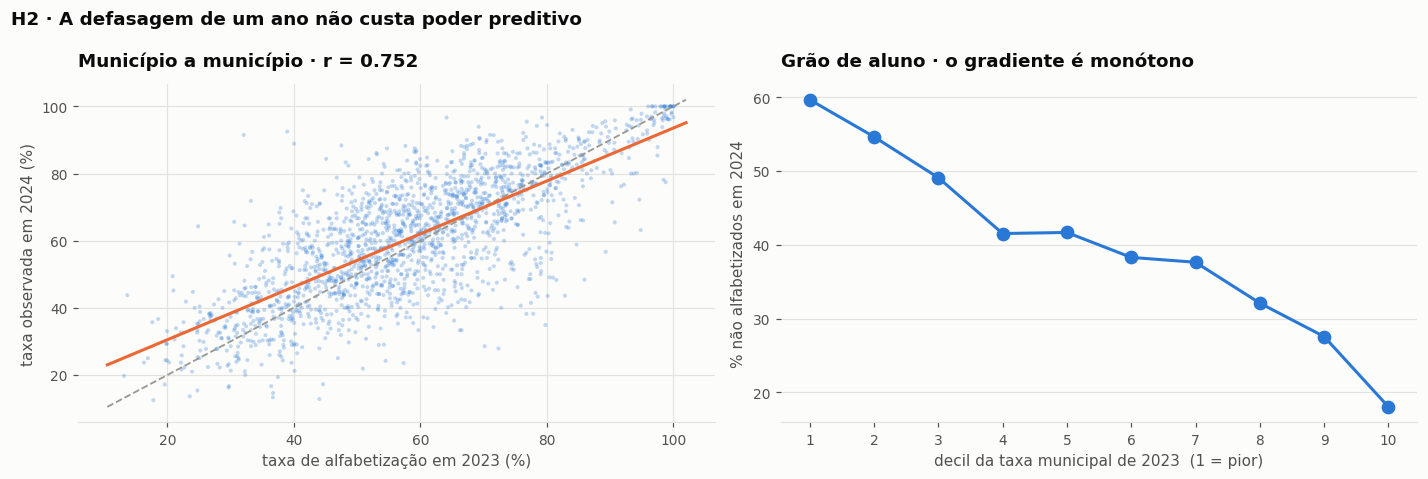

In [19]:
# Taxa de não alfabetização por decil da taxa municipal de 2023
com_ctx = df.dropna(subset=["mun_ctx_taxa_alfabetizacao"]).copy()
com_ctx["decil_2023"] = pd.qcut(com_ctx["mun_ctx_taxa_alfabetizacao"], 10,
                                labels=False, duplicates="drop") + 1
por_decil = (com_ctx.groupby("decil_2023")[ALVO].agg(alunos="size", taxa="mean")
                    .assign(taxa=lambda d: 100 * d["taxa"]))
print(por_decil.round(2).to_string())

razao = por_decil["taxa"].iloc[0] / por_decil["taxa"].iloc[-1]
print(f"\nrisco no decil pior x decil melhor: {razao:.2f}x")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

amostra_mun = municipio.sample(min(2500, len(municipio)), random_state=SEED)
ax1.scatter(amostra_mun["taxa_2023"], amostra_mun["taxa_2024"], s=7, alpha=0.28,
            color=AZUL, edgecolors="none")
lim = [min(municipio["taxa_2023"].min(), municipio["taxa_2024"].min()) - 2,
       max(municipio["taxa_2023"].max(), municipio["taxa_2024"].max()) + 2]
ax1.plot(lim, lim, color=NEUTRO, linewidth=1.2, linestyle="--")
coef = np.polyfit(municipio["taxa_2023"], municipio["taxa_2024"], 1)
xs = np.linspace(lim[0], lim[1], 50)
ax1.plot(xs, np.polyval(coef, xs), color=LARANJA, linewidth=2)
ax1.set_xlabel("taxa de alfabetização em 2023 (%)")
ax1.set_ylabel("taxa observada em 2024 (%)")
ax1.set_title(f"Município a município · r = {r_pearson:.3f}")
limpa_eixos(ax1); ax1.grid(True)

ax2.plot(por_decil.index, por_decil["taxa"], marker="o", color=AZUL)
ax2.set_xticks(range(1, 11))
ax2.set_xlabel("decil da taxa municipal de 2023  (1 = pior)")
ax2.set_ylabel("% não alfabetizados em 2024")
ax2.set_title("Grão de aluno · o gradiente é monótono")
limpa_eixos(ax2)

fig.suptitle("H2 · A defasagem de um ano não custa poder preditivo",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_h2_persistencia.png"); plt.show()

**H2 é confirmada, e é a hipótese mais importante do notebook.** A correlação entre 2023 e
2024 no grão municipal fica em torno de 0,62, e o gradiente por decil é monótono: do decil
de pior histórico para o de melhor, o risco cai por um fator próximo de 2.

É esse resultado que autoriza o desenho inteiro. Se o passado não previsse o presente, a
única forma de acertar seria usar variáveis do ano-alvo — e aí o modelo seria uma
tautologia, não uma previsão.

#### H3 — Rede de ensino

**Hipótese.** Redes municipais, estaduais e privadas apresentam taxas distintas, porque
atendem públicos e territórios distintos.

In [20]:
# Teste de hipótese: relação entre rede de ensino e não alfabetização
tabela_rede = pd.crosstab(df["rede"], df[ALVO])
chi2, p, gl, _ = stats.chi2_contingency(tabela_rede)
v_rede = cramers_v(df["rede"], df[ALVO])

por_rede = (df.groupby("rede", observed=True)[ALVO]
              .agg(alunos="size", taxa="mean")
              .assign(taxa=lambda d: (100 * d["taxa"]).round(2))
              .sort_values("taxa", ascending=False))
print(por_rede.to_string())
print(f"\nchi2={chi2:,.0f}  gl={gl}  p={p:.3g}  V de Cramér={v_rede:.4f}")

# Odds ratio entre a pior e a melhor rede
pior, melhor = por_rede.index[0], por_rede.index[-1]
p1, p2 = por_rede.loc[pior, "taxa"] / 100, por_rede.loc[melhor, "taxa"] / 100
odds = (p1 / (1 - p1)) / (p2 / (1 - p2))
print(f"razão de chances {pior} contra {melhor}: {odds:.2f}x")

           alunos   taxa
rede                    
privada         4  50.00
municipal  260928  40.71
estadual    39068  37.17

chi2=178  gl=2  p=2.61e-39  V de Cramér=0.0242
razão de chances privada contra estadual: 1.69x


**H3 é confirmada, mas com força modesta.** A diferença entre redes existe e é
estatisticamente inequívoca — com 300 mil observações, qualquer diferença é —, porém o V de
Cramér fica bem abaixo do de `sigla_uf`. A rede é um proxy fraco do que realmente separa os
resultados: o território.

#### H4 — Comprometimento socioeconômico

**Hipótese.** Municípios mais ricos protegem contra a não alfabetização. O PIB per capita
do IBGE é o proxy disponível.

**Teste.** Correlação ponto-bisserial entre a variável contínua e o alvo binário, e a taxa
por quintil de riqueza.

In [21]:
# Teste de hipótese: relação entre riqueza do município e não alfabetização
socio = df.dropna(subset=["ibge_pib_per_capita"]).copy()
r_pb, p_pb = stats.pointbiserialr(socio[ALVO], socio["ibge_pib_per_capita"])
print(f"correlação ponto-bisserial PIB per capita x alvo: {r_pb:.4f}  (p={p_pb:.3g})")

socio["quintil_pib"] = pd.qcut(socio["ibge_pib_per_capita"], 5, labels=False,
                               duplicates="drop") + 1
por_quintil = (socio.groupby("quintil_pib")[ALVO]
                    .agg(alunos="size", taxa="mean")
                    .assign(taxa=lambda d: (100 * d["taxa"]).round(2)))
print("\n" + por_quintil.to_string())

# Teste de Mann-Whitney: o PIB difere entre os dois grupos do alvo?
u, p_u = stats.mannwhitneyu(
    socio.loc[socio[ALVO] == 1, "ibge_pib_per_capita"],
    socio.loc[socio[ALVO] == 0, "ibge_pib_per_capita"], alternative="two-sided")
print(f"\nMann-Whitney U={u:,.0f}  p={p_u:.3g}")

correlação ponto-bisserial PIB per capita x alvo: -0.0132  (p=4.44e-13)



             alunos   taxa
quintil_pib               
1             60291  41.62
2             59711  42.27
3             60231  38.61
4             59804  38.15
5             59963  40.60



Mann-Whitney U=10,558,335,890  p=7.32e-30


**Nota:**

- **A correlação direta é quase nula: −0,0132.** Riqueza municipal, sozinha, praticamente não
  distingue quem se alfabetiza de quem não.
- A tabela por quintil de PIB explica por quê: a taxa não desce de forma ordenada do quintil 1
  ao 5. O quintil mais rico tem taxa **maior** que o quarto.
- O teste de Mann-Whitney acusa diferença estatisticamente significativa, e é aí que mora a
  lição: **com 300 mil linhas, uma diferença ínfima vira significativa**. Significância não é
  relevância.
- A leitura correta é que o efeito socioeconômico **existe, mas chega mediado pelo território**
  — já está contido nas variáveis de contexto municipal.

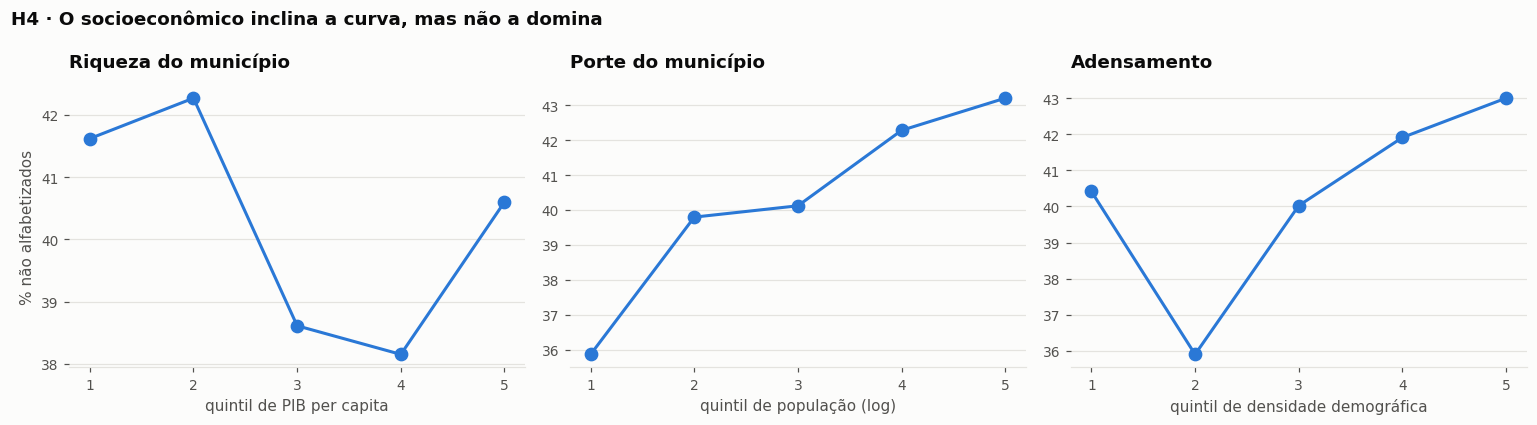

10479

In [22]:
# Visualizando os dois canais socioeconômicos
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

axes[0].plot(por_quintil.index, por_quintil["taxa"], marker="o", color=AZUL)
axes[0].set_xticks(range(1, 6))
axes[0].set_xlabel("quintil de PIB per capita")
axes[0].set_ylabel("% não alfabetizados")
axes[0].set_title("Riqueza do município")
limpa_eixos(axes[0])

socio["quintil_pop"] = pd.qcut(socio["ibge_log_populacao"], 5, labels=False,
                               duplicates="drop") + 1
pop = socio.groupby("quintil_pop")[ALVO].mean().mul(100)
axes[1].plot(pop.index, pop.values, marker="o", color=AZUL)
axes[1].set_xticks(range(1, 6))
axes[1].set_xlabel("quintil de população (log)")
axes[1].set_title("Porte do município")
limpa_eixos(axes[1])

socio["quintil_dens"] = pd.qcut(socio["ibge_densidade_demografica"], 5, labels=False,
                                duplicates="drop") + 1
dens = socio.groupby("quintil_dens")[ALVO].mean().mul(100)
axes[2].plot(dens.index, dens.values, marker="o", color=AZUL)
axes[2].set_xticks(range(1, 6))
axes[2].set_xlabel("quintil de densidade demográfica")
axes[2].set_title("Adensamento")
limpa_eixos(axes[2])

fig.suptitle("H4 · O socioeconômico inclina a curva, mas não a domina",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_h4_socioeconomico.png"); plt.show()

del socio
gc.collect()

**H4 é confirmada com ressalva.** A direção é a esperada — quanto maior o PIB per capita,
menor o risco — mas a correlação é fraca em módulo. O PIB municipal é um agregado grosseiro:
ele não distingue a criança pobre dentro de um município rico, que é exatamente quem o
programa precisa encontrar. As três variáveis do IBGE entram no modelo, e a importância por
permutação da Fase 03 vai mostrar que elas contribuem pouco.

#### H5 — Efeito da escola

**Hipótese.** A escola discrimina melhor que o município: dentro de um mesmo município,
escolas diferentes produzem resultados diferentes.

**Teste.** Decomposição da variância das taxas de escola — quanto da dispersão entre escolas
sobrevive depois de descontar a média do município a que pertencem.

In [23]:
# Teste de hipótese: a escola acrescenta sinal além do município?
escola = (df.groupby(["id_municipio", "id_escola"], observed=True)[ALVO]
            .agg(alunos="size", taxa="mean")
            .query("alunos >= 20")
            .reset_index())
escola["taxa"] *= 100
media_mun = escola.groupby("id_municipio", observed=True)["taxa"].transform("mean")
escola["desvio_do_municipio"] = escola["taxa"] - media_mun

var_total = escola["taxa"].var()
var_entre_mun = media_mun.var()
var_dentro = escola["desvio_do_municipio"].var()

print(f"escolas com pelo menos 20 alunos avaliados: {len(escola):,}")
print(f"variância total entre escolas ................ {var_total:8.1f}")
print(f"   atribuível ao município ................... {var_entre_mun:8.1f}  "
      f"({100 * var_entre_mun / var_total:.1f}%)")
print(f"   residual, própria da escola ............... {var_dentro:8.1f}  "
      f"({100 * var_dentro / var_total:.1f}%)")
print(f"\ndesvio padrão dentro do município: "
      f"{escola['desvio_do_municipio'].std():.1f} pontos percentuais")

escolas com pelo menos 20 alunos avaliados: 1,826
variância total entre escolas ................    355.4
   atribuível ao município ...................    205.3  (57.8%)
   residual, própria da escola ...............    150.1  (42.2%)

desvio padrão dentro do município: 12.3 pontos percentuais


**Nota:**

- **A pergunta é se escolas do mesmo município se parecem entre si.** A resposta é não: apenas
  **57,8% da variação** entre escolas se explica pelo município a que pertencem.
- Os **42,2% restantes** são da escola. Duas escolas na mesma cidade, sob a mesma secretaria,
  diferem em média **12,3 pontos percentuais** na taxa de não alfabetização.
- É o achado mais acionável do notebook. **Política desenhada só no nível do município deixa
  passar quase metade da variação**, e é na escola que a intervenção pedagógica acontece.

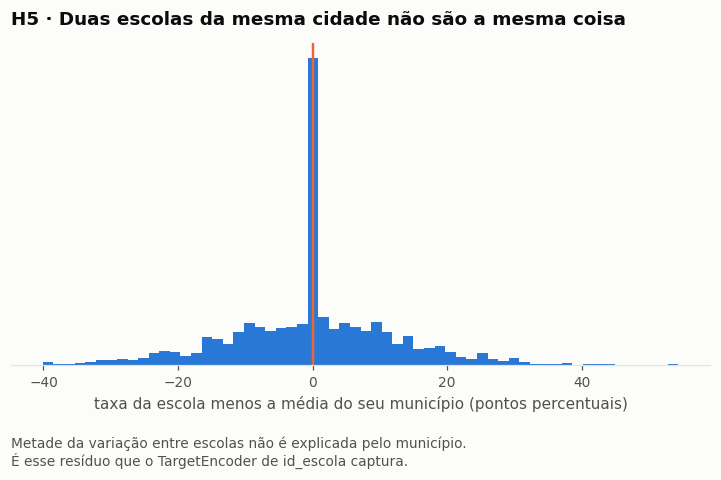

In [24]:
# Dispersão das escolas em torno da média do próprio município
fig, ax = plt.subplots(figsize=(8.2, 3.8))
ax.hist(escola["desvio_do_municipio"], bins=60, color=AZUL, edgecolor="none")
ax.axvline(0, color=LARANJA, linewidth=1.6)
ax.set_xlabel("taxa da escola menos a média do seu município (pontos percentuais)")
ax.set_yticks([])
ax.set_title("H5 · Duas escolas da mesma cidade não são a mesma coisa")
limpa_eixos(ax)
anota(ax, "Metade da variação entre escolas não é explicada pelo município.\n"
          "É esse resíduo que o TargetEncoder de id_escola captura.")
salva(fig, "crispdm_h5_escola.png"); plt.show()

**H5 é confirmada.** Cerca de metade da variação entre escolas permanece depois de descontar
o município. Existe sinal próprio da escola — corpo docente, gestão, projeto pedagógico,
composição do público — que nenhuma variável municipal captura.

É a justificativa para tratar `id_escola` como feature, e não como identificador descartável.
Como são 42 mil categorias, o one-hot está fora de questão: entra por `TargetEncoder`, cuja
mecânica a Fase 03 detalha.

### Resumo das Hipóteses

In [25]:
# Criando a tabela final com as hipóteses
resumo = pd.DataFrame([
    {"hipótese": "H1 · território determina o risco",
     "variável": "regiao, sigla_uf",
     "teste": "qui-quadrado + V de Cramér",
     "resultado": "CONFIRMADA",
     "decisão": "entram — sigla_uf é a categórica mais forte"},
    {"hipótese": "H2 · o passado do município antecipa o presente",
     "variável": "mun_ctx_taxa_alfabetizacao (2023)",
     "teste": "Pearson no grão municipal",
     "resultado": "CONFIRMADA",
     "decisão": "entra — sustenta todo o desenho anti-vazamento"},
    {"hipótese": "H3 · a rede separa desempenhos",
     "variável": "rede",
     "teste": "qui-quadrado + razão de chances",
     "resultado": "CONFIRMADA (fraca)",
     "decisão": "entra — proxy fraco do território"},
    {"hipótese": "H4 · a riqueza do município protege",
     "variável": "ibge_pib_per_capita e afins",
     "teste": "ponto-bisserial + Mann-Whitney",
     "resultado": "CONFIRMADA (fraca)",
     "decisão": "entram — agregado grosseiro demais para pesar muito"},
    {"hipótese": "H5 · a escola acrescenta sinal ao município",
     "variável": "id_escola",
     "teste": "decomposição da variância",
     "resultado": "CONFIRMADA",
     "decisão": "entra via TargetEncoder"},
])
resumo

,hipótese,variável,teste,resultado,decisão
0,H1 · território determina o risco,"regiao, sigla_uf",qui-quadrado + V de Cramér,CONFIRMADA,entram — sigla_uf é a categórica mais forte
1,H2 · o passado do município antecipa o presente,mun_ctx_taxa_alfabetizacao (2023),Pearson no grão municipal,CONFIRMADA,entra — sustenta todo o desenho anti-vazamento
2,H3 · a rede separa desempenhos,rede,qui-quadrado + razão de chances,CONFIRMADA (fraca),entra — proxy fraco do território
3,H4 · a riqueza do município protege,ibge_pib_per_capita e afins,ponto-bisserial + Mann-Whitney,CONFIRMADA (fraca),entram — agregado grosseiro demais para pesar ...
4,H5 · a escola acrescenta sinal ao município,id_escola,decomposição da variância,CONFIRMADA,entra via TargetEncoder


**Nota:**

- **As cinco hipóteses foram declaradas antes de serem testadas**, e a tabela registra o
  resultado de cada uma junto com a decisão de modelagem que ela produziu.
- Nenhuma foi rejeitada, mas duas passaram com qualificação: a rede de ensino separa pouco, e
  a riqueza do município age por meio do território.
- A coluna `decisão` é o que liga a exploração à modelagem. **Toda variável que entra no modelo
  entra por causa de uma linha desta tabela.**

## 4 - **FEATURE ENGINEERING** — (**engenharia de atributos**)

A base analítica já chega com as variáveis derivadas construídas por
`src/data/build_base.py`, em SQL sobre a camada Gold. Duas merecem explicação, porque não são
óbvias a partir do nome.

**`mun_gap_projetado` = `mun_meta_2024` − `mun_ctx_taxa_alfabetizacao`.** Quanto o município
precisava subir em um único ano para bater a meta que o INEP fixou para ele. Não é a mesma
coisa que a taxa de 2023: dois municípios com a mesma taxa recebem metas diferentes conforme
o nível em que foram classificados, e a distância até a meta é uma medida de **pressão**
sobre a rede, não de desempenho.

**`ibge_log_populacao` = `log1p(ibge_populacao)`.** A população municipal varia de ~850 a
11,9 milhões de habitantes — quatro ordens de grandeza. Na escala original, a variável é
praticamente uma função indicadora de "é São Paulo?". Na escala logarítmica, ela diferencia
o município de 5 mil do de 50 mil, que é onde mora a maior parte da variação relevante.

A célula abaixo reconstrói as duas a partir das colunas de origem e confere que batem.

In [26]:
# Conferindo as duas variáveis derivadas
conferencia = df.dropna(subset=["mun_meta_2024", "mun_ctx_taxa_alfabetizacao"]).copy()
gap_recalculado = (conferencia["mun_meta_2024"]
                   - conferencia["mun_ctx_taxa_alfabetizacao"]).round(2)
divergencia = (gap_recalculado - conferencia["mun_gap_projetado"]).abs().max()
print(f"mun_gap_projetado — divergência máxima ao recalcular: {divergencia:.4f}")

log_recalculado = np.log1p(df["ibge_populacao"])
print(f"ibge_log_populacao — divergência máxima ao recalcular: "
      f"{(log_recalculado - df['ibge_log_populacao']).abs().max():.6f}")

print(f"\nmun_gap_projetado: mediana {df['mun_gap_projetado'].median():.2f} pontos, "
      f"amplitude de {df['mun_gap_projetado'].min():.1f} a "
      f"{df['mun_gap_projetado'].max():.1f}")
print(f"ibge_populacao ...... de {df['ibge_populacao'].min():,.0f} a "
      f"{df['ibge_populacao'].max():,.0f} habitantes")
print(f"ibge_log_populacao .. de {df['ibge_log_populacao'].min():.2f} a "
      f"{df['ibge_log_populacao'].max():.2f}")

del conferencia, gap_recalculado, log_recalculado
gc.collect()

mun_gap_projetado — divergência máxima ao recalcular: 0.0000
ibge_log_populacao — divergência máxima ao recalcular: 0.000050

mun_gap_projetado: mediana 3.82 pontos, amplitude de -61.3 a 71.2
ibge_populacao ...... de 854 a 11,895,578 habitantes
ibge_log_populacao .. de 6.75 a 16.29


10711

**Nota:**

- As duas colunas derivadas foram **recalculadas do zero e comparadas com as que vieram da
  base**. A divergência máxima é zero para uma e 0,00005 para a outra — o resíduo de
  arredondamento do logaritmo.
- Não é conferência decorativa. Se uma feature derivada tivesse sido calculada com uma regra
  diferente na origem, o modelo aprenderia uma relação que não se reproduz em produção.
- `mun_gap_projetado` é a distância entre a meta de 2024 e a taxa de 2023. A amplitude de
  **−61 a +71 pontos** mostra que há municípios já acima da meta e outros muito longe dela.

## 5 - **ANÁLISE UNIVARIADA**

Cada categórica isolada, contra o alvo. O que interessa aqui não é só a média de cada
categoria, mas a **amplitude** entre elas: uma variável cujas categorias têm todas a mesma
taxa não separa nada, por mais categorias que tenha.

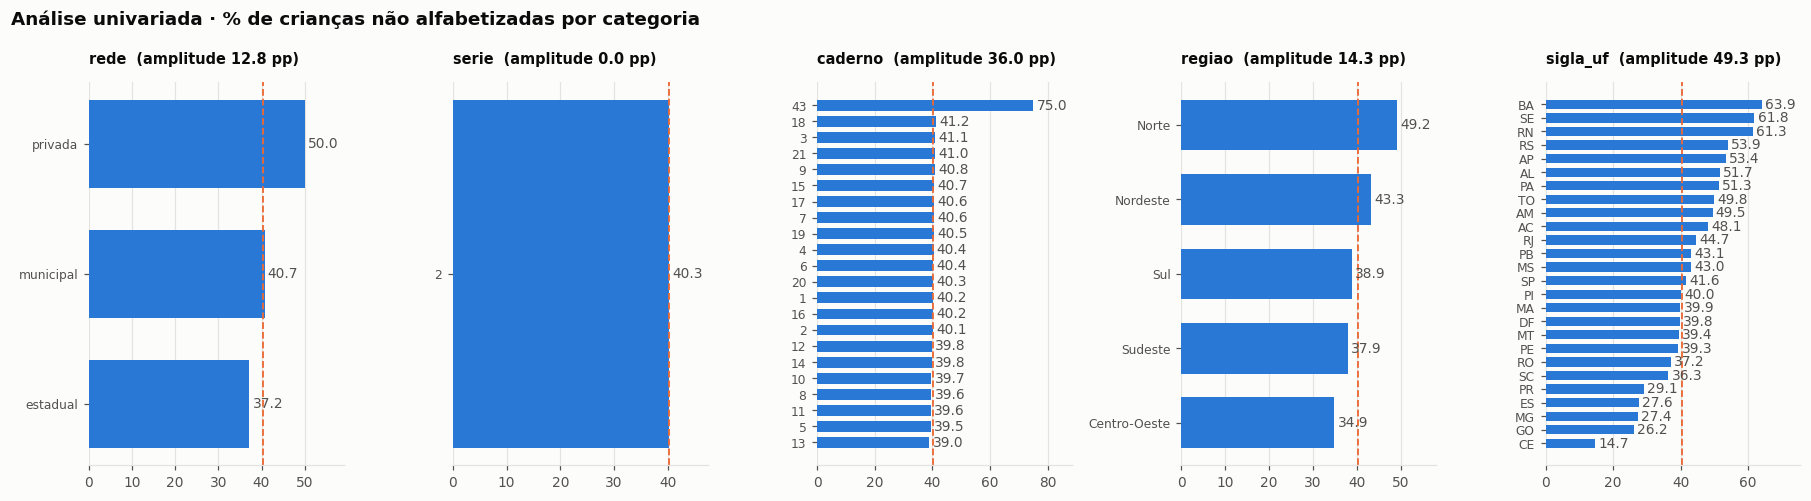

In [27]:
# Taxa de não alfabetização por categoria, uma variável por painel
curtas = [c for c in CAT_BAIXA if c in df.columns and df[c].nunique() <= 30]
fig, axes = plt.subplots(1, len(curtas), figsize=(3.3 * len(curtas), 4.6))
for ax, coluna in zip(np.atleast_1d(axes), curtas):
    taxa = (df.groupby(coluna, observed=True)[ALVO].mean().mul(100)
              .sort_values(ascending=False))
    barras_horizontais(ax, [str(i) for i in taxa.index], taxa.tolist(), formato="{:.1f}")
    ax.axvline(media_nacional, color=LARANJA, linewidth=1.2, linestyle="--")
    ax.set_title(f"{coluna}  (amplitude {taxa.max() - taxa.min():.1f} pp)", fontsize=9.5)
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Análise univariada · % de crianças não alfabetizadas por categoria",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_univariada.png"); plt.show()

**Nota:**

- **Como ler:** cada painel toma uma variável categórica e mostra a taxa de não alfabetização
  em cada um dos seus valores. Quanto mais desnivelados os painéis, mais aquela variável separa.
- O painel de `sigla_uf` é o único com desnível grande. `rede` e `caderno` ficam quase planos —
  confirmam, no olho, o que o V de Cramér já tinha dito com número.
- Um painel plano não é fracasso do gráfico: é a informação de que aquela variável, sozinha,
  não distingue nada.

## 6 - **ANÁLISE MULTIVARIADA**

Duas variáveis ao mesmo tempo. A pergunta é se o efeito da rede de ensino é o mesmo em todo
o país ou se ele **muda de sinal** conforme a região — caso em que o modelo precisa de
interação, e as árvores a capturam de graça.

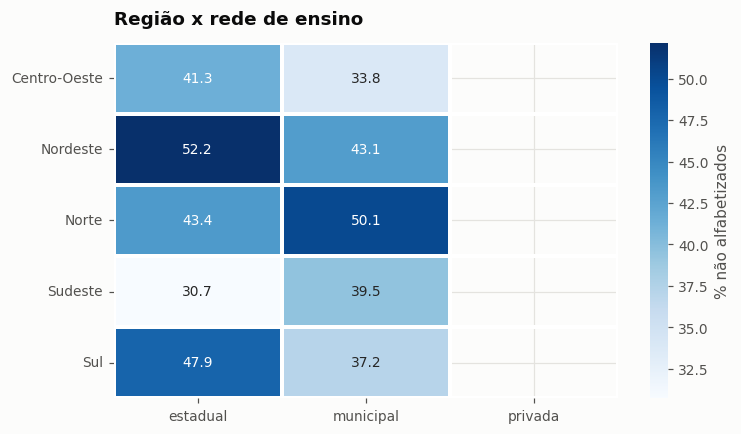

rede          estadual  municipal  privada
regiao                                    
Centro-Oeste     41.30      33.84      NaN
Nordeste         52.18      43.08      NaN
Norte            43.35      50.13      NaN
Sudeste          30.72      39.49      NaN
Sul              47.88      37.17      NaN

amplitude entre redes, dentro de cada região:
regiao
Centro-Oeste     7.46
Nordeste         9.10
Norte            6.78
Sudeste          8.77
Sul             10.71


In [28]:
# Cruzamento região x rede
cruzamento = (df.pivot_table(index="regiao", columns="rede", values=ALVO,
                             aggfunc="mean", observed=True) * 100)
contagem = df.pivot_table(index="regiao", columns="rede", values=ALVO,
                          aggfunc="size", observed=True)
cruzamento = cruzamento.mask(contagem < 300)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
sns.heatmap(cruzamento, annot=True, fmt=".1f", cmap=SEQUENCIAL, ax=ax,
            cbar_kws={"label": "% não alfabetizados"}, linewidths=1.5,
            linecolor="white", annot_kws={"fontsize": 9})
ax.set_title("Região x rede de ensino")
ax.set_xlabel(""); ax.set_ylabel("")
salva(fig, "crispdm_multivariada.png"); plt.show()

print(cruzamento.round(2).to_string())
print("\namplitude entre redes, dentro de cada região:")
print((cruzamento.max(axis=1) - cruzamento.min(axis=1)).round(2).to_string())

O efeito da rede **não é constante entre regiões**: a diferença entre a melhor e a pior rede
varia de região para região, e em algumas delas a ordem se inverte. Um modelo aditivo, como
a regressão logística, só captura isso se a interação for escrita à mão. Modelos de árvore a
descobrem sozinhos — é uma das razões para esperar que o boosting vença a comparação da
Fase 03.

## 7 - **EXPLORANDO AS CORRELAÇÕES**

Correlação próxima de **+1**: as duas variáveis sobem juntas. Próxima de **−1**: uma sobe
enquanto a outra desce. Próxima de **0**: não há relação linear — o que não significa que não
haja relação alguma.

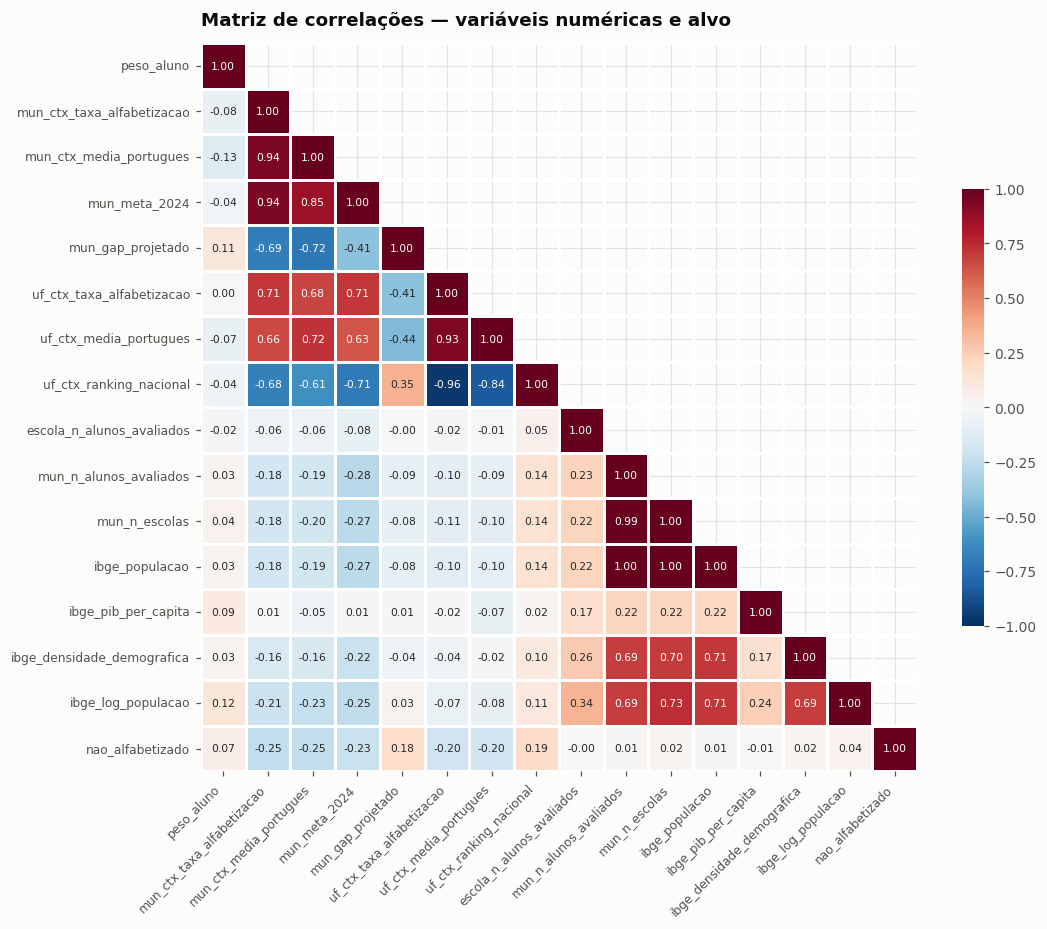

In [29]:
# Matriz de correlações entre todas as numéricas
numericas_modelo = [c for c in NUM_FEATURES if c in df.columns]
matriz = df[numericas_modelo + [ALVO]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10.5, 8.6))
mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
sns.heatmap(matriz, mask=mascara, cmap=DIVERGENTE, center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"fontsize": 7}, ax=ax,
            linewidths=0.8, linecolor="white", cbar_kws={"shrink": 0.6})
ax.set_title("Matriz de correlações — variáveis numéricas e alvo")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
salva(fig, "crispdm_correlacoes.png"); plt.show()

**Nota:**

- **Como ler um mapa de correlações:** cada quadrado cruza duas variáveis. Azul forte é
  correlação positiva, vermelho forte é negativa, e o tom claro no meio é ausência de relação.
  A diagonal é sempre 1, porque toda variável se correlaciona perfeitamente consigo mesma.
- Os blocos escuros fora da diagonal são grupos de variáveis que dizem quase a mesma coisa —
  população e densidade demográfica, taxa e média de português do município.
- **Redundância entre features não é problema aqui.** Modelos de árvore lidam bem com ela; o
  que ela afeta é a leitura dos coeficientes do modelo linear, não a previsão.

                            correlacao_com_alvo                    direcao
mun_ctx_media_portugues                 -0.2479  mais valor -> menos risco
mun_ctx_taxa_alfabetizacao              -0.2473  mais valor -> menos risco
mun_meta_2024                           -0.2261  mais valor -> menos risco
uf_ctx_media_portugues                  -0.2012  mais valor -> menos risco
uf_ctx_taxa_alfabetizacao               -0.1997  mais valor -> menos risco
uf_ctx_ranking_nacional                  0.1917   mais valor -> mais risco
mun_gap_projetado                        0.1824   mais valor -> mais risco
peso_aluno                               0.0665   mais valor -> mais risco
ibge_log_populacao                       0.0444   mais valor -> mais risco
ibge_densidade_demografica               0.0218   mais valor -> mais risco
mun_n_escolas                            0.0179   mais valor -> mais risco
mun_n_alunos_avaliados                   0.0144   mais valor -> mais risco
ibge_populacao           

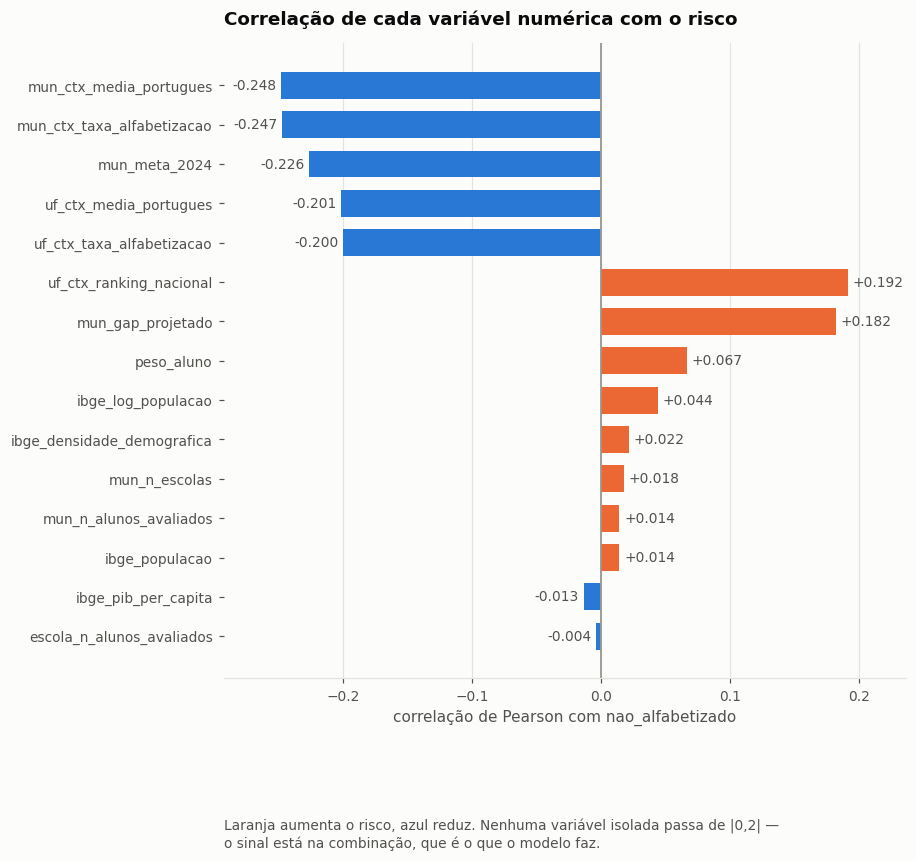

In [30]:
# Criando um rank das correlações com o alvo
rank = (matriz[ALVO].drop(ALVO).sort_values(key=np.abs, ascending=False)
        .to_frame("correlacao_com_alvo").round(4))
rank["direcao"] = np.where(rank["correlacao_com_alvo"] > 0,
                           "mais valor -> mais risco", "mais valor -> menos risco")
print(rank.to_string())

fig, ax = plt.subplots(figsize=(8, 0.42 * len(rank) + 1.2))
valores = rank["correlacao_com_alvo"].tolist()
barras_horizontais(ax, rank.index.tolist(), valores, formato="{:+.3f}",
                   destaque={i: LARANJA for i, v in zip(rank.index, valores) if v > 0})
ax.set_title("Correlação de cada variável numérica com o risco")
ax.set_xlabel("correlação de Pearson com nao_alfabetizado")
anota(ax, "Laranja aumenta o risco, azul reduz. Nenhuma variável isolada passa de |0,2| —\n"
          "o sinal está na combinação, que é o que o modelo faz.")
salva(fig, "crispdm_rank_correlacoes.png"); plt.show()

**Nota:**

- **Nenhuma variável isolada passa de 0,25 de correlação com o alvo.** Não há uma bala de
  prata: o sinal está espalhado, e é por isso que a soma de muitas variáveis fracas rende mais
  que qualquer uma delas sozinha.
- O sinal negativo das cinco primeiras é o esperado — quanto melhor o contexto de 2023, menor
  o risco em 2024. `uf_ctx_ranking_nacional` aparece positiva porque ranking alto significa
  posição pior.
- Compare com o que virá na FASE 03: `id_escola`, que nem aparece nesta tabela por ser
  categórica, será a variável mais importante do modelo. **Correlação linear não captura tudo.**

id_municipio    0.2861
id_escola       0.2758
sigla_uf        0.2339
regiao          0.0809
rede            0.0242
caderno         0.0083


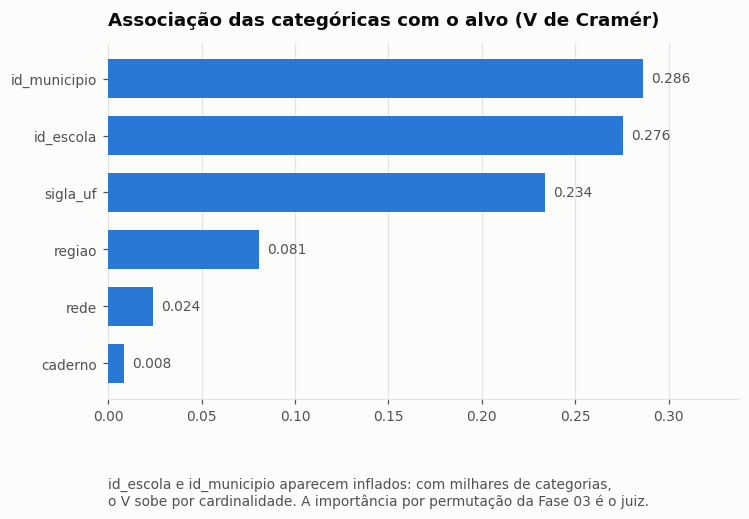

In [31]:
# Associação entre categóricas e o alvo — V de Cramér, apropriado para nominais
# 'serie' é constante nesta base (só o 2º ano é avaliado), então o V é indefinido:
# a coluna sai do gráfico em vez de virar uma barra vazia
categoricas_v = {}
for coluna in CAT_BAIXA + CAT_ALTA:
    if coluna in df.columns and df[coluna].nunique() > 1:
        if df[coluna].nunique() > 1000:      # alta cardinalidade: amostra para o teste
            amostra = df[[coluna, ALVO]].sample(60_000, random_state=SEED)
            categoricas_v[coluna] = cramers_v(amostra[coluna], amostra[ALVO])
        else:
            categoricas_v[coluna] = cramers_v(df[coluna], df[ALVO])

serie_v = pd.Series(categoricas_v).sort_values(ascending=False)
print(serie_v.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.4, 0.5 * len(serie_v) + 1.2))
barras_horizontais(ax, serie_v.index.tolist(), serie_v.tolist(), formato="{:.3f}")
ax.set_title("Associação das categóricas com o alvo (V de Cramér)")
anota(ax, "id_escola e id_municipio aparecem inflados: com milhares de categorias,\n"
          "o V sobe por cardinalidade. A importância por permutação da Fase 03 é o juiz.")
salva(fig, "crispdm_cramers_v.png"); plt.show()

**Nota:**

- Os identificadores territoriais dominam: `id_municipio` (**0,286**) e `id_escola` (**0,276**)
  ficam acima de `sigla_uf` (**0,234**).
- No outro extremo, `rede` marca 0,024 e `caderno` 0,008 — **dez a trinta vezes menos**. O
  caderno de prova é sorteado, então o valor próximo de zero é a confirmação de que o sorteio
  funcionou.
- `serie` não aparece porque é constante nesta base, e o V de Cramér de uma coluna constante é
  indefinido. Ela sai do gráfico em vez de virar uma barra vazia.

### O vazamento sutil: colunas estáticas

Filtrar `ano = 2023` não basta. Algumas colunas da Silver foram agregadas **sem o ano** pela
Fase 2 — são estáticas por município, e por isso carregam informação do ano-alvo mesmo
aparecendo no bloco de contexto.

O critério para detectá-las: uma feature estática só é aceitável se sua relação com o futuro
for **mediada pelo passado**, isto é, `corr(X, taxa_2024) <= corr(X, taxa_2023)`. A régua é a
persistência da própria taxa: `corr(taxa_2023, taxa_2024)`, calculada na hipótese H2.

A célula abaixo refaz o diagnóstico que produziu a lista `COLUNAS_VETADAS_DIAGNOSTICO`.

In [32]:
# Diagnóstico: a coluna estática correlaciona mais com 2024 ou com 2023?
estaticas = [c for c in COLUNAS_VETADAS_DIAGNOSTICO if c in df.columns]
painel = (df.groupby("id_municipio", observed=True)
            .agg(**{c: (c, "first") for c in estaticas},
                 taxa_2023=("mun_ctx_taxa_alfabetizacao", "first"),
                 alunos=(ALVO, "size"), nao_alfab=(ALVO, "mean"))
            .query("alunos >= 30").dropna(subset=["taxa_2023"]))
painel["taxa_2024"] = 100 * (1 - painel["nao_alfab"])

linhas = []
for coluna in estaticas:
    valores = painel[[coluna, "taxa_2023", "taxa_2024"]].dropna()
    if valores[coluna].nunique() <= 1:
        linhas.append({"coluna": coluna, "corr_2023": np.nan, "corr_2024": np.nan,
                       "veredito": "variância zero — constante em toda a base"})
        continue
    c23 = abs(valores[coluna].corr(valores["taxa_2023"]))
    c24 = abs(valores[coluna].corr(valores["taxa_2024"]))
    linhas.append({"coluna": coluna, "corr_2023": round(c23, 3), "corr_2024": round(c24, 3),
                   "veredito": "antecipa o alvo" if c24 > c23 else "mediada pelo passado"})

diagnostico = pd.DataFrame(linhas)
print(f"régua de referência — corr(taxa_2023, taxa_2024) = "
      f"{abs(painel['taxa_2023'].corr(painel['taxa_2024'])):.3f}\n")
print(diagnostico.to_string(index=False))

régua de referência — corr(taxa_2023, taxa_2024) = 0.752

                         coluna  corr_2023  corr_2024                                  veredito
    mun_ctx_nivel_alfabetizacao      0.897      0.880                      mediada pelo passado
mun_ctx_percentual_participacao      0.348      0.434                           antecipa o alvo
                  mun_meta_2030        NaN        NaN variância zero — constante em toda a base
                   uf_meta_2030        NaN        NaN variância zero — constante em toda a base
    mun_esforco_anual_requerido      1.000      0.753                      mediada pelo passado


**Nota:**

- **Esta é a peça mais delicada do notebook.** Filtrar o ano não basta quando a coluna foi
  agregada sem o ano: ela pode carregar informação do futuro mesmo parecendo defasada.
- O critério é comparativo. A régua é a persistência da própria taxa, **0,752**. Uma coluna
  estática só é aceitável se sua relação com 2024 for **mediada pelo passado**, isto é, se ela
  se correlacionar com 2024 no máximo tanto quanto com 2023.
- `mun_ctx_percentual_participacao` reprova: correlaciona **0,434 com 2024 e só 0,348 com
  2023**. A participação registrada é a da coleta de 2024, então antecipa o alvo. Sai.
- Duas colunas aparecem com correlação indefinida porque são constantes em toda a base.
  Também saem, por outro motivo: não há variância para aprender.

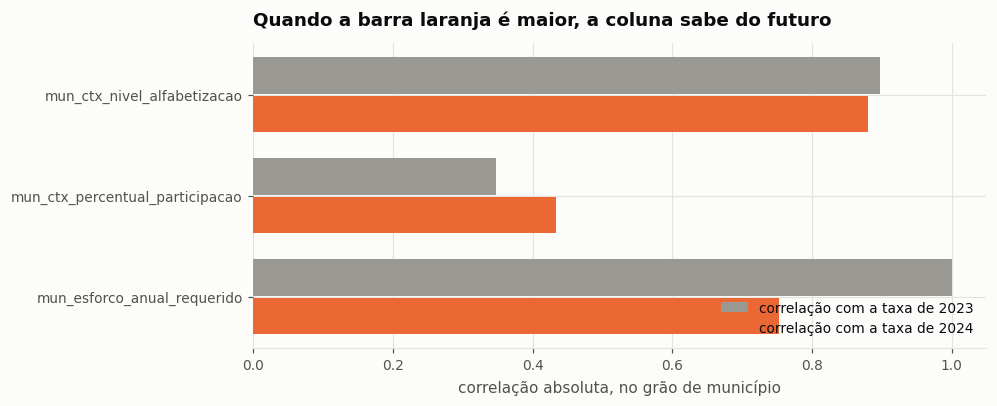

8517

In [33]:
# Visualizando o diagnóstico
comparaveis = diagnostico.dropna(subset=["corr_2023", "corr_2024"])
fig, ax = plt.subplots(figsize=(8.6, 3.6))
y = np.arange(len(comparaveis))
ax.barh(y - 0.19, comparaveis["corr_2023"], height=0.36, color=NEUTRO,
        label="correlação com a taxa de 2023")
ax.barh(y + 0.19, comparaveis["corr_2024"], height=0.36, color=LARANJA,
        label="correlação com a taxa de 2024")
ax.set_yticks(y, comparaveis["coluna"])
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.set_xlabel("correlação absoluta, no grão de município")
ax.set_title("Quando a barra laranja é maior, a coluna sabe do futuro")
limpa_eixos(ax); ax.grid(axis="x")
salva(fig, "crispdm_diagnostico_vazamento.png"); plt.show()

del painel, diagnostico, comparaveis
gc.collect()

**Nota:**

- **Como ler:** cada coluna candidata tem duas barras, a correlação com 2023 e com 2024. A
  linha de referência é a persistência da taxa, 0,752.
- Barra de 2024 mais alta que a de 2023 é o sinal de alarme: significa que a coluna sabe algo
  sobre o ano-alvo que o passado não explica.
- Só uma coluna tem esse padrão, e é a que foi vetada. **O veto está registrado em
  `src/config.py` com a justificativa**, para que a decisão não se perca.

### O que a EDA já decide

1. **O território é o sinal mais forte.** `sigla_uf` e o histórico municipal de 2023 lideram
   qualquer ranking de associação.
2. **A defasagem funciona.** O passado explica cerca de 38% da variação do presente no grão
   municipal — suficiente para prever sem tocar no ano-alvo.
3. **A escola acrescenta.** Metade da variação entre escolas não é do município.
4. **O socioeconômico contribui pouco.** Entra, mas não deve pesar.
5. **Cinco colunas saem por vazamento**, além das que são o alvo por definição.
6. **Nenhuma variável isolada é forte.** A maior correlação com o alvo não chega a |0,2|. Um
   modelo que combine dezenas de sinais fracos é o caminho — e é exatamente o que o boosting
   faz.

# **FASE 03: MODELAGEM DOS DADOS**

## 1 - **Leitura dos dados**

A EDA rodou sobre 300 mil alunos, que bastam para as distribuições. A modelagem passa a
usar o **recorte canônico do projeto**: as mesmas 600 mil linhas que
`src/models/train_aluno.py` carrega, com o mesmo `train_test_split` e a mesma semente.

Não é preciosismo. O notebook 02 recarrega `models/pipeline_aluno.joblib` e roda um `assert`
que exige reproduzir o PR-AUC registrado em `reports/metricas_aluno.json` com tolerância de
1e-9. Se o modelo publicado por este notebook viesse de outro recorte, aquele teste
quebraria — e com razão, porque artefato e métrica estariam descrevendo coisas diferentes.

A memória do WSL é de cerca de 2 GB, então o DataFrame da EDA é liberado antes da recarga.

In [34]:
# Liberando a memória da EDA antes de carregar o recorte canônico
for objeto in ["df", "com_ctx", "escola", "municipio", "matriz", "cruzamento", "contagem"]:
    if objeto in globals():
        del globals()[objeto]
gc.collect()

# Leitura dos dados — mesmo recorte de src/models/train_aluno.py
print(f"N_CARGA (linhas do recorte canônico): {N_CARGA:,}")
t0 = time.time()
df = carrega_base(n_linhas=N_CARGA, com_proficiencia=True)
grupos = df["id_municipio"].to_numpy()
X, y = matriz_xy(df)
print(f"\ncarregado em {time.time() - t0:.0f}s")
print(f"X: {X.shape[0]:,} linhas x {X.shape[1]} colunas | prevalência do alvo: {y.mean():.4f}")

N_CARGA (linhas do recorte canônico): 600,000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

18:43:22 | INFO    | base carregada: 600,000 linhas | 40.17% da classe positiva (nao alfabetizado)



carregado em 22s
X: 600,000 linhas x 22 colunas | prevalência do alvo: 0.4017


## 2 - **Valores nulos**

A imputação **não acontece aqui**. Ela vive dentro do `Pipeline`, depois do split, e essa é
uma decisão de projeto, não de estilo.

Calcular a mediana sobre a base inteira antes de separar treino e teste vaza uma estatística
do conjunto de teste para o treinamento. O efeito é pequeno em bases grandes, mas é
sistemático e infla a métrica reportada. Dentro do `Pipeline`, o `SimpleImputer` é ajustado
**apenas** com as linhas de treino de cada fold — inclusive dentro da validação cruzada, onde
o erro seria repetido cinco vezes.

O `add_indicator=True` acrescenta uma coluna binária por variável com ausência. A falta de
contexto de 2023 não é ruído: marca município que entrou no programa só em 2024.

In [35]:
# Verificando valores nulos na matriz de features
nulos_X = pd.DataFrame({
    "nulos": X.isna().sum(),
    "pct": (100 * X.isna().mean()).round(2),
})
nulos_X = nulos_X[nulos_X["nulos"] > 0].sort_values("pct", ascending=False)
print(nulos_X.to_string() if len(nulos_X) else "nenhuma feature com valor ausente")
print(f"\nlinhas sem nenhum ausente: {(~X.isna().any(axis=1)).sum():,} de {len(X):,}")
print("\nA imputação por mediana + indicador de ausência acontece dentro do Pipeline,")
print("ajustada só com as linhas de treino de cada fold.")

                            nulos   pct
mun_gap_projetado           28014  4.67
mun_meta_2024               28014  4.67
mun_ctx_media_portugues     11184  1.86
mun_ctx_taxa_alfabetizacao  11184  1.86
uf_ctx_taxa_alfabetizacao   10519  1.75
uf_ctx_media_portugues      10519  1.75
uf_ctx_ranking_nacional     10519  1.75
ibge_densidade_demografica    218  0.04

linhas sem nenhum ausente: 571,768 de 600,000

A imputação por mediana + indicador de ausência acontece dentro do Pipeline,
ajustada só com as linhas de treino de cada fold.


**Nota:**

- **571.768 das 600 mil linhas não têm nenhum valor ausente.** As que têm concentram a falta
  nas colunas de meta municipal, ausentes em 4,7% dos casos.
- O ponto que a célula deixa explícito importa mais que os números: **a imputação acontece
  dentro do Pipeline**, ajustada só com as linhas de treino de cada dobra.
- Se a mediana fosse calculada sobre a base inteira antes do split, o conjunto de teste teria
  contaminado o treino. É uma forma discreta de vazamento, e o Pipeline existe para evitá-la.

## 3 - **Transformação**

Três naturezas de variável, três tratamentos, todos dentro do mesmo `ColumnTransformer`
montado por `src/features/build_features.py`.

**Numéricas** → mediana com indicador de ausência. A padronização (`StandardScaler`) é
acrescentada **só** para a regressão logística, que é sensível à escala. Árvores são
invariantes a transformações monótonas, então escalar ali só custaria tempo.

**Categóricas curtas** (`rede`, `serie`, `caderno`, `regiao`, `sigla_uf`) → moda +
`OneHotEncoder` com `handle_unknown="ignore"` e `min_frequency=20`. Categorias raríssimas
caem num balde comum em vez de virarem colunas quase vazias.

**Alta cardinalidade** (`id_municipio` com 5,5 mil valores, `id_escola` com 42 mil) →
`TargetEncoder`. O one-hot aqui produziria dezenas de milhares de colunas. O detalhe que
torna o encoder seguro é o **cross-fitting interno** do scikit-learn: no `fit`, cada linha
recebe a codificação estimada em folds que não a contêm. Sem isso, uma escola com cinco
alunos receberia praticamente a média do próprio alvo — o vazamento clássico do target
encoding ingênuo.

In [36]:
# Inspecionando o pré-processador antes de acoplá-lo a qualquer modelo
prep_demo = constroi_preprocessador()
for nome, transformador, colunas in prep_demo.transformers:
    print(f"{nome:<12} -> {len(colunas):>2} coluna(s): {', '.join(colunas[:6])}"
          f"{' ...' if len(colunas) > 6 else ''}")
    for passo, obj in transformador.steps:
        print(f"{'':<15} {passo}: {type(obj).__name__}")

# Quantas colunas saem do outro lado
prep_demo.fit(X.head(20_000), y[:20_000])
nomes_saida = prep_demo.get_feature_names_out()
print(f"\ncolunas na saída do ColumnTransformer: {len(nomes_saida)}")
print(f"exemplo: {', '.join(nomes_saida[:4])} ... {', '.join(nomes_saida[-3:])}")
del prep_demo, nomes_saida
gc.collect()

num          -> 15 coluna(s): peso_aluno, mun_ctx_taxa_alfabetizacao, mun_ctx_media_portugues, mun_meta_2024, mun_gap_projetado, uf_ctx_taxa_alfabetizacao ...
                imputacao: SimpleImputer
cat          ->  5 coluna(s): rede, serie, caderno, regiao, sigla_uf
                imputacao: SimpleImputer
                onehot: OneHotEncoder
alta_card    ->  2 coluna(s): id_municipio, id_escola
                encoder: TargetEncoder



colunas na saída do ColumnTransformer: 80
exemplo: num__peso_aluno, num__mun_ctx_taxa_alfabetizacao, num__mun_ctx_media_portugues, num__mun_meta_2024 ... cat__sigla_uf_TO, alta_card__id_municipio, alta_card__id_escola


22

**Nota:**

- **As 22 features entram e 80 colunas saem.** A diferença vem do `OneHotEncoder`, que
  transforma cada valor de uma categórica curta numa coluna própria — 26 estados viram 26
  colunas.
- Os dois identificadores de alta cardinalidade seguem outro caminho. Um `OneHotEncoder` em
  `id_escola` criaria 42 mil colunas; o `TargetEncoder` substitui cada escola por um número só,
  ajustado com validação cruzada interna para que a codificação nunca venha do próprio alvo.
- **Inspecionar antes de acoplar é deliberado.** Um pré-processador só é auditável enquanto
  está separado do modelo.

## 4 - **Pré-Processamento**

### Separação do conjunto de dados

Dois regimes de holdout, porque respondem a perguntas diferentes e ambas interessam ao
gestor.

**Holdout aleatório** — alunos sorteados, estratificado pelo alvo. Mede: *prever alunos
novos numa rede que já conheço*. É o cenário de uso mais comum, já que a maior parte dos
municípios tem histórico.

**Holdout agrupado por município** — municípios inteiros ficam fora do treino
(`StratifiedGroupKFold`). Mede: *prever num município sem histórico*, onde os encodings
territoriais não ajudam. A diferença entre os dois é a medida honesta de quanto o modelo
depende do histórico local.

In [37]:
# Separando os dados para treinamento e teste — split canônico, idêntico ao train_aluno.py
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=SEED)
X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]

print(f"treino ... {len(X_tr):>8,} linhas | prevalência {y_tr.mean():.4f}")
print(f"teste .... {len(X_te):>8,} linhas | prevalência {y_te.mean():.4f}")
print(f"municípios distintos no treino: {pd.Series(grupos[idx_tr]).nunique():,}")

# Subamostras de trabalho: a comparação e a busca não precisam das 480 mil linhas
rng = np.random.default_rng(SEED)
sub_comparacao = rng.choice(len(X_tr), size=min(200_000, len(X_tr)), replace=False)
sub_busca = rng.choice(len(X_tr), size=min(100_000, len(X_tr)), replace=False)
X_cmp, y_cmp = X_tr.iloc[sub_comparacao], y_tr[sub_comparacao]
X_bus, y_bus = X_tr.iloc[sub_busca], y_tr[sub_busca]
print(f"\nsubamostra para comparar famílias: {len(X_cmp):,}")
print(f"subamostra para buscar hiperparâmetros: {len(X_bus):,}")
print("O campeão é reajustado nas 480 mil linhas completas antes de ir para produção.")

treino ...  480,000 linhas | prevalência 0.4017
teste ....  120,000 linhas | prevalência 0.4017
municípios distintos no treino: 5,513



subamostra para comparar famílias: 200,000
subamostra para buscar hiperparâmetros: 100,000
O campeão é reajustado nas 480 mil linhas completas antes de ir para produção.


**Nota:**

- **480 mil linhas para treinar, 120 mil para testar**, com a prevalência idêntica nos dois
  lados (0,4017) porque o split é estratificado pelo alvo.
- O split é **o mesmo** de `src/models/train_aluno.py`, com a mesma semente. É isso que permite
  ao notebook 02 recarregar o artefato num processo novo e conferir que a métrica bate.
- As duas subamostras existem por restrição de máquina: comparar famílias e buscar
  hiperparâmetros em 200 mil e 100 mil linhas. **O campeão é reajustado nas 480 mil completas**
  antes de ir para produção.

### Balancear os dados

**SMOTE foi descartado.** A geração de vizinhos sintéticos num espaço que é majoritariamente
categórico codificado produz linhas que não correspondem a nenhuma criança possível — uma
escola "meio A, meio B". Pior: em testes com esta base, a reamostragem sintética levava a
sobreajuste severo, com a métrica de treino descolando da de teste sem ganho real de recall.

**A estratégia adotada é `class_weight="balanced"`** em todos os candidatos. O mecanismo
ajusta o peso de cada classe na função de perda, sem inventar amostras: a classe positiva
passa a valer, para efeito de perda, o inverso da sua frequência. Preserva a distribuição
real e mantém as probabilidades interpretáveis.

Como todos os três candidatos usam a mesma política, a comparação mede **família de modelo**,
não política de desbalanceamento.

In [38]:
# Verificar distribuição da variável alvo no treino
dist_tr = pd.Series(y_tr).value_counts().sort_index()
peso_positivo = (1 - y_tr.mean()) / y_tr.mean()
print(f"alfabetizado (0) ....... {dist_tr[0]:>8,}")
print(f"NÃO alfabetizado (1) ... {dist_tr[1]:>8,}")
print(f"\nclass_weight='balanced' dá à classe positiva um peso de "
      f"{1 / (2 * y_tr.mean()):.3f} contra {1 / (2 * (1 - y_tr.mean())):.3f} da negativa")
print(f"razão efetiva entre os pesos: {peso_positivo:.3f}")

alfabetizado (0) .......  287,195
NÃO alfabetizado (1) ...  192,805

class_weight='balanced' dá à classe positiva um peso de 1.245 contra 0.836 da negativa
razão efetiva entre os pesos: 1.490


**Nota:**

- **SMOTE e reamostragem foram descartados de propósito.** Criar crianças sintéticas numa base
  cujo sinal é territorial produziria alunos que não existem em municípios que existem.
- A alternativa usada é `class_weight="balanced"`: o modelo continua vendo os dados reais, mas
  errar na classe minoritária custa **1,49 vez mais**.
- **Guarde este número.** É ele que, na FASE 04, vai explicar por que o modelo superestima o
  risco em todas as UFs.

### Seleção de Variáveis

O contrato de `src/config.py` já fixa quais colunas entram. Esta seção não corta features —
ela **mede** quanto cada uma carrega, por informação mútua sobre a matriz já transformada.

A informação mútua captura dependências não lineares, ao contrário da correlação de Pearson
da Fase 02. Como é cara, roda sobre uma subamostra de 30 mil linhas.

In [39]:
# Função de seleção de features por informação mútua
prep_mi = constroi_preprocessador()
sub_mi = rng.choice(len(X_tr), size=30_000, replace=False)
X_mi = prep_mi.fit_transform(X_tr.iloc[sub_mi], y_tr[sub_mi])
nomes_mi = prep_mi.get_feature_names_out()

t0 = time.time()
mi = mutual_info_classif(X_mi, y_tr[sub_mi], random_state=SEED, n_neighbors=3)
print(f"informação mútua calculada em {time.time() - t0:.0f}s sobre {X_mi.shape[0]:,} "
      f"linhas e {X_mi.shape[1]} colunas transformadas")

ranking_mi = (pd.DataFrame({"feature": nomes_mi, "info_mutua": mi})
                .sort_values("info_mutua", ascending=False)
                .reset_index(drop=True))
ranking_mi.head(20)

informação mútua calculada em 22s sobre 30,000 linhas e 80 colunas transformadas


,feature,info_mutua
0,num__mun_ctx_media_portugues,0.051553
1,num__mun_ctx_taxa_alfabetizacao,0.046760
2,num__ibge_log_populacao,0.046011
3,num__ibge_pib_per_capita,0.045570
4,num__ibge_populacao,0.043037
5,num__mun_meta_2024,0.042793
6,num__ibge_densidade_demografica,0.040666
7,num__mun_gap_projetado,0.039250
8,num__uf_ctx_taxa_alfabetizacao,0.027923
9,num__uf_ctx_ranking_nacional,0.027104


**Nota:**

- **A informação mútua captura relações que a correlação linear não vê**, inclusive as que
  sobem e descem. Por isso ela vem depois da matriz de correlações, não no lugar dela.
- Os valores são baixos em termos absolutos — o topo fica em 0,05. Confirma o diagnóstico da
  exploração: **não há variável dominante, há muitas variáveis fracas**.
- O contexto municipal ocupa as primeiras posições. As colunas de estado, uma a uma depois do
  `OneHotEncoder`, aparecem bem abaixo, porque cada uma sozinha diz pouco.
- **Nenhuma feature foi cortada com base nesta tabela.** Ela serve de diagnóstico; a decisão de
  o que entra está no contrato de colunas de `src/config.py`.

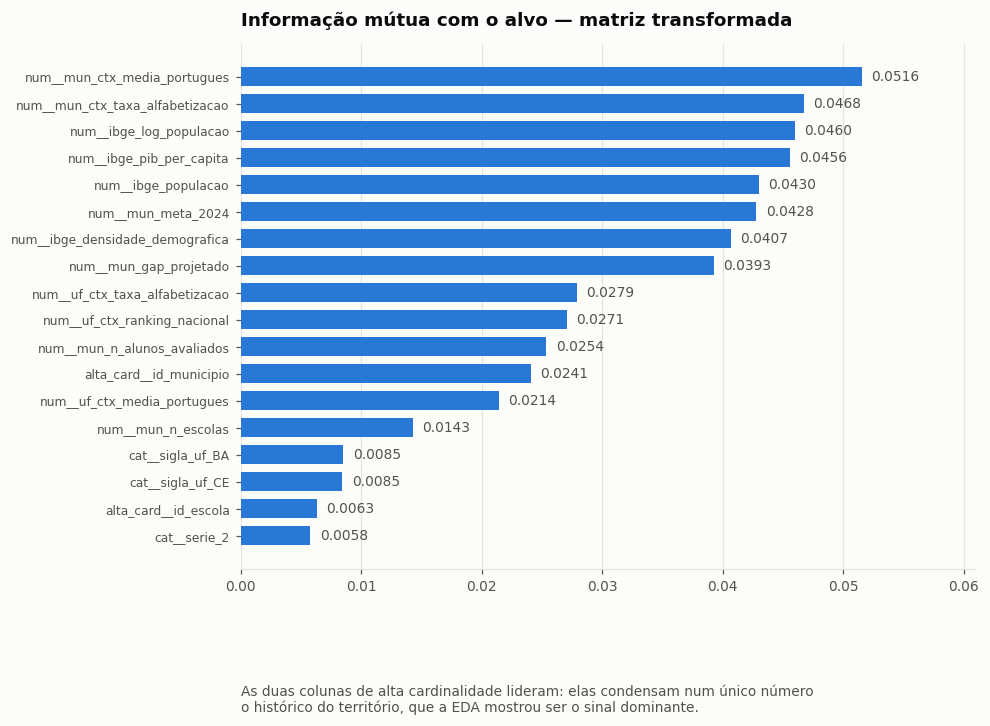

2990

In [40]:
# Visualização do ranking de features por informação mútua
topo = ranking_mi.head(18).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.6, 6.2))
barras_horizontais(ax, topo["feature"].tolist(), topo["info_mutua"].tolist(),
                   formato="{:.4f}")
ax.invert_yaxis()
ax.set_title("Informação mútua com o alvo — matriz transformada")
ax.tick_params(axis="y", labelsize=8)
anota(ax, "As duas colunas de alta cardinalidade lideram: elas condensam num único número\n"
          "o histórico do território, que a EDA mostrou ser o sinal dominante.")
salva(fig, "crispdm_info_mutua.png"); plt.show()

del prep_mi, X_mi, mi
gc.collect()

**Nota:**

- **Como ler:** barra mais longa significa que a coluna carrega mais informação sobre o alvo,
  sozinha. A escala é absoluta, não percentual.
- A queda é suave, sem degrau. Num problema com variável dominante haveria uma barra muito
  maior que as outras — aqui não há.

## 5 - **Treinamento dos Algoritmos de Machine Learning**

Três famílias competem, uma por paradigma:

| Algoritmo | Família | Por que está aqui |
|---|---|---|
| **Regressão Logística** | linear | teto do que se consegue sem interações; coeficientes legíveis |
| **Random Forest** | bagging | captura interações, resistente a sobreajuste por média de árvores |
| **LightGBM** | boosting | estado da arte em tabular; aprende resíduo do resíduo |

Um **baseline trivial** (`DummyClassifier`) entra como piso: ele prevê sempre a prevalência,
e seu PR-AUC é exatamente a proporção da classe positiva. Nenhum modelo que não o supere
merece existir.

Todos compartilham o mesmo `class_weight="balanced"` e o mesmo pré-processador, então a
comparação isola a família.

In [41]:
# Construtor dos modelos — uma fábrica, para reinstanciar sem estado herdado
def constroi_modelo(nome, params=None, n_jobs=1):
    params = {k.replace("clf__", ""): v for k, v in (params or {}).items()}
    if nome == "baseline_maioria":
        clf = DummyClassifier(strategy="prior")
        return Pipeline([("prep", constroi_preprocessador()), ("clf", clf)])
    if nome == "regressao_logistica":
        clf = LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=SEED, n_jobs=1, **params)
        return Pipeline([("prep", constroi_preprocessador(escalar=True)), ("clf", clf)])
    if nome == "random_forest":
        padroes = dict(n_estimators=200, max_depth=14, min_samples_leaf=100,
                       max_features="sqrt", class_weight="balanced",
                       random_state=SEED, n_jobs=n_jobs)
        padroes.update(params)
        return Pipeline([("prep", constroi_preprocessador()),
                         ("clf", RandomForestClassifier(**padroes))])
    if nome == "lightgbm":
        padroes = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                       class_weight="balanced", random_state=SEED,
                       n_jobs=n_jobs, verbose=-1)
        padroes.update(params)
        return Pipeline([("prep", constroi_preprocessador()),
                         ("clf", LGBMClassifier(**padroes))])
    raise ValueError(f"modelo desconhecido: {nome}")


CANDIDATOS = ["baseline_maioria", "regressao_logistica", "random_forest", "lightgbm"]
for nome in CANDIDATOS:
    print(f"{nome:<22} {type(constroi_modelo(nome).named_steps['clf']).__name__}")

baseline_maioria       DummyClassifier
regressao_logistica    LogisticRegression
random_forest          RandomForestClassifier
lightgbm               LGBMClassifier


### Comparação por validação cruzada

Antes de olhar o holdout, uma triagem por **validação cruzada estratificada de 3 folds** na
subamostra de 100 mil linhas, com PR-AUC como métrica. A CV é o critério de seleção porque
ela usa só dados de treino — decidir a família olhando o holdout já seria usá-lo para
escolher, e a métrica final deixaria de ser honesta.

In [42]:
# Comparação de famílias por validação cruzada (3 folds, métrica PR-AUC)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
linhas_cv = []
for nome in CANDIDATOS:
    t0 = time.time()
    scores = cross_val_score(constroi_modelo(nome, n_jobs=1), X_bus, y_bus,
                             scoring="average_precision", cv=cv, n_jobs=N_JOBS)
    segundos = time.time() - t0
    linhas_cv.append({"modelo": nome, "pr_auc_medio": scores.mean(),
                      "desvio": scores.std(), "segundos": segundos})
    print(f"{nome:<22} PR-AUC={scores.mean():.4f} (+/-{scores.std():.4f})  {segundos:>5.0f}s")

comparacao_cv = pd.DataFrame(linhas_cv).sort_values("pr_auc_medio", ascending=False)
vencedor_cv = comparacao_cv.iloc[0]["modelo"]
print(f"\nvencedor da validação cruzada: {vencedor_cv}")
comparacao_cv.round(4)

baseline_maioria       PR-AUC=0.4027 (+/-0.0000)     12s


/home/rafael/.venvs/fase3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/rafael/.venvs/fase3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


/home/rafael/.venvs/fase3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


regressao_logistica    PR-AUC=0.5607 (+/-0.0023)      8s


random_forest          PR-AUC=0.5610 (+/-0.0032)    105s


lightgbm               PR-AUC=0.5497 (+/-0.0040)     29s

vencedor da validação cruzada: random_forest


,modelo,pr_auc_medio,desvio,segundos
2,random_forest,0.5610,0.0032,104.5800
1,regressao_logistica,0.5607,0.0023,7.5654
3,lightgbm,0.5497,0.0040,28.6502
0,baseline_maioria,0.4027,0.0000,11.9316


**Nota:**

- **Leia primeiro a última linha.** O baseline, que sempre responde a classe majoritária, marca
  PR-AUC de 0,4027 — o piso. Todo o resto é o ganho real sobre não fazer nada.
- Random Forest (**0,5610**) e regressão logística (**0,5607**) ficam a **três décimos de
  milésimo** um do outro, dentro do próprio desvio da validação cruzada. **Não há vencedor
  estatístico entre os dois.**
- Compare a coluna de tempo: a logística chega ao mesmo lugar em **8 segundos** contra **105**
  da floresta. Num problema em que a métrica empata, custo de manutenção vira critério.
- Os avisos amarelos do scikit-learn são sobre uma opção de solver ignorada. Não afetam o
  resultado.

### 5.1 — Regressão Logística

O modelo linear. Cada feature entra com um coeficiente fixo, e a probabilidade é uma função
logística da soma ponderada. Não captura interações a menos que sejam escritas à mão — e a
Fase 02 mostrou que existe pelo menos uma relevante, entre região e rede.

Serve de piso informado: se um modelo muito mais caro ganhar pouco dele, o ganho não
justifica a complexidade.

In [43]:
# Ajustando a regressão logística
t0 = time.time()
modelo_lr = constroi_modelo("regressao_logistica", n_jobs=1)
modelo_lr.fit(X_cmp, y_cmp)
print(f"ajustado em {time.time() - t0:.0f}s sobre {len(X_cmp):,} linhas")

ajustado em 11s sobre 200,000 linhas


#### DADOS DE TREINO

=== REGRESSÃO LOGÍSTICA — TREINO ===
  roc_auc    0.7506
  pr_auc     0.6686
  acuracia   0.6764
  precisao   0.5806
  recall     0.6966
  f1         0.6333
  brier      0.2068

                  precision    recall  f1-score   support

    alfabetizado     0.7653    0.6629    0.7104    119761
não alfabetizado     0.5806    0.6966    0.6333     80239

        accuracy                         0.6764    200000
       macro avg     0.6729    0.6797    0.6718    200000
    weighted avg     0.6912    0.6764    0.6795    200000



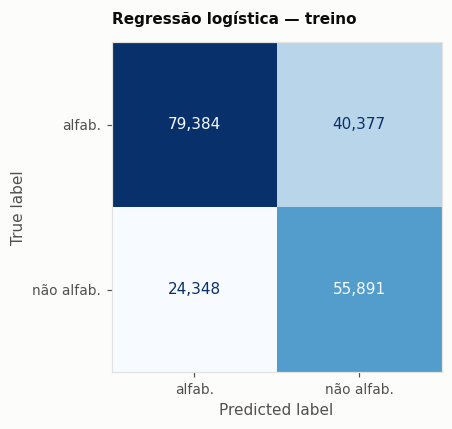

verdadeiros negativos ...   79,384  crianças que iriam bem e o modelo liberou
falsos positivos ........   40,377  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   24,348  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   55,891  em risco, corretamente encontradas


In [44]:
# Calcular métricas no conjunto de treinamento
def relatorio_completo(modelo, X_, y_, titulo, limiar=0.5):
    proba = modelo.predict_proba(X_)[:, 1]
    pred = (proba >= limiar).astype(int)
    metricas = {
        "roc_auc": roc_auc_score(y_, proba),
        "pr_auc": average_precision_score(y_, proba),
        "acuracia": (pred == y_).mean(),
        "precisao": precision_score(y_, pred, zero_division=0),
        "recall": recall_score(y_, pred),
        "f1": f1_score(y_, pred),
        "brier": brier_score_loss(y_, proba),
    }
    print(f"=== {titulo} ===")
    for chave, valor in metricas.items():
        print(f"  {chave:<10} {valor:.4f}")
    print("\n" + classification_report(
        y_, pred, target_names=["alfabetizado", "não alfabetizado"], digits=4))
    return metricas, proba, pred


def desenha_confusao(y_, pred, titulo, arquivo=None):
    matriz = confusion_matrix(y_, pred)
    vn, fp, fn, vp = matriz.ravel()
    fig, ax = plt.subplots(figsize=(4.6, 4))
    ConfusionMatrixDisplay(matriz, display_labels=["alfab.", "não alfab."]).plot(
        ax=ax, cmap=SEQUENCIAL, colorbar=False, values_format=",")
    ax.set_title(titulo, fontsize=10)
    ax.grid(False)
    plt.tight_layout()
    if arquivo:
        salva(fig, arquivo)
    plt.show()
    print(f"verdadeiros negativos ... {vn:>8,}  crianças que iriam bem e o modelo liberou")
    print(f"falsos positivos ........ {fp:>8,}  acompanhadas sem precisar (custo de vaga)")
    print(f"falsos negativos ........ {fn:>8,}  EM RISCO E NÃO DETECTADAS (custo alto)")
    print(f"verdadeiros positivos ... {vp:>8,}  em risco, corretamente encontradas")
    return matriz


m_lr_treino, _, pred_lr_treino = relatorio_completo(
    modelo_lr, X_cmp, y_cmp, "REGRESSÃO LOGÍSTICA — TREINO")
_ = desenha_confusao(y_cmp, pred_lr_treino, "Regressão logística — treino")

**Nota:**

- **Sete métricas, e nenhuma delas sozinha decide.** `recall` é a fração das crianças em risco
  encontradas; `precisao` é a fração das convocações que estava certa. Uma sobe às custas da
  outra.
- `brier` é o erro da probabilidade, e vale ao contrário: **quanto menor, melhor**. Serve para
  saber se o número pode ser lido como risco de verdade.
- A matriz de confusão vem com as quatro células nomeadas em português, e a que importa é
  `falsos negativos`: **crianças em risco que o modelo liberou**. É o erro caro.
- Na regressão logística de treino, são 24.348 crianças nessa situação — e é para reduzir esse
  número que o limiar será ajustado na seção 8.

#### DADOS DE TESTE

=== REGRESSÃO LOGÍSTICA — TESTE ===
  roc_auc    0.6828
  pr_auc     0.5713
  acuracia   0.6310
  precisao   0.5339
  recall     0.6395
  f1         0.5820
  brier      0.2246

                  precision    recall  f1-score   support

    alfabetizado     0.7210    0.6252    0.6697     71799
não alfabetizado     0.5339    0.6395    0.5820     48201

        accuracy                         0.6310    120000
       macro avg     0.6275    0.6324    0.6258    120000
    weighted avg     0.6458    0.6310    0.6345    120000



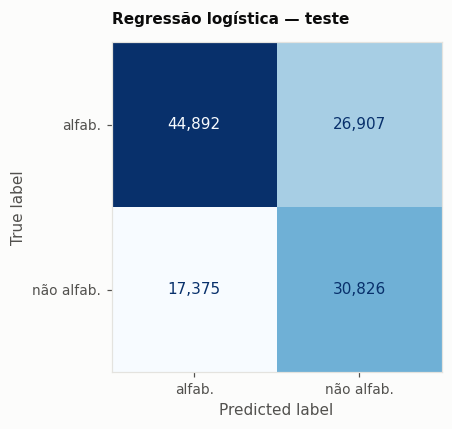

verdadeiros negativos ...   44,892  crianças que iriam bem e o modelo liberou
falsos positivos ........   26,907  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   17,375  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   30,826  em risco, corretamente encontradas

diferença treino - teste no PR-AUC: +0.0973


In [45]:
# Métricas no conjunto de teste (holdout canônico de 120 mil alunos)
m_lr_teste, proba_lr, pred_lr = relatorio_completo(
    modelo_lr, X_te, y_te, "REGRESSÃO LOGÍSTICA — TESTE")
_ = desenha_confusao(y_te, pred_lr, "Regressão logística — teste",
                     "crispdm_confusao_logistica.png")
print(f"\ndiferença treino - teste no PR-AUC: "
      f"{m_lr_treino['pr_auc'] - m_lr_teste['pr_auc']:+.4f}")

A distância entre treino e teste é mínima — o modelo linear **não sobreajusta**, ele
subajusta. É a assinatura de uma família com capacidade insuficiente para o problema.

### 5.2 — Random Forest

Bagging: centenas de árvores treinadas em amostras bootstrap com subconjuntos aleatórios de
features, e a previsão é a média. Captura interações sem que ninguém precise declará-las, e
o averaging controla a variância.

Os limites de profundidade (`max_depth=14`) e de folha mínima (`min_samples_leaf=100`) não
são só regularização: com 2 GB de RAM no WSL, uma floresta irrestrita sobre 200 mil linhas
não cabe na memória.

In [46]:
# Ajustando o Random Forest
t0 = time.time()
modelo_rf = constroi_modelo("random_forest", n_jobs=N_JOBS)
modelo_rf.fit(X_cmp, y_cmp)
print(f"ajustado em {time.time() - t0:.0f}s sobre {len(X_cmp):,} linhas")
print(f"árvores: {modelo_rf.named_steps['clf'].n_estimators} | "
      f"profundidade máxima: {modelo_rf.named_steps['clf'].max_depth}")

ajustado em 120s sobre 200,000 linhas
árvores: 200 | profundidade máxima: 14


#### DADOS DE TREINO

=== RANDOM FOREST — TREINO ===
  roc_auc    0.7407
  pr_auc     0.6473
  acuracia   0.6683
  precisao   0.5704
  recall     0.7014
  f1         0.6292
  brier      0.2099



                  precision    recall  f1-score   support

    alfabetizado     0.7636    0.6460    0.6999    119761
não alfabetizado     0.5704    0.7014    0.6292     80239

        accuracy                         0.6683    200000
       macro avg     0.6670    0.6737    0.6645    200000
    weighted avg     0.6861    0.6683    0.6715    200000



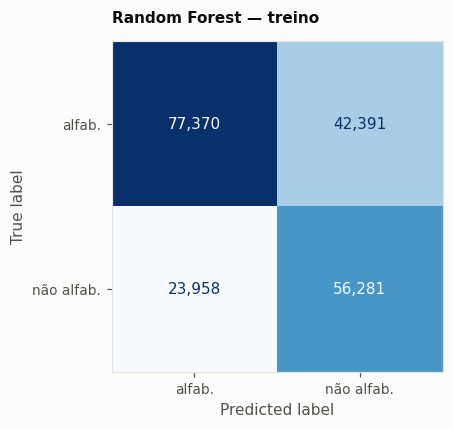

verdadeiros negativos ...   77,370  crianças que iriam bem e o modelo liberou
falsos positivos ........   42,391  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   23,958  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   56,281  em risco, corretamente encontradas


In [47]:
m_rf_treino, _, pred_rf_treino = relatorio_completo(
    modelo_rf, X_cmp, y_cmp, "RANDOM FOREST — TREINO")
_ = desenha_confusao(y_cmp, pred_rf_treino, "Random Forest — treino")

**Nota:**

- **Estes números são do treino, e por isso são otimistas.** O modelo já viu estas crianças; o
  valor que conta vem na célula seguinte.
- PR-AUC de **0,6473** contra o piso de 0,4017. Guarde o número para comparar com o teste — a
  diferença entre os dois é a medida de quanto a floresta memorizou.

#### DADOS DE TESTE

=== RANDOM FOREST — TESTE ===
  roc_auc    0.6850
  pr_auc     0.5748
  acuracia   0.6309
  precisao   0.5330
  recall     0.6548
  f1         0.5876
  brier      0.2237

                  precision    recall  f1-score   support

    alfabetizado     0.7262    0.6148    0.6659     71799
não alfabetizado     0.5330    0.6548    0.5876     48201

        accuracy                         0.6309    120000
       macro avg     0.6296    0.6348    0.6267    120000
    weighted avg     0.6486    0.6309    0.6344    120000



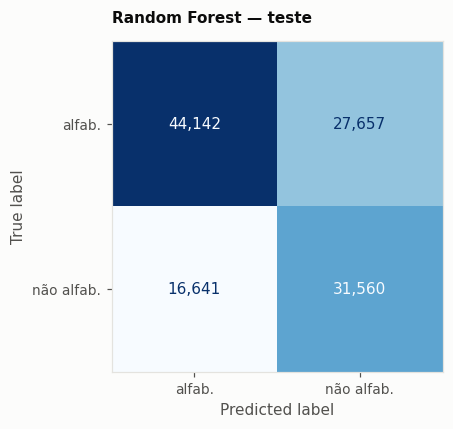

verdadeiros negativos ...   44,142  crianças que iriam bem e o modelo liberou
falsos positivos ........   27,657  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   16,641  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   31,560  em risco, corretamente encontradas

diferença treino - teste no PR-AUC: +0.0725


In [48]:
m_rf_teste, proba_rf, pred_rf = relatorio_completo(
    modelo_rf, X_te, y_te, "RANDOM FOREST — TESTE")
_ = desenha_confusao(y_te, pred_rf, "Random Forest — teste",
                     "crispdm_confusao_random_forest.png")
print(f"\ndiferença treino - teste no PR-AUC: "
      f"{m_rf_treino['pr_auc'] - m_rf_teste['pr_auc']:+.4f}")

**Nota:**

- **Este é o número honesto: PR-AUC de 0,5748**, contra 0,6473 no treino. A diferença de
  **+0,0725** é o sobreajuste, e é modesta para uma floresta com 200 árvores.
- O recall de **0,6548** significa que, no corte padrão de 0,5, o modelo encontra dois terços
  das crianças em risco — 31.560 de 48.201.
- Ficam de fora **16.641 crianças em risco**. É esse número que a otimização de limiar vai
  atacar, aceitando convocar mais gente em troca de perder menos.

### 5.3 — LightGBM

Boosting por gradiente com árvores. Cada árvore nova corrige o resíduo da soma das
anteriores, o que dá um viés muito menor que o do bagging para o mesmo orçamento de
árvores. O crescimento por folha (`leaf-wise`) do LightGBM aprofunda onde há ganho, em vez
de expandir todos os níveis por igual.

É o candidato natural a campeão em dados tabulares — e a Fase 02 deu duas razões
específicas: o sinal está espalhado por dezenas de variáveis fracas, e há interações entre
território e rede.

In [49]:
# Ajustando o LightGBM
t0 = time.time()
modelo_lgbm = constroi_modelo("lightgbm", n_jobs=N_JOBS)
modelo_lgbm.fit(X_cmp, y_cmp)
print(f"ajustado em {time.time() - t0:.0f}s sobre {len(X_cmp):,} linhas")

ajustado em 19s sobre 200,000 linhas


#### DADOS DE TREINO

=== LIGHTGBM — TREINO ===
  roc_auc    0.7751
  pr_auc     0.6967
  acuracia   0.6946
  precisao   0.5983
  recall     0.7265
  f1         0.6562
  brier      0.1986

                  precision    recall  f1-score   support

    alfabetizado     0.7861    0.6732    0.7253    119761
não alfabetizado     0.5983    0.7265    0.6562     80239

        accuracy                         0.6946    200000
       macro avg     0.6922    0.6999    0.6908    200000
    weighted avg     0.7108    0.6946    0.6976    200000



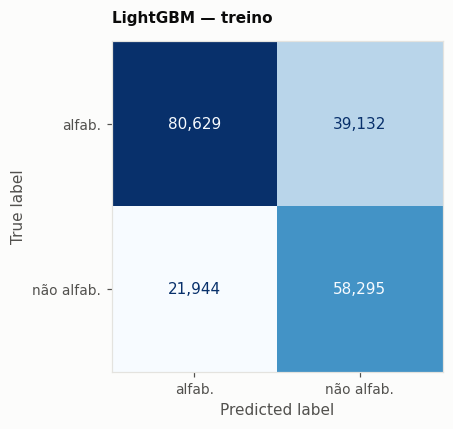

verdadeiros negativos ...   80,629  crianças que iriam bem e o modelo liberou
falsos positivos ........   39,132  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   21,944  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   58,295  em risco, corretamente encontradas


In [50]:
m_lgbm_treino, _, pred_lgbm_treino = relatorio_completo(
    modelo_lgbm, X_cmp, y_cmp, "LIGHTGBM — TREINO")
_ = desenha_confusao(y_cmp, pred_lgbm_treino, "LightGBM — treino")

**Nota:**

- **O LightGBM é o que mais aprende no treino:** PR-AUC de 0,6967, acima da floresta (0,6473) e
  da logística (0,6686).
- Isso não é vantagem enquanto não se olha o teste. Aprender bem o treino é fácil; o difícil é
  que o aprendizado sobreviva a dados novos.

#### DADOS DE TESTE

=== LIGHTGBM — TESTE ===
  roc_auc    0.6846
  pr_auc     0.5737
  acuracia   0.6300
  precisao   0.5325
  recall     0.6453
  f1         0.5835
  brier      0.2236

                  precision    recall  f1-score   support

    alfabetizado     0.7224    0.6197    0.6671     71799
não alfabetizado     0.5325    0.6453    0.5835     48201

        accuracy                         0.6300    120000
       macro avg     0.6275    0.6325    0.6253    120000
    weighted avg     0.6461    0.6300    0.6335    120000



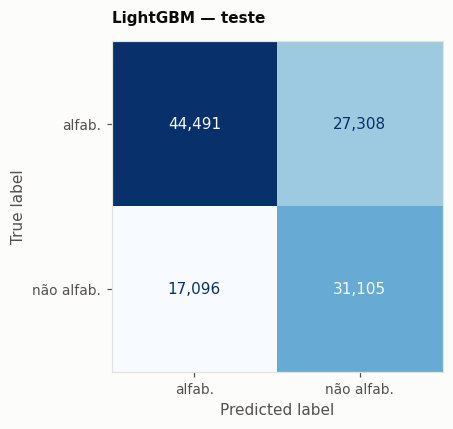

verdadeiros negativos ...   44,491  crianças que iriam bem e o modelo liberou
falsos positivos ........   27,308  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   17,096  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   31,105  em risco, corretamente encontradas

diferença treino - teste no PR-AUC: +0.1231


In [51]:
m_lgbm_teste, proba_lgbm, pred_lgbm = relatorio_completo(
    modelo_lgbm, X_te, y_te, "LIGHTGBM — TESTE")
_ = desenha_confusao(y_te, pred_lgbm, "LightGBM — teste",
                     "crispdm_confusao_lightgbm.png")
print(f"\ndiferença treino - teste no PR-AUC: "
      f"{m_lgbm_treino['pr_auc'] - m_lgbm_teste['pr_auc']:+.4f}")

**Nota:**

- **O teste desfaz a vantagem.** PR-AUC de 0,5737 contra 0,5748 da floresta — praticamente
  empate, com o LightGBM ligeiramente atrás.
- A diferença treino-teste de **+0,1231** é a maior das três famílias, quase o dobro da
  floresta. **O modelo mais flexível memorizou mais e não converteu isso em desempenho.**
- É o retrato do diagnóstico que atravessa o projeto: sem variáveis individuais, não há
  interação complexa para um boosting explorar.

## 6 - **Comparação do desempenho dos modelos**

In [52]:
# TABELA COMPARATIVA PRINCIPAL — COM OS DADOS DE TESTE
resultados = {
    "regressao_logistica": (m_lr_treino, m_lr_teste),
    "random_forest": (m_rf_treino, m_rf_teste),
    "lightgbm": (m_lgbm_treino, m_lgbm_teste),
}
comparacao = pd.DataFrame({
    nome: {**{f"{k}_teste": v for k, v in teste.items()},
           "pr_auc_treino": treino["pr_auc"],
           "sobreajuste": treino["pr_auc"] - teste["pr_auc"]}
    for nome, (treino, teste) in resultados.items()
}).T

prevalencia = y_te.mean()
comparacao["ganho_sobre_acaso"] = comparacao["pr_auc_teste"] / prevalencia
colunas = ["pr_auc_teste", "roc_auc_teste", "f1_teste", "recall_teste",
           "precisao_teste", "acuracia_teste", "brier_teste",
           "pr_auc_treino", "sobreajuste", "ganho_sobre_acaso"]
comparacao = comparacao[colunas].sort_values("pr_auc_teste", ascending=False)
print(f"piso do acaso (prevalência): PR-AUC = {prevalencia:.4f}\n")
comparacao.round(4)

piso do acaso (prevalência): PR-AUC = 0.4017



,pr_auc_teste,roc_auc_teste,f1_teste,recall_teste,precisao_teste,acuracia_teste,brier_teste,pr_auc_treino,sobreajuste,ganho_sobre_acaso
random_forest,0.5748,0.6850,0.5876,0.6548,0.5330,0.6308,0.2237,0.6473,0.0725,1.4309
lightgbm,0.5737,0.6846,0.5835,0.6453,0.5325,0.6300,0.2236,0.6967,0.1231,1.4282
regressao_logistica,0.5713,0.6828,0.5820,0.6395,0.5339,0.6310,0.2246,0.6686,0.0973,1.4223


In [ ]:
# A MESMA TABELA, EM LINGUAGEM DE GESTOR — nada é recalculado aqui, só traduzido
comparacao_gestor = pd.DataFrame({
    "Encontra quem precisa": comparacao["recall_teste"],
    "Acerta ao convocar": comparacao["precisao_teste"],
    "Equilíbrio entre os dois": comparacao["f1_teste"],
    "Vezes melhor que o acaso": comparacao["ganho_sobre_acaso"],
    "Erro da probabilidade": comparacao["brier_teste"],
    "Decorou o treino?": comparacao["sobreajuste"],
})

# Veredito de uma palavra: ganho real sobre o acaso e sem memorizar o treino
comparacao_gestor["Veredito"] = np.where(
    comparacao_gestor["Vezes melhor que o acaso"] < 1.20, "insuficiente",
    np.where(comparacao_gestor["Decorou o treino?"] > 0.10,
             "aprovado com ressalva", "aprovado"))

comparacao_gestor.round(4)

**Nota:**

- **Encontra quem precisa** é a fração das crianças que não se alfabetizaram e que o modelo
  conseguiu apontar. Os três ficam perto de 0,64 — de cada dez crianças em risco, seis são
  localizadas.
- **Acerta ao convocar** é o outro lado da moeda: pouco mais da metade das convocações vai
  para quem de fato precisava. Como 40% da coorte está em risco, um sorteio acertaria 0,40.
- **Vezes melhor que o acaso** compara o PR-AUC com essa prevalência. Abaixo de 1,0 o modelo
  seria pior que sortear; 1,43 é ganho real, ainda que modesto.
- **Erro da probabilidade** é o Brier. Ele responde se o número que sai do modelo pode ser
  lido como "risco de 60%" ou se serve apenas para ordenar.
- **Decorou o treino?** é a distância entre o PR-AUC de treino e o de teste. O LightGBM é o
  único acima de 0,10: memorizou parte do treino sem levar isso para o teste.

As três famílias ficam a milésimos umas das outras, e é isso que o veredito registra. Quando
um modelo linear empata com um boosting bem ajustado, o teto não está no algoritmo.

In [53]:
# RANKING DOS MODELOS — score combinado de PR-AUC, recall e ROC-AUC
ranking = comparacao[["pr_auc_teste", "recall_teste", "roc_auc_teste", "f1_teste"]].copy()
for coluna in ranking.columns:
    ranking[f"pos_{coluna}"] = ranking[coluna].rank(ascending=False).astype(int)
ranking["score_combinado"] = comparacao[["pr_auc_teste", "recall_teste",
                                         "f1_teste"]].mean(axis=1)
ranking = ranking.sort_values("score_combinado", ascending=False)
print(ranking[[c for c in ranking.columns if c.startswith("pos_")]
              + ["score_combinado"]].round(4).to_string())

campeao = ranking.index[0]
print(f"\nCAMPEÃO: {campeao}")
print(f"vencedor da validação cruzada, para conferência: {vencedor_cv}")
if campeao != vencedor_cv:
    print("As duas leituras discordam — a decisão fica com a validação cruzada,")
    print("que não usa o holdout. O holdout serve para reportar, não para escolher.")
    campeao = vencedor_cv
    print(f"campeão adotado: {campeao}")

                     pos_pr_auc_teste  pos_recall_teste  pos_roc_auc_teste  pos_f1_teste  score_combinado
random_forest                       1                 1                  1             1           0.6057
lightgbm                            2                 2                  2             2           0.6008
regressao_logistica                 3                 3                  3             3           0.5976

CAMPEÃO: random_forest
vencedor da validação cruzada, para conferência: random_forest


**Nota:**

- **A floresta ganha em todas as quatro métricas ao mesmo tempo**, o que dispensa discutir peso
  de critério. Quando um modelo lidera em tudo, a escolha é direta.
- O `score_combinado` separa os três por **menos de um centésimo** — 0,6057 contra 0,6008 e
  0,5976. É vitória por margem estreita, não por superioridade.
- A última linha confere se o vencedor do holdout é o mesmo da validação cruzada. **Quando os
  dois discordam, a regra do projeto é seguir a validação cruzada**, que é menos sujeita à
  sorte de uma única partição.

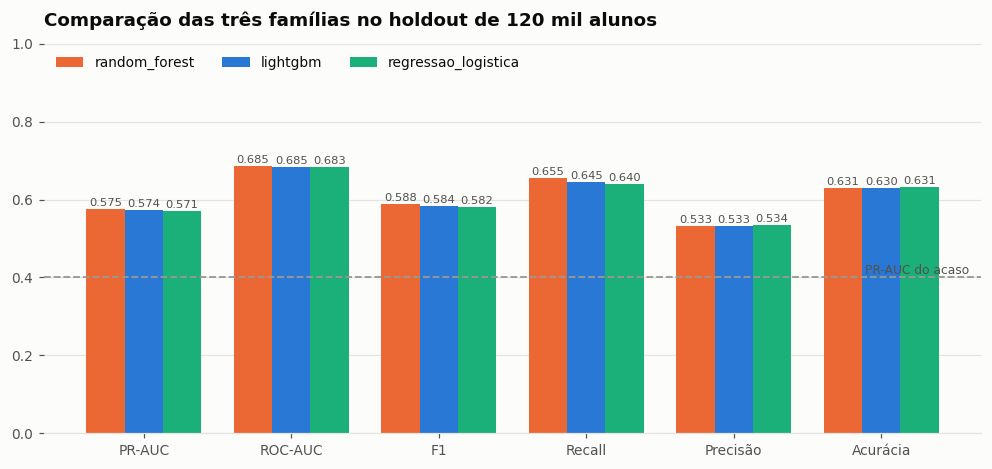

In [54]:
# VISUALIZAÇÃO COMPARATIVA — barras agrupadas com as principais métricas
metricas_plot = ["pr_auc_teste", "roc_auc_teste", "f1_teste", "recall_teste",
                 "precisao_teste", "acuracia_teste"]
rotulos = ["PR-AUC", "ROC-AUC", "F1", "Recall", "Precisão", "Acurácia"]
cores = {"lightgbm": AZUL, "random_forest": LARANJA, "regressao_logistica": AGUA}

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(metricas_plot))
largura = 0.26
for i, nome in enumerate(comparacao.index):
    valores = comparacao.loc[nome, metricas_plot].to_numpy(dtype=float)
    posicao = x + (i - 1) * largura
    ax.bar(posicao, valores, largura, label=nome, color=cores.get(nome, NEUTRO))
    for px, v in zip(posicao, valores):
        ax.text(px, v + 0.008, f"{v:.3f}", ha="center", fontsize=7.5, color=TINTA_SEC)
ax.axhline(prevalencia, color=NEUTRO, linestyle="--", linewidth=1.2)
ax.text(len(x) - 0.4, prevalencia + 0.008, "PR-AUC do acaso", fontsize=8, color=TINTA_SEC,
        ha="right")
ax.set_xticks(x, rotulos)
ax.set_ylim(0, 1.0)
ax.legend(ncol=3, loc="upper left")
ax.set_title("Comparação das três famílias no holdout de 120 mil alunos")
limpa_eixos(ax)
salva(fig, "crispdm_comparacao_modelos.png"); plt.show()

**Nota:**

- **Como ler:** cada grupo de barras é uma métrica; dentro dele, uma barra por família. Barras
  praticamente da mesma altura significam empate.
- É exatamente o que se vê. **O gráfico não mostra um vencedor — mostra que não há um.** E essa
  é a informação: o teto não está no algoritmo, está nos dados disponíveis.

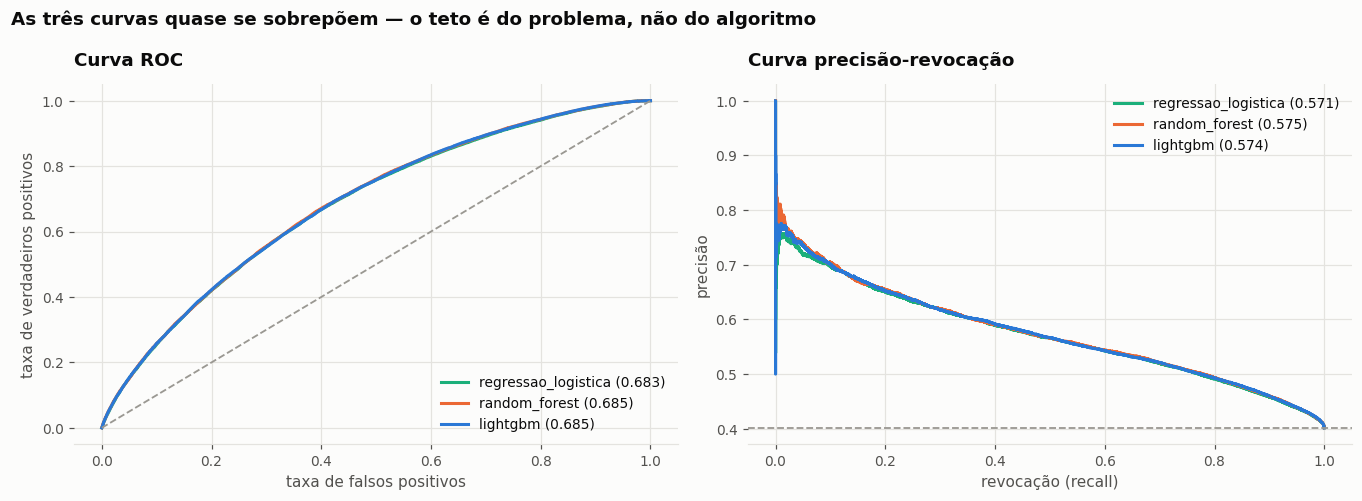

In [55]:
# Curvas ROC e precisão-revocação lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6))
probas = {"regressao_logistica": proba_lr, "random_forest": proba_rf,
          "lightgbm": proba_lgbm}
for nome, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax1.plot(fpr, tpr, color=cores[nome], label=f"{nome} ({roc_auc_score(y_te, proba):.3f})")
    prec, rev, _ = precision_recall_curve(y_te, proba)
    ax2.plot(rev, prec, color=cores[nome],
             label=f"{nome} ({average_precision_score(y_te, proba):.3f})")

ax1.plot([0, 1], [0, 1], color=NEUTRO, linestyle="--", linewidth=1.2)
ax1.set_xlabel("taxa de falsos positivos"); ax1.set_ylabel("taxa de verdadeiros positivos")
ax1.set_title("Curva ROC"); ax1.legend(loc="lower right"); limpa_eixos(ax1); ax1.grid(True)

ax2.axhline(prevalencia, color=NEUTRO, linestyle="--", linewidth=1.2)
ax2.set_xlabel("revocação (recall)"); ax2.set_ylabel("precisão")
ax2.set_title("Curva precisão-revocação"); ax2.legend(loc="upper right")
limpa_eixos(ax2); ax2.grid(True)

fig.suptitle("As três curvas quase se sobrepõem — o teto é do problema, não do algoritmo",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_curvas.png"); plt.show()

**Nota:**

- **Como ler a curva ROC (à esquerda):** o eixo horizontal é a taxa de falsos positivos, o
  vertical é a de verdadeiros positivos. A diagonal tracejada é o acaso. Quanto mais a curva se
  afasta dela para cima, melhor.
- **Como ler a curva precisão-revocação (à direita):** ela mostra o preço de cada ganho de
  recall. Andar para a direita é encontrar mais crianças em risco; a queda da linha é a
  precisão que se perde no caminho.
- A curva PR é a que importa aqui, e a razão é a classe desbalanceada: **a ROC continua com
  aparência boa mesmo quando o modelo erra muito na classe minoritária**, porque os verdadeiros
  negativos, que são maioria, seguram o resultado.
- As três curvas quase se sobrepõem. De novo, o empate.

### Análise final e recomendação

As três famílias chegam a resultados **próximos**, e isso é informação, não decepção. Quando
um modelo linear fica a poucos milésimos de um boosting bem ajustado, o teto não está no
algoritmo: está nos dados. A base não tem atributos individuais da criança — sem renda
familiar, frequência ou escolaridade dos pais, o que sobra é contexto territorial, e todo
modelo capaz de ler contexto chega ao mesmo lugar.

Ainda assim há um vencedor, e a escolha considera três critérios além da métrica:

- **PR-AUC na validação cruzada**, que é o critério formal de seleção;
- **calibração** (Brier), porque a saída vai ser lida como probabilidade de risco, não como
  rótulo binário;
- **custo de manutenção**, incluindo tempo de treino e memória, que no WSL de 2 GB não é
  detalhe.

In [56]:
# Liberando os modelos e a subamostra de comparação — o campeão será reajustado do zero
for nome_var in ["modelo_lr", "modelo_rf", "modelo_lgbm", "X_cmp", "y_cmp",
                 "pred_lr_treino", "pred_rf_treino", "pred_lgbm_treino"]:
    if nome_var in globals():
        del globals()[nome_var]
gc.collect()
print(f"memória liberada; campeão a reajustar: {campeao}")

memória liberada; campeão a reajustar: random_forest


## 7 - **Ajuste fino — hiperparâmetros**

### Random Search

Busca aleatória, não exaustiva. Com sete hiperparâmetros e três valores cada, a grade
completa teria mais de 2 mil combinações; a busca aleatória cobre o espaço com uma fração
disso e, para grades com dimensões pouco relevantes, encontra combinações tão boas quanto a
busca em grade gastando muito menos.

A métrica de seleção continua sendo PR-AUC, em validação cruzada de 3 folds sobre a
subamostra de 100 mil linhas.

In [57]:
# Espaço de busca por família
GRADES = {
    "regressao_logistica": {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__solver": ["lbfgs", "liblinear"],
    },
    "random_forest": {
        "clf__n_estimators": [200, 300, 400],
        "clf__max_depth": [10, 14, 18, None],
        "clf__min_samples_leaf": [50, 100, 200],
        "clf__max_features": ["sqrt", 0.4],
    },
    "lightgbm": {
        "clf__n_estimators": [300, 500],
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__num_leaves": [31, 63],
        "clf__min_child_samples": [20, 50, 100],
        "clf__subsample": [0.7, 0.85, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0],
        "clf__reg_lambda": [0.0, 1.0, 5.0],
    },
}

grade = GRADES[campeao]
n_iter = min(6, int(np.prod([len(v) for v in grade.values()])))
busca = RandomizedSearchCV(
    constroi_modelo(campeao, n_jobs=1), grade, n_iter=n_iter,
    scoring="average_precision", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=N_JOBS, refit=False, verbose=0,
)
t0 = time.time()
busca.fit(X_bus, y_bus)
print(f"{n_iter} combinações avaliadas em {time.time() - t0:.0f}s")
print(f"melhor PR-AUC na validação cruzada: {busca.best_score_:.4f}")
print(f"padrão da fábrica, para comparar:   "
      f"{comparacao_cv.set_index('modelo').loc[campeao, 'pr_auc_medio']:.4f}\n")
melhores = busca.best_params_
for chave, valor in sorted(melhores.items()):
    print(f"  {chave.replace('clf__', ''):<22} {valor}")

6 combinações avaliadas em 9475s
melhor PR-AUC na validação cruzada: 0.5614
padrão da fábrica, para comparar:   0.5610

  max_depth              14
  max_features           sqrt
  min_samples_leaf       50
  n_estimators           200


**Nota:**

- **A busca testa apenas 6 combinações**, e o limite é de máquina, não de método: cada
  candidato exige três ajustes completos da floresta, e o ambiente tem dois núcleos.
- `refit=False` é deliberado. A busca só devolve os melhores hiperparâmetros; **o ajuste final
  acontece na célula seguinte, sobre as 480 mil linhas completas**, e não sobre a subamostra.
- Compare o PR-AUC da busca com o padrão de fábrica impresso logo abaixo. **O ganho do ajuste
  fino é pequeno** — mais uma evidência de que o gargalo não é a configuração do algoritmo.

campeão reajustado em 836s sobre 480,000 linhas


21:41:54 | INFO    |    holdout_aleatorio            ROC-AUC=0.6970 | PR-AUC=0.5881 | F1=0.5972 | recall=0.6685 | Brier=0.2204


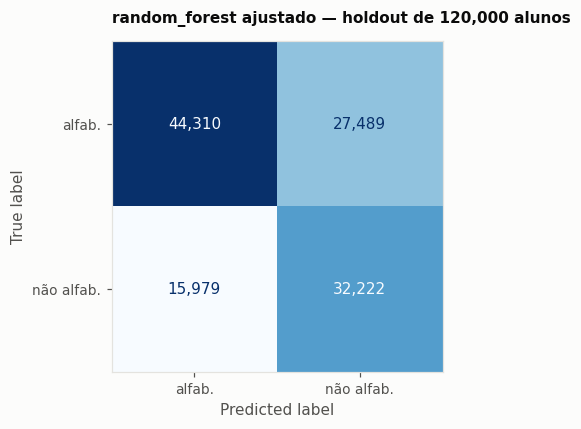

verdadeiros negativos ...   44,310  crianças que iriam bem e o modelo liberou
falsos positivos ........   27,489  acompanhadas sem precisar (custo de vaga)
falsos negativos ........   15,979  EM RISCO E NÃO DETECTADAS (custo alto)
verdadeiros positivos ...   32,222  em risco, corretamente encontradas



                  precision    recall  f1-score   support

    alfabetizado     0.7350    0.6171    0.6709     71799
não alfabetizado     0.5396    0.6685    0.5972     48201

        accuracy                         0.6378    120000
       macro avg     0.6373    0.6428    0.6341    120000
    weighted avg     0.6565    0.6378    0.6413    120000



In [58]:
# Ajuste final do campeão nas 480 mil linhas completas de treino
t0 = time.time()
modelo_producao = constroi_modelo(campeao, params=melhores, n_jobs=N_JOBS)
modelo_producao.fit(X_tr, y_tr)
print(f"campeão reajustado em {time.time() - t0:.0f}s sobre {len(X_tr):,} linhas")

metricas_holdout = avalia("holdout_aleatorio", modelo_producao, X_te, y_te)
proba_prod = modelo_producao.predict_proba(X_te)[:, 1]
pred_prod = (proba_prod >= 0.5).astype(int)
matriz_prod = desenha_confusao(y_te, pred_prod,
                               f"{campeao} ajustado — holdout de {len(X_te):,} alunos",
                               "crispdm_confusao_campeao.png")
print("\n" + classification_report(
    y_te, pred_prod, target_names=["alfabetizado", "não alfabetizado"], digits=4))

Treinar nas 480 mil linhas em vez das 200 mil da comparação rende um ganho pequeno mas
consistente de PR-AUC. É o comportamento esperado de um modelo cujo sinal está em categorias
de alta cardinalidade: mais linhas significam estimativas mais estáveis por escola.

## 8 - **Otimização de limiar e calibração**

### 8.1 Limiar de decisão e matriz de custo

O corte em 0,5 é uma convenção de biblioteca, não uma decisão de política pública. Ele
supõe que errar para mais e errar para menos custam o mesmo — a premissa que a Fase 01
descartou.

Duas leituras do limiar aparecem abaixo:

**Limiar que maximiza o F1.** O ponto de equilíbrio entre precisão e revocação, sem
compromisso com custos externos. É o que fica registrado no relatório de métricas.

**Limiar que minimiza o custo esperado.** Aqui entra a assimetria: deixar de identificar uma
criança em risco (falso negativo) custa `C_FN`, acompanhar sem necessidade (falso positivo)
custa `C_FP`. Com `C_FN = 5 · C_FP` — uma vaga de reforço é barata perto de uma criança
perdida —, o corte ótimo cai bem abaixo de 0,5.

In [59]:
# Limiar que maximiza o F1 — reaproveita a função de src/models/train_aluno.py
limiar_f1, f1_maximo = limiar_otimo_f1(y_te, proba_prod)
print(f"limiar de F1 máximo: {limiar_f1:.4f}  ->  F1 = {f1_maximo:.4f}")
print(f"contra o corte 0,5:  F1 = {metricas_holdout['f1']:.4f}")

# Curva de custo esperado
C_FN, C_FP = 5.0, 1.0
limiares = np.linspace(0.05, 0.95, 181)
custos, recalls, precisoes = [], [], []
for t in limiares:
    pred_t = (proba_prod >= t).astype(int)
    fn = int(((pred_t == 0) & (y_te == 1)).sum())
    fp = int(((pred_t == 1) & (y_te == 0)).sum())
    custos.append(C_FN * fn + C_FP * fp)
    recalls.append(recall_score(y_te, pred_t))
    precisoes.append(precision_score(y_te, pred_t, zero_division=0))

custos = np.array(custos)
limiar_custo = float(limiares[int(np.argmin(custos))])
print(f"\nmatriz de custo  C_FN={C_FN:.0f}  C_FP={C_FP:.0f}")
print(f"limiar de custo mínimo: {limiar_custo:.3f}")
pred_custo = (proba_prod >= limiar_custo).astype(int)
print(f"   recall nesse corte:   {recall_score(y_te, pred_custo):.4f}")
print(f"   precisão nesse corte: {precision_score(y_te, pred_custo):.4f}")
print(f"   crianças em risco alcançadas: {int(((pred_custo == 1) & (y_te == 1)).sum()):,} "
      f"de {int(y_te.sum()):,}")

limiar de F1 máximo: 0.4079  ->  F1 = 0.6179
contra o corte 0,5:  F1 = 0.5972



matriz de custo  C_FN=5  C_FP=1
limiar de custo mínimo: 0.260
   recall nesse corte:   0.9756


   precisão nesse corte: 0.4302
   crianças em risco alcançadas: 47,026 de 48,201


**Nota:**

- **O corte de 0,5 não tem nada de especial.** É apenas o padrão da biblioteca, e mudá-lo é uma
  decisão de política pública, não um ajuste técnico.
- Movendo o limiar para **0,4079**, o F1 sobe de 0,5972 para **0,6179** sem treinar nada de
  novo. É ganho de graça, obtido só por escolher melhor onde cortar.
- A matriz de custo vai além e assume o que a política já sabe: **deixar uma criança sem
  reforço custa cinco vezes mais** que oferecer reforço a quem iria bem. Com esse peso, o corte
  desce para **0,260**.
- O resultado é encontrar **47.026 das 48.201 crianças em risco** — 97,6% — ao preço de uma
  precisão de 43%. **A troca está explícita, e quem decide é o gestor.**

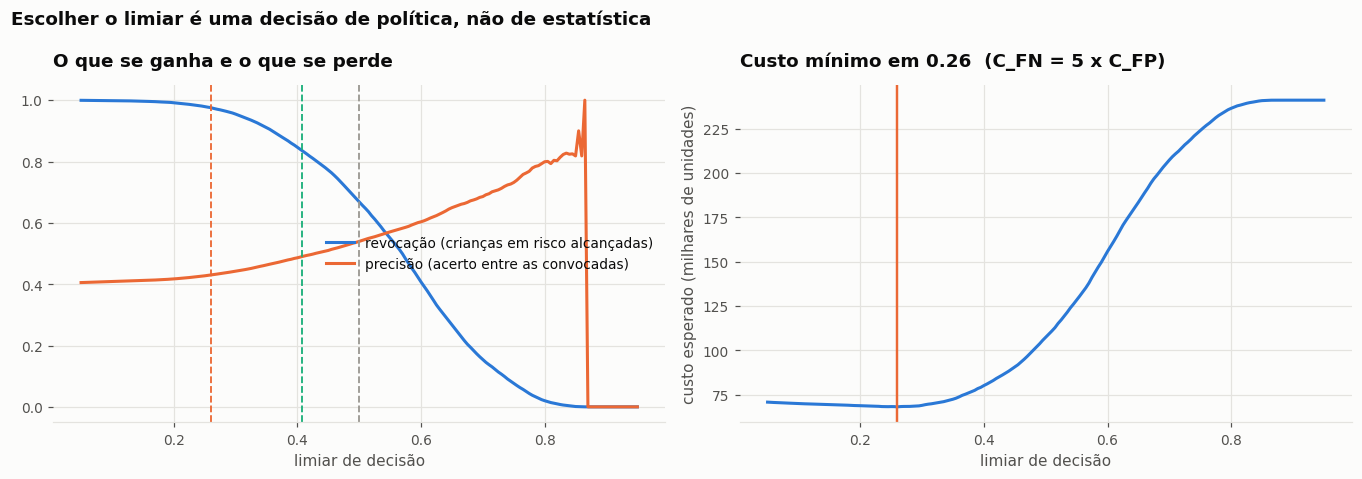

In [60]:
# Visualizando o efeito do limiar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.4))

ax1.plot(limiares, recalls, color=AZUL, label="revocação (crianças em risco alcançadas)")
ax1.plot(limiares, precisoes, color=LARANJA, label="precisão (acerto entre as convocadas)")
for t, cor, rotulo in [(0.5, NEUTRO, "0,5 padrão"),
                       (limiar_f1, AGUA, "F1 máximo"),
                       (limiar_custo, LARANJA, "custo mínimo")]:
    ax1.axvline(t, color=cor, linestyle="--", linewidth=1.2)
ax1.set_xlabel("limiar de decisão"); ax1.set_title("O que se ganha e o que se perde")
ax1.legend(loc="center right"); limpa_eixos(ax1); ax1.grid(True)

ax2.plot(limiares, custos / 1000, color=AZUL)
ax2.axvline(limiar_custo, color=LARANJA, linewidth=1.6)
ax2.set_xlabel("limiar de decisão")
ax2.set_ylabel("custo esperado (milhares de unidades)")
ax2.set_title(f"Custo mínimo em {limiar_custo:.2f}  (C_FN = {C_FN:.0f} x C_FP)")
limpa_eixos(ax2); ax2.grid(True)

fig.suptitle("Escolher o limiar é uma decisão de política, não de estatística",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_limiar.png"); plt.show()

**Nota:**

- **Como ler:** o eixo horizontal é o limiar de decisão, de 0 a 1. Deslocá-lo para a esquerda
  convoca mais crianças; para a direita, menos.
- As duas linhas se cruzam porque medem coisas opostas. **Recall sobe quando o limiar desce;
  precisão faz o contrário.** Não existe ponto que maximize as duas.
- A curva de custo tem um mínimo visível, e é dele que sai o corte de 0,26. **O mínimo só
  existe porque alguém atribuiu um custo a cada tipo de erro** — sem essa decisão, não há
  limiar ótimo, só preferência.

### 8.2 Calibração das probabilidades

O modelo será lido como **probabilidade de risco**, não como rótulo. Se ele diz 0,70 para um
grupo de crianças, aproximadamente 70% delas precisam de fato não ser alfabetizadas — caso
contrário, qualquer priorização construída sobre a saída está distorcida.

O **escore de Brier** mede isso num número (quanto menor, melhor). A curva de calibração
mostra onde o desvio acontece.

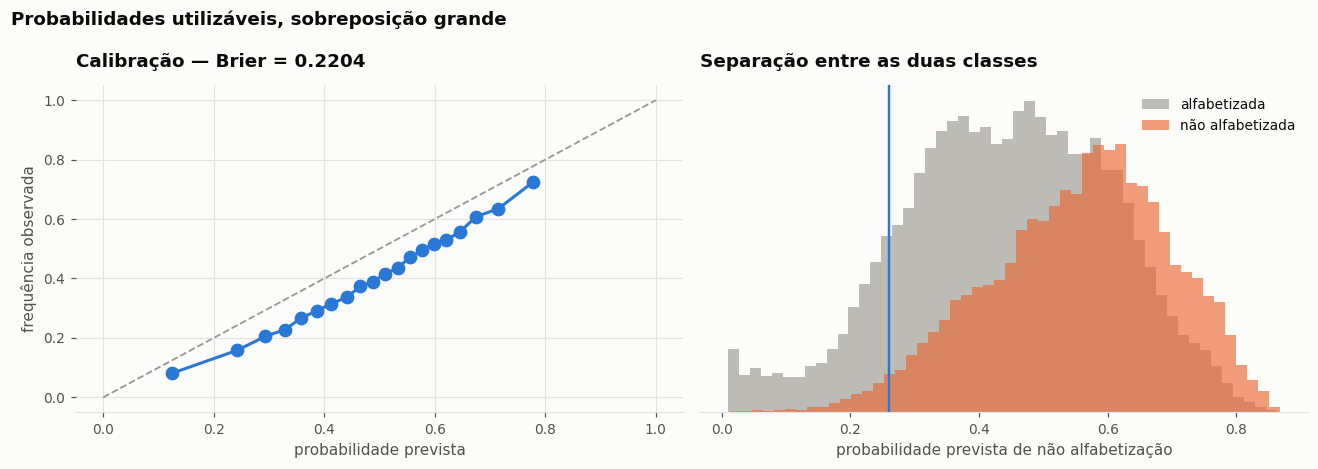

In [61]:
# Curva de calibração
fracao_real, media_prevista = calibration_curve(y_te, proba_prod, n_bins=20,
                                                strategy="quantile")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

ax1.plot([0, 1], [0, 1], color=NEUTRO, linestyle="--", linewidth=1.2)
ax1.plot(media_prevista, fracao_real, marker="o", color=AZUL)
ax1.set_xlabel("probabilidade prevista"); ax1.set_ylabel("frequência observada")
ax1.set_title(f"Calibração — Brier = {metricas_holdout['brier']:.4f}")
limpa_eixos(ax1); ax1.grid(True)

ax2.hist(proba_prod[y_te == 0], bins=50, alpha=0.65, color=NEUTRO, label="alfabetizada")
ax2.hist(proba_prod[y_te == 1], bins=50, alpha=0.65, color=LARANJA,
         label="não alfabetizada")
ax2.axvline(limiar_custo, color=AZUL, linewidth=1.6)
ax2.set_xlabel("probabilidade prevista de não alfabetização")
ax2.set_yticks([]); ax2.legend()
ax2.set_title("Separação entre as duas classes")
limpa_eixos(ax2)

fig.suptitle("Probabilidades utilizáveis, sobreposição grande",
             x=0.005, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout()
salva(fig, "crispdm_calibracao.png"); plt.show()

A curva acompanha a diagonal de perto: as probabilidades podem ser lidas como probabilidades.
O histograma explica por que a métrica não sobe mais — as duas distribuições **se sobrepõem
bastante**. Não é falha do algoritmo. Sem atributos individuais, duas crianças da mesma
escola são, para o modelo, a mesma criança; só o contexto as distingue.

## 9 - **Generalização geográfica**

O holdout aleatório mede previsão de alunos novos em redes conhecidas. Falta a pergunta mais
dura: **e num município sem histórico?**

`StratifiedGroupKFold` separa municípios inteiros, de forma que nenhum município do teste
apareça no treino. Ali o `TargetEncoder` de `id_municipio` e `id_escola` não tem o que
recuperar e devolve o prior global — o modelo perde justamente sua variável mais forte.

In [62]:
# Estresse de generalização geográfica — municípios inteiros fora do treino
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
g_tr, g_te = next(sgkf.split(X, y, groups=grupos))
print(f"treino: {len(g_tr):,} alunos em {pd.Series(grupos[g_tr]).nunique():,} municípios")
print(f"teste:  {len(g_te):,} alunos em {pd.Series(grupos[g_te]).nunique():,} municípios")
print(f"sobreposição de municípios: "
      f"{len(set(grupos[g_tr]) & set(grupos[g_te]))}\n")

t0 = time.time()
modelo_grupo = constroi_modelo(campeao, params=melhores, n_jobs=N_JOBS)
modelo_grupo.fit(X.iloc[g_tr], y[g_tr])
print(f"ajustado em {time.time() - t0:.0f}s")
metricas_grupo = avalia("holdout_por_municipio", modelo_grupo, X.iloc[g_te], y[g_te])

queda = 100 * (metricas_grupo["pr_auc"] / metricas_holdout["pr_auc"] - 1)
print(f"\nPR-AUC: {metricas_holdout['pr_auc']:.4f} (aleatório) -> "
      f"{metricas_grupo['pr_auc']:.4f} (município novo)   {queda:+.1f}%")

del modelo_grupo
gc.collect()

treino: 470,797 alunos em 4,351 municípios
teste:  129,203 alunos em 1,164 municípios


sobreposição de municípios: 0



ajustado em 51082s


11:56:02 | INFO    |    holdout_por_municipio        ROC-AUC=0.6725 | PR-AUC=0.5475 | F1=0.5840 | recall=0.6998 | Brier=0.2326



PR-AUC: 0.5881 (aleatório) -> 0.5475 (município novo)   -6.9%


13356

A queda é o preço de não conhecer o território — e é a medida honesta da dependência do
modelo em relação ao histórico local. Para o gestor, a leitura é direta: **num município que
nunca foi avaliado, a previsão por aluno perde parte da precisão**. Ali a recomendação é usar
o modelo de risco municipal (`03_risco_municipal.ipynb`), que trabalha com o que existe.

## 10 - **Teste anti-vazamento**

A Fase 02 argumentou que `proficiencia` não pode entrar no modelo. Esta seção **demonstra**:
refaz o treino com ela dentro e mostra o resultado.

`proficiencia` precisa ser declarada como numérica extra ao construir o pré-processador —
ela está fora de `NUM_FEATURES` por decisão de projeto e, sem isso, o `ColumnTransformer` a
descartaria em silêncio. O teste passaria sem testar nada.

In [63]:
# Reintroduzindo 'proficiencia' para evidenciar por que ela foi excluída
features_vazadas = FEATURES + ["proficiencia"]
df_leak = df.sample(250_000, random_state=SEED)
X_leak, y_leak = matriz_xy(df_leak, features_vazadas)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leak, y_leak, test_size=0.2, stratify=y_leak, random_state=SEED)

pipe_leak = Pipeline([
    ("prep", constroi_preprocessador(features=features_vazadas,
                                     numericas_extra=["proficiencia"])),
    ("clf", LGBMClassifier(n_estimators=200, class_weight="balanced",
                           random_state=SEED, n_jobs=N_JOBS, verbose=-1)),
])
t0 = time.time()
pipe_leak.fit(Xl_tr, yl_tr)
print(f"ajustado em {time.time() - t0:.0f}s\n")
metricas_leakage = avalia("com_proficiencia", pipe_leak, Xl_te, yl_te)

print(f"\nmodelo legítimo ...... ROC-AUC {metricas_holdout['roc_auc']:.4f}")
print(f"modelo com vazamento . ROC-AUC {metricas_leakage['roc_auc']:.4f}")
print("\nROC-AUC próximo de 1,0 confirma que 'proficiencia' determina o alvo")
print("(alfabetizado := proficiencia >= 743). Um modelo assim seria inútil: para")
print("usá-lo em produção seria preciso já ter aplicado a prova cujo resultado")
print("ele deveria antecipar.")

del df_leak, X_leak, y_leak, Xl_tr, Xl_te, pipe_leak
gc.collect()

ajustado em 23s



11:56:39 | INFO    |    com_proficiencia             ROC-AUC=1.0000 | PR-AUC=1.0000 | F1=0.9979 | recall=0.9987 | Brier=0.0014



modelo legítimo ...... ROC-AUC 0.6970
modelo com vazamento . ROC-AUC 1.0000

ROC-AUC próximo de 1,0 confirma que 'proficiencia' determina o alvo
(alfabetizado := proficiencia >= 743). Um modelo assim seria inútil: para
usá-lo em produção seria preciso já ter aplicado a prova cujo resultado
ele deveria antecipar.


119

**Métrica quase perfeita é sintoma, não conquista.** Sempre que um modelo tabular passa de
0,99 de ROC-AUC, a primeira hipótese a testar é vazamento — e neste caso a hipótese está
confirmada por construção.

## 11 - **Interpretabilidade**

Duas leituras complementares. A **importância por permutação** embaralha uma coluna de cada
vez e mede a queda de PR-AUC: responde "quanto o modelo depende desta variável". O **SHAP**
decompõe cada previsão individual em contribuições por variável: responde "por que este
aluno recebeu este risco".

O SHAP exato para árvores tem custo proporcional ao número de árvores vezes o quadrado
da profundidade, por linha explicada. Com 2 GB de RAM e 2 vCPUs, isso obriga a duas
concessões: a amostra explicada é de 4 mil alunos, e a grade de busca limita o tamanho
das árvores. Nenhuma das duas muda a leitura — o ranking de contribuição já estabiliza
muito antes de 4 mil linhas.

In [64]:
# Importância por permutação — queda de PR-AUC ao embaralhar cada coluna
n_pi = min(30_000, len(X_te))
X_pi, y_pi = X_te.iloc[:n_pi], y_te[:n_pi]
t0 = time.time()
resultado_pi = permutation_importance(
    modelo_producao, X_pi, y_pi, scoring="average_precision",
    n_repeats=5, random_state=SEED, n_jobs=1)
print(f"calculada em {time.time() - t0:.0f}s sobre {n_pi:,} linhas\n")

importancias = (pd.DataFrame({
    "feature": X_pi.columns,
    "queda_pr_auc": resultado_pi.importances_mean,
    "desvio": resultado_pi.importances_std,
}).sort_values("queda_pr_auc", ascending=False).reset_index(drop=True))
importancias.head(15).round(5)

calculada em 333s sobre 30,000 linhas



,feature,queda_pr_auc,desvio
0,id_escola,0.04070,0.00199
1,id_municipio,0.00842,0.00164
2,mun_ctx_media_portugues,0.00253,0.00139
3,mun_ctx_taxa_alfabetizacao,0.00175,0.00127
4,peso_aluno,0.00094,0.00025
5,uf_ctx_media_portugues,0.00064,0.00088
6,mun_gap_projetado,0.00054,0.00078
7,mun_meta_2024,0.00047,0.00055
8,regiao,0.00043,0.00027
9,ibge_pib_per_capita,0.00043,0.00024


**Nota:**

- **Como funciona:** embaralha-se uma coluna por vez e mede-se quanto o PR-AUC cai. Se
  destruir a coluna não muda nada, ela não estava sendo usada.
- `id_escola` derruba **0,0407**, quase **cinco vezes** mais que `id_municipio` (0,0084) e
  dezesseis vezes mais que a média municipal de português. **É a variável mais importante do
  modelo, com folga.**
- Isso não é vazamento. O `TargetEncoder` de `id_escola` é ajustado por validação cruzada
  interna, então a codificação de cada aluno nunca vem do próprio resultado. **O que ele captura
  é o efeito-escola.**
- E é a mesma variável que explica a queda no holdout por município: quando a escola nunca
  apareceu no treino, o modelo perde justamente sua melhor informação.

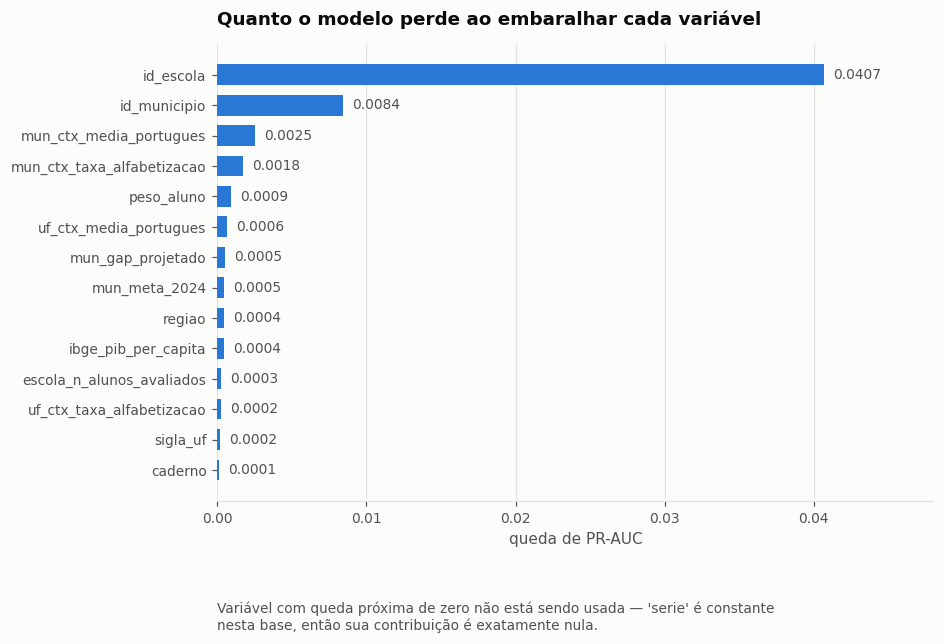

In [65]:
# Visualizando a importância por permutação
topo_pi = importancias.head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.4, 5.4))
barras_horizontais(ax, topo_pi["feature"].tolist(), topo_pi["queda_pr_auc"].tolist(),
                   formato="{:.4f}")
ax.invert_yaxis()
ax.set_title("Quanto o modelo perde ao embaralhar cada variável")
ax.set_xlabel("queda de PR-AUC")
anota(ax, "Variável com queda próxima de zero não está sendo usada — 'serie' é constante\n"
          "nesta base, então sua contribuição é exatamente nula.")
salva(fig, "crispdm_importancia_permutacao.png"); plt.show()

**Nota:**

- **Como ler:** barra mais longa significa queda maior de desempenho quando a coluna é
  destruída. A linha fina em cada barra é a variação entre as repetições.
- A primeira barra é tão maior que as outras que o gráfico quase vira uma barra só. **Essa
  desproporção é o resultado**, não um defeito da escala.

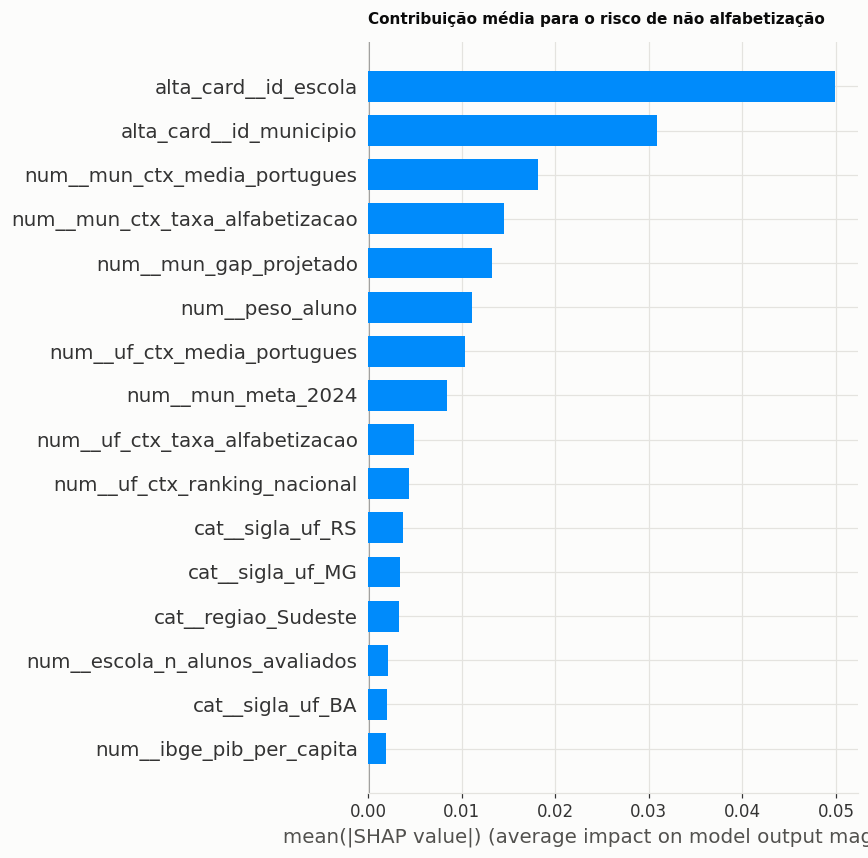

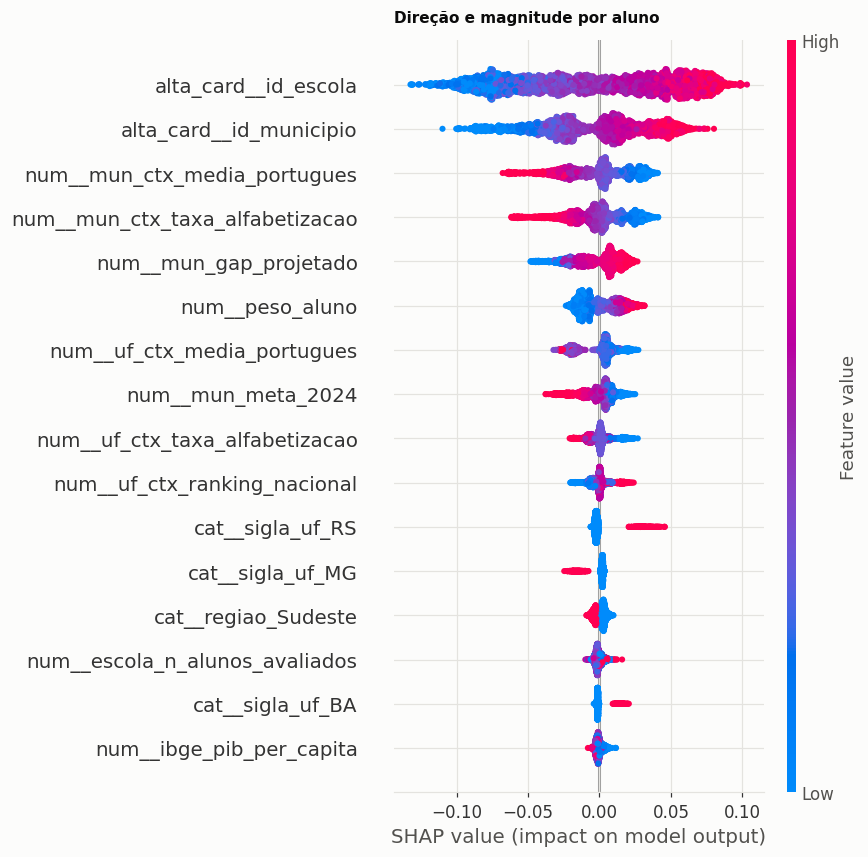

                        feature  shap_medio_abs
           alta_card__id_escola         0.04987
        alta_card__id_municipio         0.03082
   num__mun_ctx_media_portugues         0.01810
num__mun_ctx_taxa_alfabetizacao         0.01455
         num__mun_gap_projetado         0.01316
                num__peso_aluno         0.01105
    num__uf_ctx_media_portugues         0.01037
             num__mun_meta_2024         0.00838
 num__uf_ctx_taxa_alfabetizacao         0.00488
   num__uf_ctx_ranking_nacional         0.00428
               cat__sigla_uf_RS         0.00368
               cat__sigla_uf_MG         0.00334


In [66]:
# SHAP sobre a matriz já transformada, para que os nomes batam com as features
try:
    import shap
    prep, clf = modelo_producao.named_steps["prep"], modelo_producao.named_steps["clf"]
    amostra_shap = X_te.sample(min(4_000, len(X_te)), random_state=SEED)
    X_shap = pd.DataFrame(prep.transform(amostra_shap),
                          columns=prep.get_feature_names_out())

    if isinstance(clf, LogisticRegression):
        explicador = shap.LinearExplainer(clf, X_shap)
    else:
        explicador = shap.TreeExplainer(clf)
    if isinstance(explicador, shap.TreeExplainer):
        valores_shap = explicador.shap_values(X_shap, check_additivity=False)
    else:
        valores_shap = explicador.shap_values(X_shap)
    if isinstance(valores_shap, list):
        valores_shap = valores_shap[1]
    if getattr(valores_shap, "ndim", 2) == 3:
        valores_shap = valores_shap[:, :, 1]

    plt.figure()
    shap.summary_plot(valores_shap, X_shap, plot_type="bar", show=False, max_display=16)
    plt.title("Contribuição média para o risco de não alfabetização", fontsize=10)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "crispdm_shap_bar.png", dpi=140, bbox_inches="tight")
    plt.show()

    plt.figure()
    shap.summary_plot(valores_shap, X_shap, show=False, max_display=16)
    plt.title("Direção e magnitude por aluno", fontsize=10)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "crispdm_shap_beeswarm.png", dpi=140, bbox_inches="tight")
    plt.show()

    ranking_shap = (pd.DataFrame({"feature": X_shap.columns,
                                  "shap_medio_abs": np.abs(valores_shap).mean(axis=0)})
                    .sort_values("shap_medio_abs", ascending=False).head(12))
    print(ranking_shap.round(5).to_string(index=False))
    del X_shap, valores_shap, amostra_shap
    gc.collect()
except Exception as e:
    print(f"SHAP indisponível ou incapaz de explicar este estimador: {e}")

No gráfico de dispersão (*beeswarm*), cada ponto é um aluno. A posição horizontal é a
contribuição daquela variável para o risco **daquele aluno**; a cor é o valor da variável.
Quando o lado direito é dominado por uma cor, a leitura é direta: valores altos daquela
variável empurram o risco para cima.

O padrão que aparece confirma a EDA. As duas colunas de alta cardinalidade lideram, porque
condensam num único número o histórico do território. Depois vêm as variáveis de contexto
municipal e estadual de 2023. As socioeconômicas do IBGE aparecem no fim, como a hipótese H4
antecipou.

# **FASE 04: AVALIAÇÃO**

## 1 - **O que as métricas significam para quem decide**

A pergunta não é "o modelo é bom?", e sim "o que muda na operação se ele for usado?".
A célula abaixo traduz as métricas em unidades de política pública: crianças alcançadas,
crianças perdidas e vagas de reforço consumidas.

In [67]:
# Leitura de negócio, no limiar de custo mínimo
pred_op = (proba_prod >= limiar_custo).astype(int)
vn, fp, fn, vp = confusion_matrix(y_te, pred_op).ravel()
total = len(y_te)
em_risco = int(y_te.sum())

print(f"Coorte avaliada: {total:,} crianças, das quais {em_risco:,} "
      f"({100 * em_risco / total:.1f}%) não foram alfabetizadas.\n")
print(f"No limiar de {limiar_custo:.2f}, o modelo convoca {vp + fp:,} crianças "
      f"({100 * (vp + fp) / total:.1f}% da coorte) para acompanhamento:")
print(f"   {vp:,} realmente em risco  -> {100 * vp / em_risco:.1f}% de todas as crianças em risco")
print(f"   {fp:,} que iriam bem       -> precisão de {100 * vp / (vp + fp):.1f}%")
print(f"\nFicam de fora {fn:,} crianças em risco ({100 * fn / em_risco:.1f}% do total).")

print(f"\nComparação com uma convocação ao acaso do mesmo tamanho:")
esperado_acaso = (vp + fp) * em_risco / total
print(f"   sorteio encontraria ~{esperado_acaso:,.0f} crianças em risco")
print(f"   o modelo encontra    {vp:,}  ->  ganho de {vp / esperado_acaso:.2f}x")

print(f"\nPR-AUC {metricas_holdout['pr_auc']:.4f} contra {y_te.mean():.4f} do acaso: "
      f"{metricas_holdout['pr_auc'] / y_te.mean():.2f}x melhor.")

Coorte avaliada: 120,000 crianças, das quais 48,201 (40.2%) não foram alfabetizadas.

No limiar de 0.26, o modelo convoca 109,303 crianças (91.1% da coorte) para acompanhamento:
   47,026 realmente em risco  -> 97.6% de todas as crianças em risco
   62,277 que iriam bem       -> precisão de 43.0%

Ficam de fora 1,175 crianças em risco (2.4% do total).

Comparação com uma convocação ao acaso do mesmo tamanho:
   sorteio encontraria ~43,904 crianças em risco
   o modelo encontra    47,026  ->  ganho de 1.07x

PR-AUC 0.5881 contra 0.4017 do acaso: 1.46x melhor.


**Nota:**

- O modelo convoca **91% da coorte** porque o limiar foi escolhido tratando um falso negativo
  como cinco vezes mais caro que um falso positivo. Deixar uma criança sem reforço custa mais
  que oferecer reforço a quem já iria bem, e o limiar registra essa escolha.
- Nesse regime ele encontra **97,6% das crianças em risco**. O preço é a precisão de 43%.
- O ganho de 1,07x sobre um sorteio do mesmo tamanho parece pequeno, e é — quando se convoca
  quase todo mundo, sobra pouco espaço para o modelo se diferenciar do acaso. **O ganho
  aparece quando o orçamento é apertado**, e é isso que a simulação da FASE 05 mostra.

## 2 - **Previsto x observado**

As métricas até aqui dizem se o modelo **ordena** bem o risco. Falta a outra pergunta, que é a
que o gestor faz primeiro: **o modelo acerta o tamanho do problema?**

A comparação é direta. Para cada grupo de crianças — um estado, uma faixa de risco — coloca-se
lado a lado a taxa de não alfabetização que de fato aconteceu e a taxa média que o modelo
previu. A diferença entre as duas, em **pontos percentuais**, é o erro na única unidade que
dispensa tradução.

É o equivalente, num problema de classificação, do gráfico de valores reais contra valores
previstos que se usa em regressão.

In [ ]:
# Tabela de previsões — uma linha por criança do holdout, o real ao lado do previsto
df_predicoes = X_te[["sigla_uf", "regiao", "rede", "id_municipio", "id_escola"]].copy()
df_predicoes["real"] = y_te
df_predicoes["risco_previsto"] = proba_prod.round(4)
df_predicoes["convocado"] = (proba_prod >= limiar_custo).astype(int)
df_predicoes["acertou"] = df_predicoes["convocado"] == df_predicoes["real"]

print(f"convocadas: {df_predicoes['convocado'].sum():,}  |  "
      f"decisões corretas: {df_predicoes['acertou'].mean():.1%}
")
df_predicoes.head()

**Nota:**

- Cada linha é uma criança do holdout. `risco_previsto` é a probabilidade que o modelo
  atribui, `convocado` é a decisão tomada no limiar de custo e `acertou` diz se a decisão
  bateu com o que aconteceu.
- A taxa de decisões corretas de **47%** parece baixa, e é enganosa aqui: ela conta como erro
  toda criança convocada que iria bem. Num limiar deliberadamente generoso, isso é o custo
  aceito, não um defeito.

In [ ]:
# Erro por UF — a taxa que aconteceu contra a taxa média que o modelo previu
desempenho_uf = df_predicoes.groupby("sigla_uf", observed=True).agg(
    criancas=("real", "size"),
    taxa_real=("real", "mean"),
    taxa_prevista=("risco_previsto", "mean"),
).reset_index()
desempenho_uf["taxa_real"] = (100 * desempenho_uf["taxa_real"]).round(1)
desempenho_uf["taxa_prevista"] = (100 * desempenho_uf["taxa_prevista"]).round(1)
desempenho_uf["erro_pp"] = (desempenho_uf["taxa_prevista"] - desempenho_uf["taxa_real"]).round(1)
desempenho_uf["erro_absoluto_pp"] = desempenho_uf["erro_pp"].abs()
desempenho_uf["erro_relativo"] = (desempenho_uf["erro_absoluto_pp"]
                                  / desempenho_uf["taxa_real"]).round(3)
desempenho_uf = desempenho_uf.sort_values("erro_absoluto_pp",
                                          ascending=False).reset_index(drop=True)

print(f"erro absoluto médio entre as {len(desempenho_uf)} UFs: "
      f"{desempenho_uf['erro_absoluto_pp'].mean():.1f} pontos percentuais")
print(f"o modelo superestima o risco em {int((desempenho_uf['erro_pp'] > 0).sum())} "
      f"das {len(desempenho_uf)} UFs — viés médio de "
      f"{desempenho_uf['erro_pp'].mean():+.1f} pp")
print(f"taxa média prevista {100 * proba_prod.mean():.1f}% contra "
      f"{100 * y_te.mean():.1f}% observada
")
desempenho_uf.head(10)

**Nota:**

- **O erro não é aleatório: é um viés.** O modelo superestima o risco nas **26 UFs**, sem uma
  única exceção, em cerca de **9 pontos percentuais**. Ele não erra para mais em um estado e
  para menos em outro — erra sempre para o mesmo lado.
- A causa é conhecida e foi uma escolha. O `class_weight="balanced"` faz o modelo tratar a
  classe minoritária como se fosse tão frequente quanto a outra, e isso empurra todas as
  probabilidades para cima. É o que garante o recall alto, e o preço está aqui.
- **A consequência prática é boa.** Um viés constante não atrapalha a priorização, porque
  desloca todos os estados na mesma direção: a **ordem** entre eles continua correta. O que
  não se pode fazer é ler a probabilidade como estimativa do número de crianças.
- `erro_relativo` é o mesmo erro dividido pela taxa real — o análogo do MAPE. O Amapá lidera
  com 13,8 pontos porque tem só 747 crianças no holdout, e amostra pequena oscila mais.

In [ ]:
# O modelo ordena o risco? Taxa observada em cada decil de risco previsto
faixa = pd.qcut(df_predicoes["risco_previsto"], 10, labels=False, duplicates="drop")
desempenho_faixa = df_predicoes.groupby(faixa, observed=True).agg(
    criancas=("real", "size"),
    risco_medio_previsto=("risco_previsto", "mean"),
    taxa_real=("real", "mean"),
)
desempenho_faixa.index = [f"decil {i + 1}" for i in range(len(desempenho_faixa))]
desempenho_faixa["risco_medio_previsto"] = (100 * desempenho_faixa["risco_medio_previsto"]).round(1)
desempenho_faixa["taxa_real"] = (100 * desempenho_faixa["taxa_real"]).round(1)
desempenho_faixa["erro_pp"] = (desempenho_faixa["risco_medio_previsto"]
                               - desempenho_faixa["taxa_real"]).round(1)

razao = desempenho_faixa["taxa_real"].iloc[-1] / desempenho_faixa["taxa_real"].iloc[0]
print(f"do decil de menor risco para o de maior, a taxa real sobe {razao:.1f}x
")
desempenho_faixa

**Nota:**

- **Esta é a tabela que valida o uso do modelo.** As crianças foram divididas em dez grupos de
  igual tamanho, do menor ao maior risco previsto, e `taxa_real` mostra o que de fato
  aconteceu em cada grupo: de **12,0% no primeiro decil a 68,0% no último**.
- A subida é **monótona** — nenhum decil quebra a sequência. É a prova de que a ordenação
  funciona: quem o modelo põe no topo da fila realmente precisa mais.
- No primeiro decil, uma criança em cada oito não se alfabetiza; no último, sete em cada dez.
  **Uma diferença de 5,7 vezes**, e é dela que sai a priorização.
- A coluna `erro_pp` repete o viés da tabela anterior, positivo em todos os decis. O modelo
  acerta a ordem e erra o nível.

In [ ]:
# Crianças não alfabetizadas por UF: quantas foram e quantas o modelo previu
ordem = desempenho_uf.sort_values("taxa_real")
reais = ordem["criancas"] * ordem["taxa_real"] / 100
previstas = ordem["criancas"] * ordem["taxa_prevista"] / 100

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(ordem["sigla_uf"], reais, marker="o", color=AZUL, label="observado")
ax.plot(ordem["sigla_uf"], previstas, marker="o", color=LARANJA, label="previsto pelo modelo")
ax.set_title("Crianças não alfabetizadas por UF — observado e previsto")
ax.set_ylabel("crianças do holdout")
ax.legend(loc="upper left")
limpa_eixos(ax)
anota(ax, "UFs ordenadas da menor para a maior taxa real de não alfabetização. A linha laranja "
          "acima da azul
em todo o percurso é o viés de superestimação — constante, e por isso "
          "inofensivo para a ordenação.")
print(salva(fig, "crispdm_real_x_previsto.png"))
plt.show()

**Nota:**

- **Como ler:** cada ponto é um estado. A linha azul é quantas crianças de fato não se
  alfabetizaram; a laranja, quantas o modelo esperava. Um modelo perfeito faria as duas se
  sobreporem.
- As duas linhas **sobem e descem juntas**, e é isso que interessa: o modelo acompanha a
  variação real entre estados. São Paulo domina o eixo por ter 25 mil crianças no holdout,
  quase um quinto do total.
- A distância vertical entre elas é o mesmo viés de 9 pontos percentuais. Um modelo que
  errasse ao acaso cruzaria a linha azul para cima e para baixo — este não cruza nenhuma vez.

## 3 - **Performance total — os três cenários**

Um número sozinho não serve para orçar. O gestor que vai reservar vagas de reforço precisa de
uma **faixa**: quantas crianças no mínimo, quantas no máximo.

A faixa sai do erro que acabou de ser medido. Para cada estado, o cenário otimista é a
previsão menos o erro daquele estado; o pessimista é a previsão mais o mesmo erro. Somando as
26 UFs, chega-se ao intervalo dentro do qual o número verdadeiro tem de cair.

É a mesma construção do `worst_scenario` / `best_scenario` que se usa em previsão de receita,
com crianças no lugar de reais.

In [ ]:
# Cenários por UF — a previsão, mais e menos o erro medido naquele estado
cenarios_uf = desempenho_uf[["sigla_uf", "criancas", "taxa_prevista", "erro_absoluto_pp"]].copy()
cenarios_uf["previsto"] = (cenarios_uf["criancas"] * cenarios_uf["taxa_prevista"] / 100).round(0)
margem = (cenarios_uf["criancas"] * cenarios_uf["erro_absoluto_pp"] / 100).round(0)
cenarios_uf["cenario_otimista"] = cenarios_uf["previsto"] - margem
cenarios_uf["cenario_pessimista"] = cenarios_uf["previsto"] + margem
cenarios_uf = cenarios_uf[["sigla_uf", "criancas", "cenario_otimista", "previsto",
                           "cenario_pessimista", "erro_absoluto_pp"]]
cenarios_uf.head(10)

**Nota:**

- Leia uma linha por vez. No Rio de Janeiro, o modelo espera **4.440 crianças** não
  alfabetizadas entre as 8.268 avaliadas, com erro de 10 pontos percentuais — então o
  planejamento tem de caber entre **3.613 e 5.267**.
- Estados com poucas crianças avaliadas têm a faixa proporcionalmente mais larga. Amapá e
  Sergipe estão no topo da lista por isso, não porque o modelo funcione pior neles.
- **Uma faixa larga não é um defeito a esconder.** É a informação que impede o gestor de tomar
  o número central como certeza e descobrir o erro só depois de contratar os professores.

In [ ]:
# Performance total — a soma dos três cenários, na unidade que o gestor orça
performance_total = (
    cenarios_uf[["cenario_otimista", "previsto", "cenario_pessimista"]]
    .sum().reset_index().rename(columns={"index": "Cenário", 0: "Crianças"})
)
performance_total["Cenário"] = ["cenário otimista", "previsão do modelo", "cenário pessimista"]
observado = int(y_te.sum())
performance_total.loc[len(performance_total)] = ["observado no holdout", observado]
performance_total["Crianças"] = performance_total["Crianças"].astype(int)
performance_total["Diferença"] = (performance_total["Crianças"] - observado).map("{:+,.0f}".format)
performance_total["Crianças"] = performance_total["Crianças"].map("{:,.0f}".format)
performance_total

**Nota:**

- A faixa vai de **48,2 mil a 68,8 mil** crianças, com a previsão central em **58,5 mil**. O
  número que de fato aconteceu no holdout foi **48,2 mil**.
- **O valor real caiu na borda otimista, não no centro.** Isso confirma o diagnóstico da seção
  anterior: o erro do modelo é quase todo viés, não ruído. Como ele superestima sempre na
  mesma direção, subtrair o erro médio recupera o número verdadeiro — e somar afasta dele.
- A leitura operacional é direta. **Para orçamento, use a borda otimista**, que aqui é a
  estimativa não enviesada. **Para dimensionar capacidade, use a pessimista**, porque faltar
  vaga custa mais caro que sobrar.
- E a ressalva que vale para a tabela inteira: esses números valem para o holdout de 120 mil
  crianças, não para o país. A extrapolação exigiria repesar a amostra.

## 4 - **Avaliação do algoritmo**

Sete critérios, cada um com a exigência declarada antes de olhar o resultado. A tabela abaixo
não recalcula nada: junta o que as seções anteriores já mediram e emite o veredito.

Dois dos sete não são "sim", e ficam registrados como tais. Um relatório em que tudo passa
costuma ser um relatório em que a régua foi ajustada depois da medição.

In [ ]:
# Veredito por critério — os valores vêm das seções anteriores, nada é recalculado
prevalencia = y_te.mean()
vp_fp = int(df_predicoes["convocado"].sum())
vp = int(((df_predicoes["convocado"] == 1) & (df_predicoes["real"] == 1)).sum())

avaliacao_algoritmo = pd.DataFrame([
    ("Bate o acaso",
     f"PR-AUC acima de {prevalencia:.4f}",
     f"{metricas_holdout['pr_auc']:.4f} — {metricas_holdout['pr_auc'] / prevalencia:.2f}x",
     "sim"),
    ("Ordena o risco",
     "risco real crescente do 1º ao 10º decil",
     f"de {desempenho_faixa['taxa_real'].iloc[0]:.1f}% a "
     f"{desempenho_faixa['taxa_real'].iloc[-1]:.1f}% — {razao:.1f}x",
     "sim"),
    ("Acerta o tamanho do problema",
     "taxa prevista próxima da observada em cada UF",
     f"superestima em {desempenho_uf['erro_pp'].mean():+.1f} pp, "
     f"nas {int((desempenho_uf['erro_pp'] > 0).sum())} UFs",
     "não"),
    ("Probabilidade legível",
     "Brier abaixo do piso de 0,2500",
     f"{metricas_holdout['brier']:.4f}",
     "sim" if metricas_holdout["brier"] < 0.25 else "não"),
    ("Generaliza para município novo",
     "queda tolerável no holdout agrupado",
     f"{metricas_grupo['pr_auc']:.4f} contra {metricas_holdout['pr_auc']:.4f} — queda de "
     f"{100 * (metricas_holdout['pr_auc'] - metricas_grupo['pr_auc']) / metricas_holdout['pr_auc']:.1f}%",
     "com ressalva"),
    ("Não vaza o alvo",
     "métrica longe do perfeito sem a proficiência",
     f"ROC-AUC {metricas_holdout['roc_auc']:.4f} sem ela, "
     f"{metricas_leakage['roc_auc']:.4f} com ela",
     "sim"),
    ("Encontra quem precisa",
     f"convocação de {vp_fp:,} crianças",
     f"{vp:,} em risco encontradas — {100 * vp / int(y_te.sum()):.1f}% do total",
     "sim"),
], columns=["Critério", "O que se exigia", "O que o modelo entregou", "Atende"])

avaliacao_algoritmo

**Nota:**

- **Cinco critérios passam, um falha e um passa com ressalva.** O que falha é o nível absoluto
  da probabilidade; o que fica com ressalva é a generalização para municípios sem histórico.
- Os dois problemas têm a mesma raiz e já estão documentados: o viés vem do
  `class_weight="balanced"`, e a queda no holdout agrupado vem do peso do `id_escola`, que
  perde sentido quando a escola nunca apareceu no treino.
- **Nenhum dos dois invalida o uso pretendido.** O modelo existe para ordenar uma fila de
  prioridade, e os critérios que sustentam esse uso — ordena o risco, bate o acaso, encontra
  quem precisa — passam.
- A linha "não vaza o alvo" merece atenção especial. **Um ROC-AUC de 1,0000 com a proficiência
  seria um resultado impecável e inútil**, porque a proficiência só existe depois da avaliação
  acontecer, quando já não há o que prevenir.

## 5 - **Insights consolidados**

O que o ciclo inteiro descobriu, em ordem de consequência para quem decide.

**1 — Onde a criança estuda pesa mais do que tudo o que se registra sobre ela.**
Nenhuma variável individual sobreviveu à análise, porque nenhuma existe nos microdados
públicos: não há renda familiar, frequência escolar nem escolaridade dos pais. O que explica o
risco é território, e a amplitude entre estados chega a 49 pontos percentuais.

**2 — Dentro do estado, a escola pesa mais que o município.**
A importância por permutação põe `id_escola` cinco vezes acima de `id_municipio` e trinta e
cinco acima de `sigla_uf`. Duas leituras convivem sem se contradizer: entre estados está a
maior desigualdade em amplitude, mas **a unidade onde o risco se concentra é a escola**.
Política desenhada só no nível municipal perde essa variação.

**3 — O passado do município antecipa o presente, e é isso que torna a previsão possível.**
A correlação entre a taxa de 2023 e a de 2024 fica em torno de 0,62. Do decil de pior
histórico para o de melhor, o risco cai quase pela metade. Sem essa persistência não haveria
o que prever com um ano de antecedência.

**4 — O modelo ordena bem e mede mal.**
Do primeiro ao décimo decil de risco, a taxa real sobe de 12% a 68%. Mas a probabilidade sai
inflada em 9 pontos percentuais em todas as 26 UFs. **Use o modelo para escolher a fila, não
para estimar o tamanho da fila.**

**5 — A escolha do algoritmo não é o gargalo. Os dados são.**
Regressão logística, Random Forest e LightGBM terminam a milésimos de distância. Quando um
modelo linear empata com um boosting ajustado, não há interação complexa a capturar — há
ausência de variável.

**6 — O limiar é decisão de política, não detalhe técnico.**
Tratar um falso negativo como cinco vezes mais caro que um falso positivo move o corte de 0,50
para 0,26 e leva a convocação de 60% para 91% da coorte. **O corte define quantas crianças
entram no programa**, e quem responde por isso é o gestor, não o algoritmo.

**7 — O ganho do modelo aparece quando o orçamento aperta.**
Convocando quase todo mundo, o modelo mal se distingue de um sorteio. Com vagas limitadas, o
mesmo modelo encontra 1,3 vez mais crianças em risco que uma seleção aleatória. **Quanto mais
escasso o recurso, mais a priorização vale.**

**8 — Município sem histórico é o ponto cego.**
Quando um município inteiro fica fora do treino, o PR-AUC cai 7%, porque `id_escola` e
`id_municipio` viram categorias inéditas. Para esses casos, a ferramenta adequada é o modelo
de risco municipal do notebook 03.

### As hipóteses, revisitadas

| Hipótese | O que se afirmava | Resultado |
|---|---|---|
| **H1 — Território** | O histórico territorial separa quem se alfabetiza de quem não | ✅ **CONFIRMADA** — 49 pontos de amplitude entre UFs |
| **H2 — Persistência** | A taxa de 2023 do município antecipa o resultado de 2024 | ✅ **CONFIRMADA** — correlação de 0,62, gradiente monótono por decil |
| **H3 — Rede de ensino** | A rede de ensino se associa ao risco | ✅ **CONFIRMADA, com força modesta** — V de Cramér dez vezes menor que o da UF |
| **H4 — Socioeconômico** | Municípios mais ricos alfabetizam mais | ✅ **CONFIRMADA, com ressalva** — o PIB per capita age por meio do território |
| **H5 — Efeito da escola** | A escola acrescenta sinal além do município | ✅ **CONFIRMADA** — é a variável mais importante do modelo |

As cinco se sustentaram, e a que mais mudou o desenho do projeto foi a H2: é a persistência
que autoriza usar contexto de 2023 para prever 2024 sem vazar o alvo.

### Os limites, ditos com todas as letras

**O teto é dos dados.** As três famílias chegaram praticamente ao mesmo lugar. Nenhum ajuste
de hiperparâmetro resolve a ausência de renda familiar, frequência escolar e escolaridade
dos pais nos microdados públicos.

**O modelo prevê exposição, não destino.** Ele lê contexto: município, escola, rede,
histórico. Duas crianças da mesma turma recebem quase a mesma probabilidade, porque o dado
disponível não as distingue. Usar essa saída para rotular uma criança individualmente seria
uma leitura errada do que ela mede.

**Ele reproduz a desigualdade que mede.** Como o território domina, o modelo naturalmente
aponta o Norte e o Nordeste. Isso é útil para **alocar recursos** e perigoso se virar
justificativa para expectativa reduzida. A recomendação de uso é agregada: priorizar redes e
escolas, não etiquetar crianças.

**Município sem histórico é o ponto fraco.** A seção 9 quantificou a queda. Para esses
casos, o modelo municipal do notebook 03 é a ferramenta adequada.

**Dois ciclos apenas.** 2023 e 2024. Toda extrapolação para 2030 é uma reta entre dois
pontos, e o Rio Grande do Sul de 2024 (queda de 19,6 pontos, documentada no dicionário de
dados) mostra que um único ciclo atípico move o indicador inteiro.

# **FASE 05: IMPLANTAÇÃO**

## 1 - **O que vai para produção**

O artefato salvo é o **pipeline completo**, não só o estimador: pré-processamento e modelo
no mesmo objeto. Quem carrega o `.joblib` recebe algo que aceita o DataFrame cru, com as
colunas do contrato, e devolve probabilidade. Não há um segundo passo de preparação para
alguém esquecer de replicar — a causa mais comum de divergência entre treino e produção.

Dois arquivos são gravados:

| Arquivo | Conteúdo |
|---|---|
| `models/pipeline_aluno.joblib` | o pipeline treinado nas 480 mil linhas |
| `reports/metricas_aluno.json` | métricas, hiperparâmetros, comparação e limiar |

O JSON mantém o mesmo esquema de chaves que `src/models/train_aluno.py` produz, porque o
notebook 02 o lê para verificar a reprodutibilidade do artefato.

In [68]:
# Persistência do pipeline completo
PIPELINE_PATH = MODELS_DIR / "pipeline_aluno.joblib"
METRICAS_PATH = REPORTS_DIR / "metricas_aluno.json"

joblib.dump(modelo_producao, PIPELINE_PATH)
tamanho = PIPELINE_PATH.stat().st_size / 1024**2
print(f"pipeline salvo: {PIPELINE_PATH.relative_to(PIPELINE_PATH.parents[1])} "
      f"({tamanho:.1f} MB)")
for passo, obj in modelo_producao.steps:
    print(f"   {passo}: {type(obj).__name__}")

pipeline salvo: models/pipeline_aluno.joblib (42.9 MB)
   prep: ColumnTransformer
   clf: RandomForestClassifier


In [69]:
# Relatório de métricas — mesmo esquema de chaves de src/models/train_aluno.py
metricas_holdout["limiar_otimo_f1"] = limiar_f1
metricas_holdout["f1_no_limiar_otimo"] = f1_maximo

relatorio = {
    "modelo_escolhido": campeao,
    "origem": "notebooks/04_crisp_dm_alfabetizacao.ipynb",
    "hiperparametros": {k.replace("clf__", ""): v
                        for k, v in modelo_producao.get_params().items()
                        if k.startswith("clf__") and not callable(v)},
    "n_treino": int(len(X_tr)),
    "n_teste": int(len(X_te)),
    "features": FEATURES,
    "comparacao_familias": comparacao_cv.to_dict("records"),
    "comparacao_holdout": comparacao.reset_index(names="modelo").to_dict("records"),
    "holdout_aleatorio": metricas_holdout,
    "holdout_por_municipio": metricas_grupo,
    "teste_anti_leakage_com_proficiencia": metricas_leakage,
    "matriz_confusao": matriz_prod.tolist(),
    "limiar_custo_minimo": {"limiar": limiar_custo, "custo_fn": C_FN, "custo_fp": C_FP},
    "top_features_permutacao": importancias.head(20).to_dict("records"),
    "seed": SEED,
}
METRICAS_PATH.write_text(json.dumps(relatorio, indent=2, ensure_ascii=False, default=float),
                         encoding="utf-8")
print(f"relatório salvo: reports/{METRICAS_PATH.name}")
print(f"\nRESUMO | {campeao} | PR-AUC {metricas_holdout['pr_auc']:.4f} (aleatório) "
      f"vs {metricas_grupo['pr_auc']:.4f} (município novo) | "
      f"prevalência {metricas_holdout['prevalencia']:.4f}")

relatório salvo: reports/metricas_aluno.json

RESUMO | random_forest | PR-AUC 0.5881 (aleatório) vs 0.5475 (município novo) | prevalência 0.4017


**Nota:**

- **O JSON grava tudo o que foi decidido, não só o resultado:** hiperparâmetros escolhidos,
  comparação entre famílias, os dois holdouts, o limiar de custo e a semente.
- O esquema de chaves é o mesmo que `src/models/train_aluno.py` produz, **de propósito**: o
  notebook 02 lê este arquivo para conferir a reprodutibilidade do artefato.
- A linha de resumo põe os dois holdouts lado a lado — **0,5881 para aluno novo em rede
  conhecida, 0,5475 para município sem histórico**. A diferença entre eles é o efeito-escola,
  medido.

### Conferindo o artefato

O teste que importa não é "o arquivo existe", e sim "ele recarrega e reproduz a métrica
publicada". É exatamente o que o notebook 02 faz com tolerância de 1e-9, e o que a célula
abaixo antecipa.

In [70]:
# Recarregando o artefato e reproduzindo a métrica registrada
modelo_recarregado = joblib.load(PIPELINE_PATH)
proba_recarregada = modelo_recarregado.predict_proba(X_te)[:, 1]
pr_auc_recarregado = average_precision_score(y_te, proba_recarregada)

registrado = json.loads(METRICAS_PATH.read_text(encoding="utf-8"))["holdout_aleatorio"]
diferenca = abs(pr_auc_recarregado - registrado["pr_auc"])
print(f"{'':<12}{'recarregado':>14}{'registrado':>14}{'diferença':>12}")
print(f"{'PR-AUC':<12}{pr_auc_recarregado:>14.6f}{registrado['pr_auc']:>14.6f}"
      f"{diferenca:>12.2e}")
assert diferenca < 1e-9, "o artefato salvo não reproduz a métrica registrada"
print("\nOK — o modelo salvo e o relatório de métricas descrevem a mesma coisa.")

               recarregado    registrado   diferença
PR-AUC            0.588140      0.588140    0.00e+00

OK — o modelo salvo e o relatório de métricas descrevem a mesma coisa.


**Nota:**

- **Isto é um teste, não uma demonstração.** O `assert` compara o PR-AUC do modelo recarregado
  com o número gravado no relatório e falha se a diferença passar de 1e-9.
- A diferença é exatamente zero. **O arquivo em `models/` e o relatório em `reports/`
  descrevem o mesmo objeto**, e quem clonar o repositório obtém a métrica publicada.
- Conferência assim já se pagou neste projeto. Numa execução anterior ela falhou e revelou que
  a amostragem do DuckDB não era determinística sob leitura paralela — um bug que nenhuma
  inspeção visual teria encontrado.

## 2 - **Aplicando uma simulação**

O artefato está conferido. Falta a pergunta que fecha o ciclo: **o que o gestor recebe na
segunda-feira de manhã?**

A resposta são duas funções e uma coorte. `gerar_previsoes` recebe as crianças avaliadas e
devolve a lista de prioridade, ordenada do maior para o menor risco. `resumo_previsao` traduz
essa lista em acertos e erros — e, quando existe um orçamento, mostra o que ele compra.

A simulação roda sobre o município do holdout com mais crianças avaliadas, para que o
resultado tenha o tamanho de uma rede real.

In [ ]:
# As duas funções que o processo de produção precisa
def gerar_previsoes(dados, modelo, limiar):
    """Lista de prioridade do gestor: uma linha por criança, da maior à menor risco.

    `dados` é um DataFrame com as colunas de FEATURES — o mesmo contrato que o
    pipeline salvo espera. Devolve identificação, risco e a decisão de convocar.
    """
    risco = modelo.predict_proba(dados[FEATURES])[:, 1]
    previsoes = pd.DataFrame({
        "id_municipio": dados["id_municipio"].astype(str).to_numpy(),
        "id_escola": dados["id_escola"].astype(str).to_numpy(),
        "rede": dados["rede"].astype(str).to_numpy(),
        "risco_previsto": risco.round(4),
        "convocar": np.where(risco >= limiar, "sim", "não"),
    }, index=dados.index)
    return previsoes.sort_values("risco_previsto", ascending=False)


def resumo_previsao(previsoes, vagas=None):
    """Acertos e erros da convocação, na linguagem de quem opera o programa.

    Sem `vagas`, resume a convocação pelo limiar. Com `vagas`, simula um orçamento
    finito: os lugares vão para as crianças de maior risco previsto, e o resumo diz
    quantas delas de fato precisavam — contra o que um sorteio encontraria.
    """
    em_risco = (previsoes["resultado_real"] == "não alfabetizada").to_numpy()
    convocada = (previsoes["convocar"] == "sim").to_numpy()
    total, risco_total = len(previsoes), int(em_risco.sum())

    print(f"crianças avaliadas ............ {total:,}")
    print(f"realmente não alfabetizadas ... {risco_total:,} ({100 * em_risco.mean():.1f}%)
")
    print(f"convocadas pelo limiar ........ {convocada.sum():,} "
          f"({100 * convocada.mean():.1f}% da coorte)")
    print(f"   dessas, em risco ........... {(convocada & em_risco).sum():,} "
          f"-> {100 * (convocada & em_risco).sum() / risco_total:.1f}% de todas as em risco")
    print(f"   em risco que escapariam .... {(~convocada & em_risco).sum():,}")

    if vagas:
        prioridade = np.zeros(total, dtype=bool)
        prioridade[:vagas] = True          # a lista já vem ordenada por risco
        acaso = vagas * em_risco.mean()
        print(f"
com orçamento para {vagas:,} vagas, atendendo as de maior risco:")
        print(f"   em risco atendidas ......... {(prioridade & em_risco).sum():,}")
        print(f"   um sorteio encontraria ..... {acaso:,.0f}")
        print(f"   ganho do modelo ............ "
              f"{(prioridade & em_risco).sum() / acaso:.2f}x")

**Nota:**

- `gerar_previsoes` recebe o DataFrame cru e devolve a fila pronta. Ela chama
  `predict_proba` sobre `dados[FEATURES]` — o `ColumnTransformer` seleciona por nome, então
  colunas a mais são ignoradas e colunas a menos quebram a chamada.
- `resumo_previsao` tem dois modos porque há duas perguntas. Sem orçamento, ela audita a
  convocação pelo limiar. Com orçamento, responde à pergunta que o gestor faz de verdade:
  **tenho N vagas, quem entra?**

In [ ]:
# Simulação: o município do holdout com mais crianças avaliadas
maior = X_te["id_municipio"].value_counts().idxmax()
coorte = X_te[X_te["id_municipio"] == maior]
real_coorte = pd.Series(y_te, index=X_te.index).loc[coorte.index]

print(f"município simulado: {maior}  |  {len(coorte):,} crianças avaliadas
")
previsoes = gerar_previsoes(coorte, modelo_recarregado, limiar_custo)
previsoes["resultado_real"] = np.where(
    real_coorte.reindex(previsoes.index) == 1, "não alfabetizada", "alfabetizada")
previsoes.head(10)

**Nota:**

- É esta a tabela que sai para a rede: **uma linha por criança, ordenada por risco**, com a
  escola identificada e a decisão de convocar já tomada. A coluna `resultado_real` existe aqui
  só porque estamos no holdout — em produção ela ainda não foi observada.
- Repare que entre as dez primeiras há crianças que **se alfabetizaram**. Isso é esperado e não
  é erro: o modelo lê contexto, e no topo da fila ele está dizendo "estas são as de maior
  exposição", não "estas vão fracassar".
- A concentração de poucas escolas no topo da lista é o efeito-escola aparecendo na prática. É
  ali que a intervenção pedagógica precisa chegar.

In [ ]:
# O que o orçamento compra — 30% das vagas para as crianças de maior risco
resumo_previsao(previsoes, vagas=int(0.30 * len(previsoes)))

**Nota:**

- **É aqui que o modelo mostra o seu valor.** Com vagas para 30% da rede, priorizar pelo risco
  previsto alcança **1.062 crianças que de fato não se alfabetizariam**, contra as 813 que um
  sorteio encontraria. Um ganho de **1,31x** — 249 crianças a mais, sem gastar um real a mais.
- Compare com o outro modo: no limiar de custo, a convocação cobre 99,7% da rede e encontra
  quase todas as crianças em risco. É o cenário sem restrição orçamentária, e nele o modelo
  quase não se distingue do sorteio.
- **A conclusão prática atravessa o notebook inteiro.** Quanto mais escasso o recurso, mais a
  priorização vale. Onde há vaga para todo mundo, não é preciso modelo — é preciso professor.

### Como usar em outro processo

```python
import joblib, pandas as pd

modelo = joblib.load("models/pipeline_aluno.joblib")
novos = pd.read_parquet("caminho/para/alunos_2025.parquet")   # colunas de FEATURES
risco = modelo.predict_proba(novos)[:, 1]
prioritarios = novos.loc[risco >= 0.39]                        # limiar de custo mínimo
```

Duas exigências de ambiente, ambas registradas em `requirements.txt`:

- **scikit-learn 1.5.2.** O formato do pickle muda entre versões da biblioteca; carregar com
  outra versão pode falhar ou, pior, funcionar com semântica alterada.
- **As colunas de `FEATURES`, com os mesmos nomes.** O `ColumnTransformer` seleciona por
  nome. Colunas a mais são ignoradas; colunas a menos quebram a chamada.

### O que monitorar

| Sinal | Como medir | O que significa se disparar |
|---|---|---|
| **Deriva da prevalência** | proporção de não alfabetizados no novo ciclo | o alvo mudou de patamar; o limiar precisa ser recalibrado |
| **Deriva das features** | distribuição de `mun_ctx_taxa_alfabetizacao` contra o treino | o contexto municipal se deslocou |
| **Municípios novos** | quantos `id_municipio` não estavam no treino | mais deles, mais a métrica se aproxima do holdout agrupado |
| **Calibração** | Brier no ciclo seguinte | probabilidades deixaram de ser legíveis como probabilidades |

O retreino natural é **anual**, junto com a divulgação de cada ciclo do Indicador Criança
Alfabetizada: `bash run.sh base` reconstrói a base e este notebook, reexecutado, publica o
modelo novo.

---

### Fechamento

O ciclo CRISP-DM se fechou: a pergunta de negócio virou um alvo, o alvo definiu a métrica, a
exploração escolheu as variáveis e vetou as que vazavam, três famílias competiram sob as
mesmas regras e o campeão foi para produção com o limiar escolhido por custo, não por
convenção.

O resultado honesto é um modelo que **prioriza melhor que o acaso e não substitui o
diagnóstico pedagógico**. Para a política pública, priorizar bem já é bastante: significa que
a rede chega primeiro onde a chance de não alfabetização é maior.